MODELO DE INVERSIÓN. 

PARTE I: ESTRUCTURA INICIAL.

Librerías

In [80]:
import pypsa #PyPSA: Python for Power System Analysis
import pandas as pd #Pandas: Biblioteca para manipulación y análisis de datos
import numpy as np #Numpy: Biblioteca para cálculos numéricos
import matplotlib.pyplot as plt #Matplotlib: Biblioteca para creación de gráficos
import matplotlib.dates as mdates #Matplotlib.dates: Módulo para manejar fechas en gráficos

pypsa.options.api.new_components_api = True # Activar la nueva API de componentes de PyPSA

Creación de Snapshot

In [81]:
# Definir el periodo. Esto es un DatetimeIndex: un tipo especial de índice temporal de Pandas.
hours=pd.date_range("2025-01-01", periods=24*7, freq="h")
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#  Crear la red vacía con esos snapshots
network=pypsa.Network() 
network.set_snapshots(hours)  #todas las tablas temporales del modelo usarán este DateTimeIndex como índice de filas.
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
#  Calcular el peso de cada hora para extrapolar a un año completo. Factor de expansión temporal. Tengo 168 h y quiero representar 8760 h  reales
hours_per_year=365*24
snapshot_weight=len(hours)
single_weight=hours_per_year/snapshot_weight
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Asignar el peso a cada snapshot. 
network.snapshot_weightings = pd.DataFrame(
    index=network.snapshots,
    data={
       "objective": single_weight, # peso de la funcion objetivo
        "generators": single_weight, # peso de la energía generada: generadores
        "links": single_weight, # peso de los flujos energéticos. ccgt, bomba/turbina, electrolizador.
        "storage_units": single_weight, # peso de carga y descarga en MW
        "stores": 1.0, # Es 1 pq el estado ya está en MWh absolutos, no necesito multiplicar por horas. Referente a los embalses.
    }
)
# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Concepto: Broadcasting: significa tomar un valor pequeño y expandirlo automáticamente para poder operar con un objeto más grande sin copiar datos manualmente.


In [82]:
data = pd.read_excel(
    "modelo_inversion_españa_portugal_unido_sresrestriccion.xlsx",
    sheet_name=None,
    engine="openpyxl"
)

Lectura de Hojas de Datos (excel integrado)

In [83]:
# Verificación de correcta lectura de datos
print(data.keys())  # Muestra las hojas disponibles en el archivo Excel

dict_keys(['Guide Sheet', 'carriers', 'buses', 'generators', 'loads', 'links', 'storage_units', 'store', 'demands', 'run_of_river_inflow', 'profiles', 'Hoja1', 'Capital Costs'])


In [84]:

file = "modelo_inversion_españa_portugal_unido_sresrestriccion.xlsx"
hours_week = 168 # flexible para definir semanas
hours_year = 8760 # flexible para definir años
#---------------------------------------------------------------------------------------------------------
# Perfiles de generación renovable
df_profiles = pd.read_excel(file, sheet_name="profiles") # Leer la hoja 'profiles' del archivo Excel
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) # Asegurar que la columna de fecha es datetime
    # ESPAÑA
ES_solar_profile     = df_profiles["ES_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
ES_wind_profile      = df_profiles["ES_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
ES_SRES_wind_profile      = df_profiles["ES_wind_profile"].iloc[:hours_week].reset_index(drop=True)
ES_SRES_solar_profile      = df_profiles["ES_solar_profile"].iloc[:hours_week].reset_index(drop=True)
    # PORTUGAL
PT_solar_profile     = df_profiles["PT_solar_profile"].iloc[:hours_week].reset_index(drop=True) 
PT_wind_profile     = df_profiles["PT_wind_profile"].iloc[:hours_week].reset_index(drop=True) 
PT_SRES_wind_profile      = df_profiles["PT_wind_profile"].iloc[:hours_week].reset_index(drop=True)
PT_SRES_solar_profile      = df_profiles["PT_solar_profile"].iloc[:hours_week].reset_index(drop=True)
#---------------------------------------------------------------------------------------------------------
# Run of river inflow
df_run_of_river_inflow = pd.read_excel(file, sheet_name="run_of_river_inflow") # Leer la hoja 'profiles' del archivo Excel
df_run_of_river_inflow["date"] = pd.to_datetime(df_run_of_river_inflow["date"]) # Asegurar que la columna de fecha es datetime
    # ESPAÑA
ES_hydraulic_profile = df_run_of_river_inflow["ES_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True) 
    # PORTUGAL
PT_hydraulic_profile = df_run_of_river_inflow["PT_hydraulic_profile"].iloc[:hours_week].reset_index(drop=True)
#---------------------------------------------------------------------------------------------------------
# Demandas
df_demand2040 = pd.read_excel(file, sheet_name="demands") 
df_profiles["date"] = pd.to_datetime(df_profiles["date"]) 
    # ESPAÑA
ES_demand_2040 = df_demand2040["ES_demand_2040"].iloc[:hours_week].reset_index(drop=True)
ES_hydrogen_demand = df_demand2040["ES_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)
    # PORTUGAL
PT_demand_2040 = df_demand2040["PT_demand_2040"].iloc[:hours_week].reset_index(drop=True)
PT_hydrogen_demand = df_demand2040["PT_hydrogen_demand"].iloc[:hours_week].reset_index(drop=True)


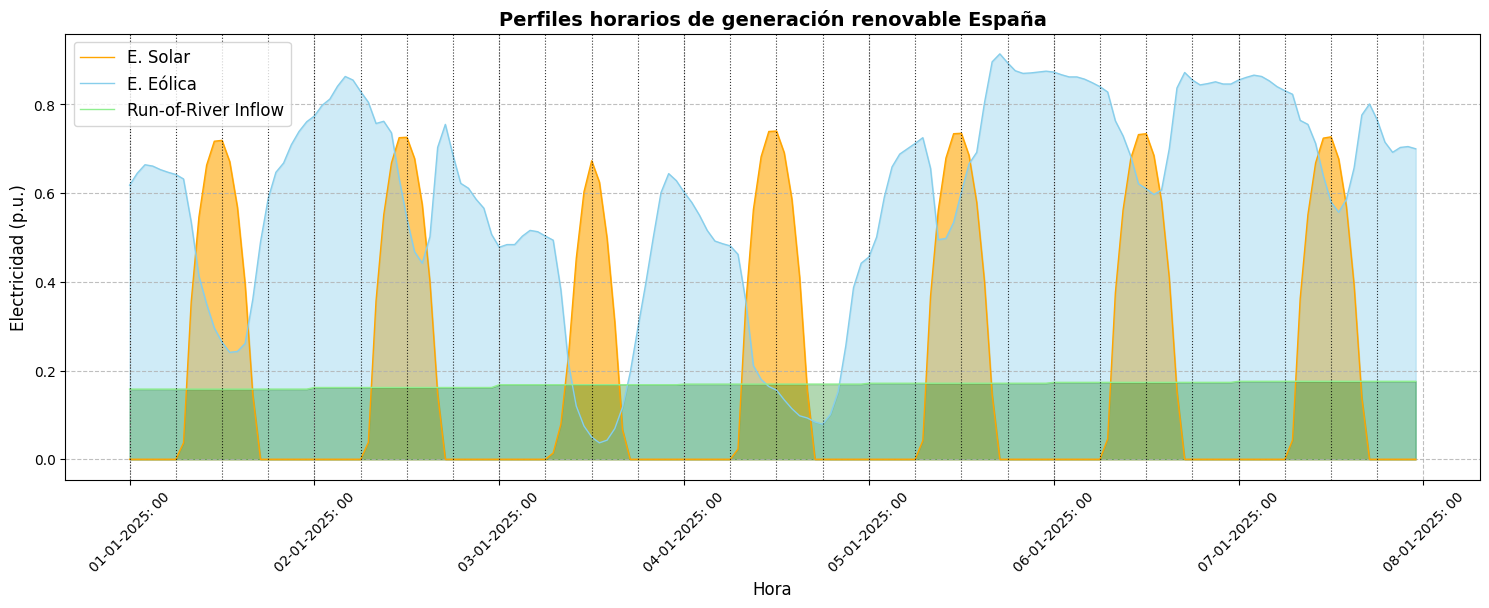

In [85]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_solar_profile, label="E. Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, ES_wind_profile, label="E. Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.plot(hours, ES_hydraulic_profile, label="Run-of-River Inflow", color="lightgreen", linewidth=1, linestyle="-")
plt.title("Perfiles horarios de generación renovable España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, ES_solar_profile, color="orange", alpha=0.6)
plt.fill_between(hours, ES_wind_profile, color="skyblue", alpha=0.4)
plt.fill_between(hours, ES_hydraulic_profile, color="green", alpha=0.3)

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.8, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()



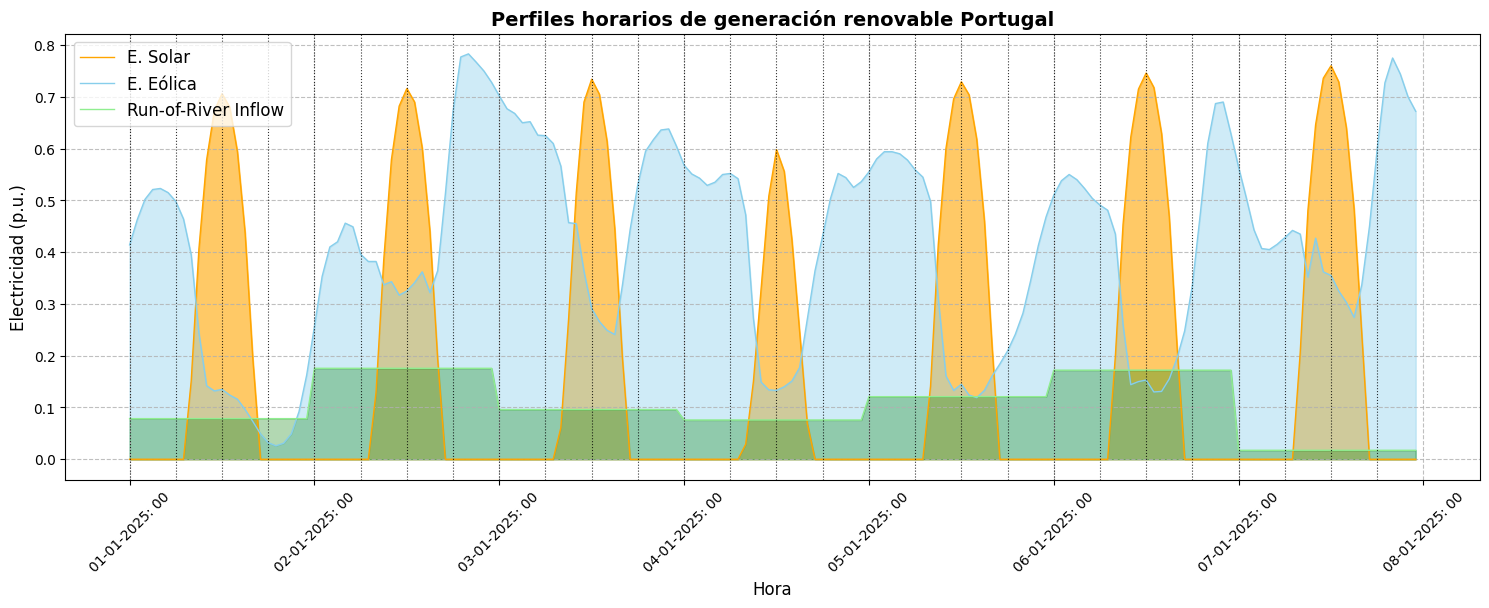

In [86]:
# GRAFICAR

# Gráfica de Perfiles Horarios de Generación Renovable.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") # para que grafique una semana completa (tengo datos para 1 año)
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_solar_profile, label="E. Solar", color="orange", linewidth=1, linestyle="-")
plt.plot(hours, PT_wind_profile, label="E. Eólica", color="skyblue", linewidth=1, linestyle="-")
plt.plot(hours, PT_hydraulic_profile, label="Run-of-River Inflow", color="lightgreen", linewidth=1, linestyle="-")
plt.title("Perfiles horarios de generación renovable Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Electricidad (p.u.)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.fill_between(hours, PT_solar_profile, color="orange", alpha=0.6)
plt.fill_between(hours, PT_wind_profile, color="skyblue", alpha=0.4)
plt.fill_between(hours, PT_hydraulic_profile, color="green", alpha=0.3)
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.8, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2008595108.py:2: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



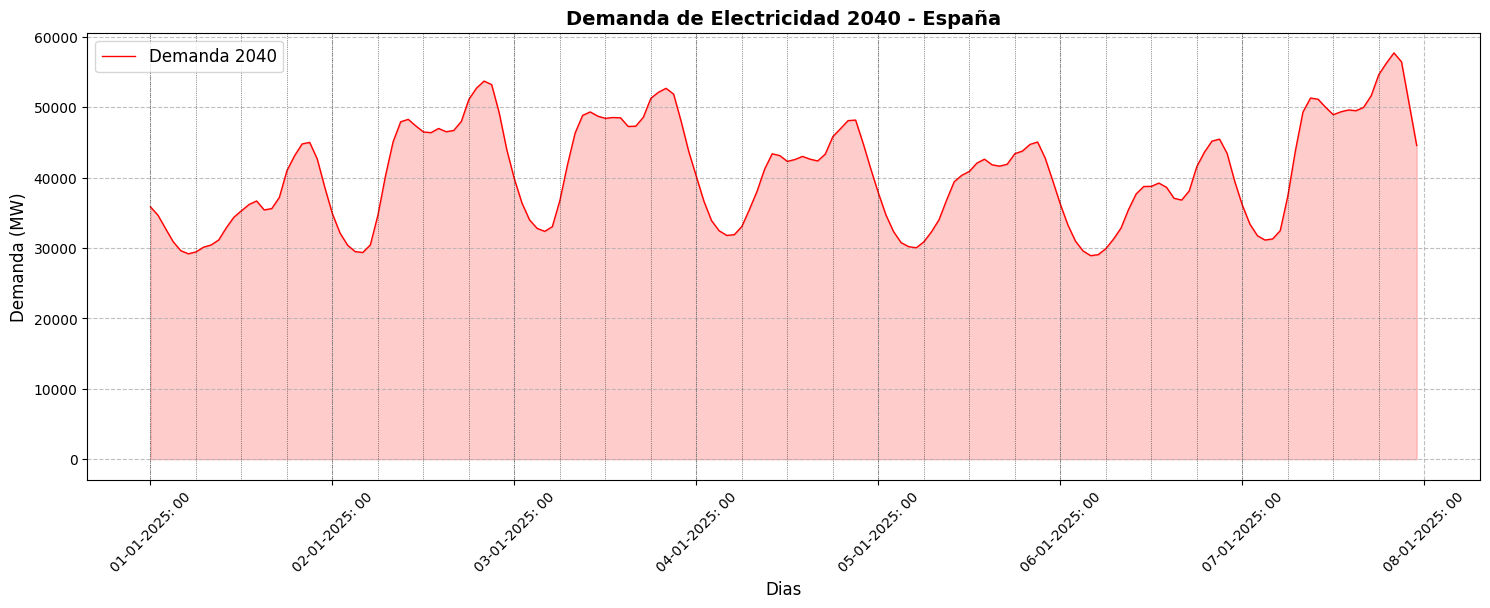

In [87]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="H") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_demand_2040, label="Demanda 2040", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad 2040 - España",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.8)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

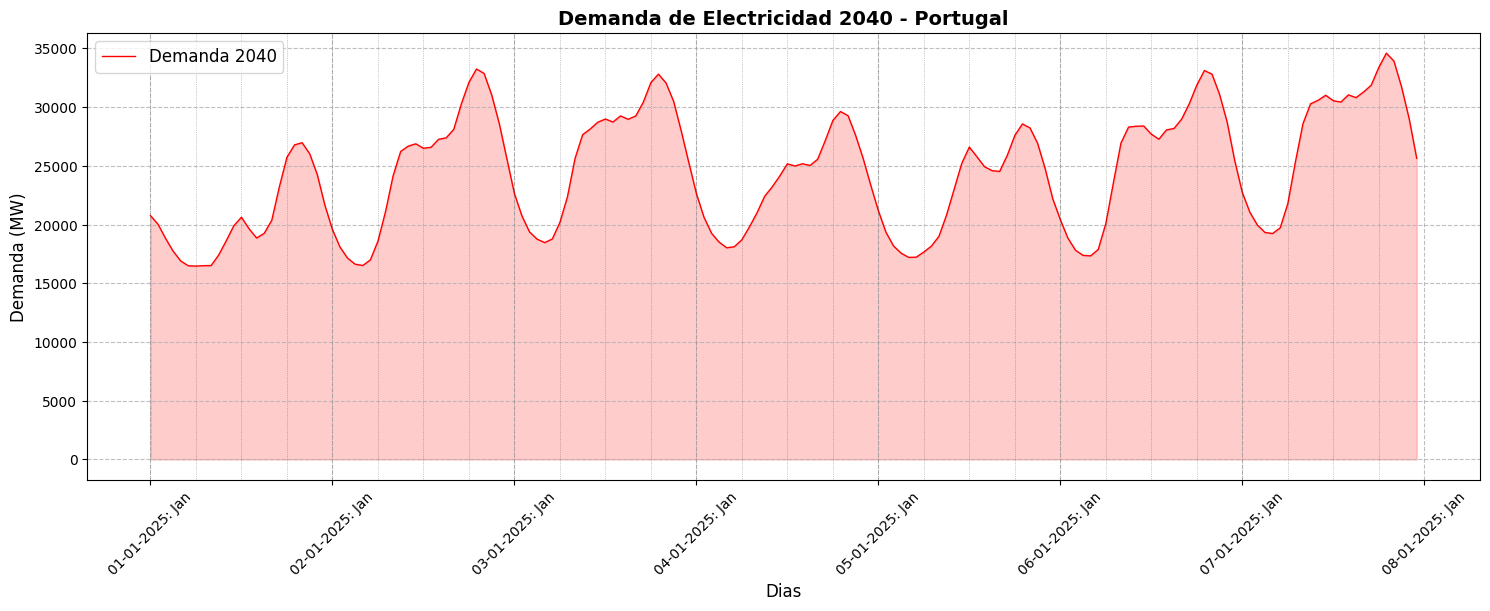

In [88]:
# Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_demand_2040, label="Demanda 2040", color="red", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_demand_2040, color="red", alpha=0.2)
plt.title("Demanda de Electricidad 2040 - Portugal",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()

for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
       
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %h'))
plt.xticks(rotation=45)
plt.show()

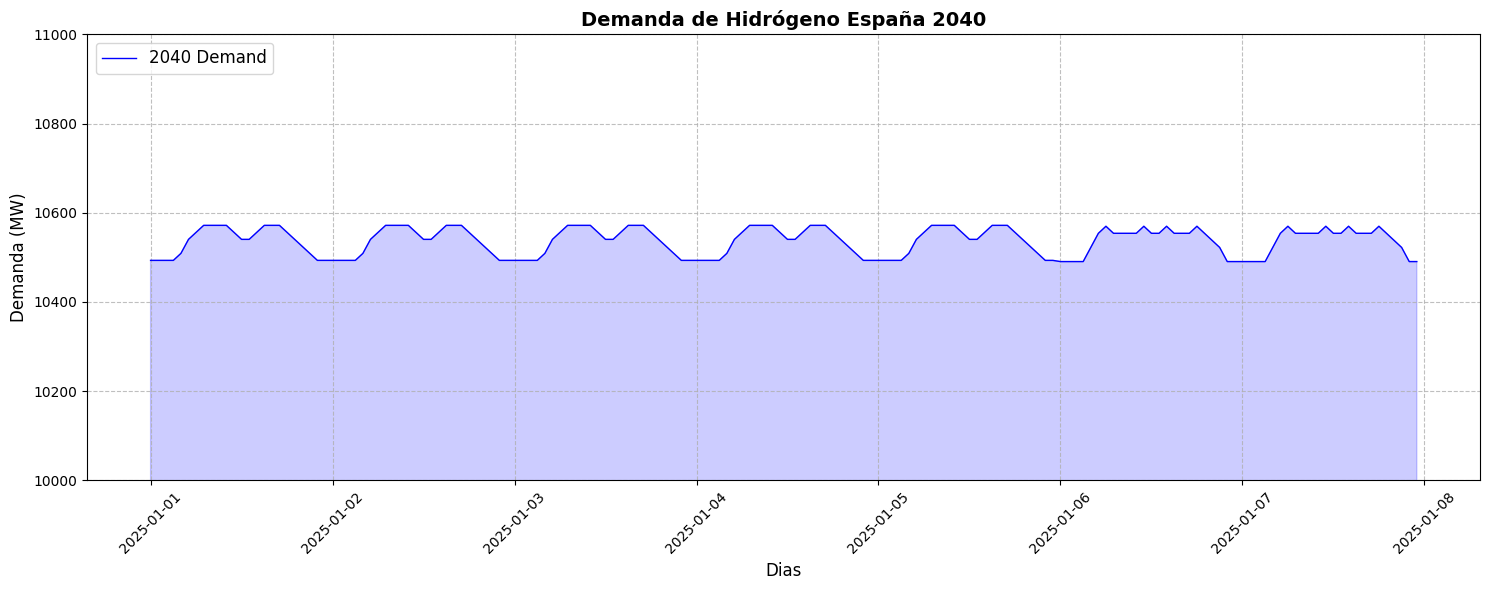

In [89]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, ES_hydrogen_demand, label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, ES_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno España 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.8)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(10000, 11000)


plt.xticks(rotation=45)
plt.show()

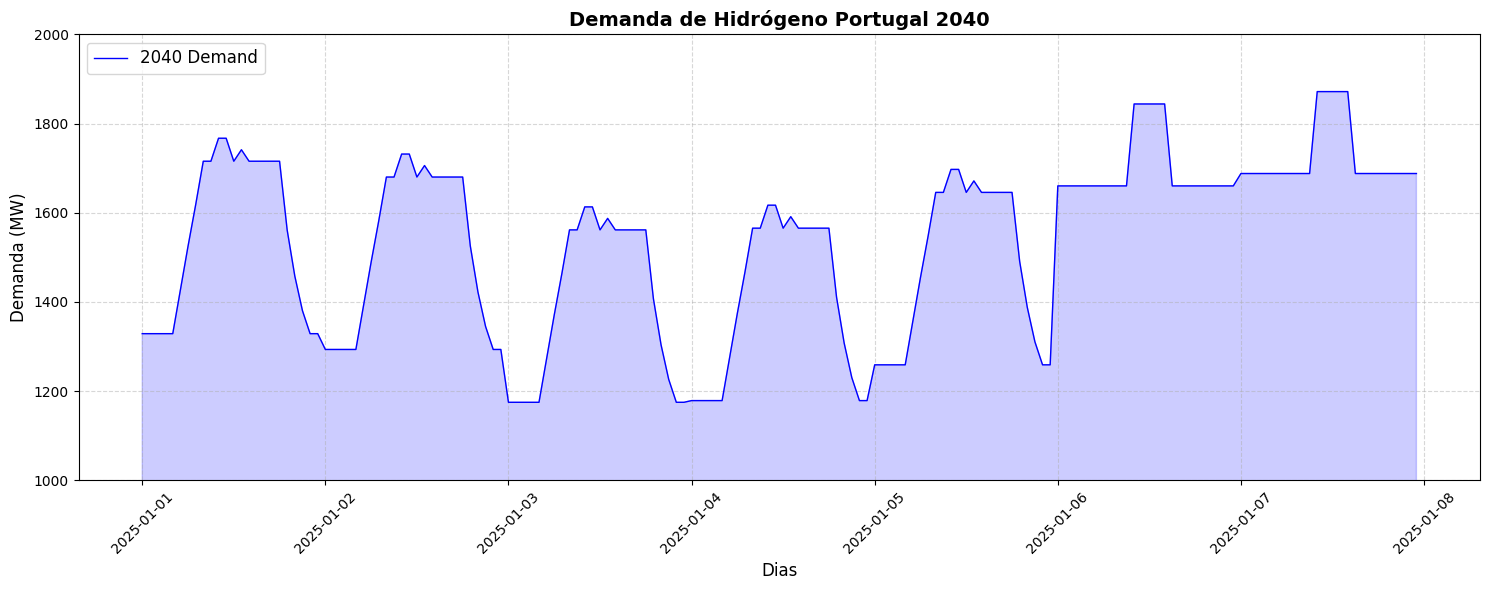

In [90]:
 # Dibuja la Demanda para la primera semana de 2040.
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h") #para que no me ploteé el día 8 con 1 hora
plt.figure(figsize=(15, 6))
plt.style.use('default')
plt.plot(hours, PT_hydrogen_demand, label="2040 Demand", color="blue", linewidth=1, linestyle="-")
plt.fill_between(hours, PT_hydrogen_demand, color="blue", alpha=0.2)
plt.title("Demanda de Hidrógeno Portugal 2040",  fontsize=14, fontweight="bold")
plt.xlabel("Dias", fontsize=12)
plt.ylabel("Demanda (MW)", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
plt.ylim(1000,2000)

plt.xticks(rotation=45)
plt.show()

PARTE II: CREACIÓN DEL ENTORNO: Llamada a Componentes

In [91]:
# CARRIERS
df_carriers = data["carriers"]

for _, carrier in df_carriers.iterrows():
    network.add(
        "Carrier",
        carrier["name"].strip(),
        overwrite=carrier["overwrite"]
    )

# Verificación con API moderna
print("\n=== Carriers añadidos ===")
print(network.carriers.static)




=== Carriers añadidos ===
               co2_emissions color nice_name  max_growth  max_relative_growth
name                                                                         
AC                       0.0                         inf                  0.0
water                    0.0                         inf                  0.0
wind                     0.0                         inf                  0.0
gas                      0.0                         inf                  0.0
solar                    0.0                         inf                  0.0
grid_import              0.0                         inf                  0.0
biomass                  0.0                         inf                  0.0
hydrogen                 0.0                         inf                  0.0
load_shedding            0.0                         inf                  0.0


In [92]:
# BUSES
df_buses = data["buses"]

for _, bus in df_buses.iterrows():
    network.add(
        "Bus",
        bus["name"].strip(),
        carrier=bus["carrier"].strip(),
        overwrite=bus["overwrite"],
        x=float(bus["x"]) if "x" in df_buses.columns and pd.notna(bus["x"]) else np.nan,
        y=float(bus["y"]) if "y" in df_buses.columns and pd.notna(bus["y"]) else np.nan,
    )

# Verificación con API moderna
print("\n=== Buses añadidos ===")
print(network.buses.static)  





=== Buses añadidos ===
                           v_nom type       x        y   carrier unit  \
name                                                                    
ES_electricity_market_bus    1.0      -3.7038  40.4168        AC        
ES_water_bus                 1.0      -3.7038  40.4168     water        
ES_gas_bus                   1.0      -3.7038  40.4168       gas        
ES_hydrogen_bus              1.0      -3.7038  40.4168  hydrogen        
ES_SRES_bus                  1.0      -3.7038  40.4168        AC        
PT_electricity_market_bus    1.0      -9.1393  38.7223        AC        
PT_water_bus                 1.0      -9.1393  38.7223     water        
PT_gas_bus                   1.0      -9.1393  38.7223       gas        
PT_hydrogen_bus              1.0      -9.1393  38.7223  hydrogen        
PT_SRES_bus                  1.0      -9.1393  38.7223        AC        

                          location  v_mag_pu_set  v_mag_pu_min  v_mag_pu_max  \
name               

In [93]:
# GENERADORES
df_generators = data["generators"]

# apra que funcione load shedding dando problemas
df_generators = data["generators"].copy()

# Quédate solo con filas válidas: name, bus y carrier presentes
df_generators = df_generators.dropna(subset=["name", "bus", "carrier"])

# (Opcional) filtra buses válidos (que empiecen por ES o PT)
df_generators = df_generators[df_generators["bus"].astype(str).str.startswith(("ES", "PT"))]
# hasta aquí para que funcione load shedding dando problemas



for _, gen in df_generators.iterrows(): 
    gen_name = gen["name"].strip() 
    carrier_key = gen["carrier"].strip().lower() 
    
    # Detectar si es ES o PT según el bus
    country = gen["bus"][:2]   # ES / PT

    # Crear el generador estático
    network.add( 
        "Generator",
        gen_name,
        bus=gen["bus"],
        p_nom=gen["p_nom"],
        p_nom_extendable=gen["p_nom_extendable"],
        p_nom_max=gen["p_nom_max"],
        capital_cost=gen["capital_cost"],
        marginal_cost=gen["marginal_cost"],
        carrier=gen["carrier"],
        overwrite=gen["overwrite"]
    )

    # Seleccionar perfil correcto según país + carrier
    if carrier_key == "solar":
        profile = ES_solar_profile if country == "ES" else PT_solar_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "wind":
        profile = ES_wind_profile if country == "ES" else PT_wind_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    elif carrier_key == "water":
        profile = ES_hydraulic_profile if country == "ES" else PT_hydraulic_profile
        network.generators.dynamic["p_max_pu"][gen_name] = profile.values
    else:
        continue  # carrier no renovable → no tiene perfil dinámico



In [94]:
print(network.generators)
print(network.generators.dynamic["p_max_pu"].columns)

'Generator' Components
Index(['ES_solar', 'ES_wind', 'ES_water', 'ES_SRES_solar', 'ES_SRES_wind',
       'PT_solar', 'PT_wind', 'PT_water', 'PT_SRES_solar', 'PT_SRES_wind'],
      dtype='object', name='name')


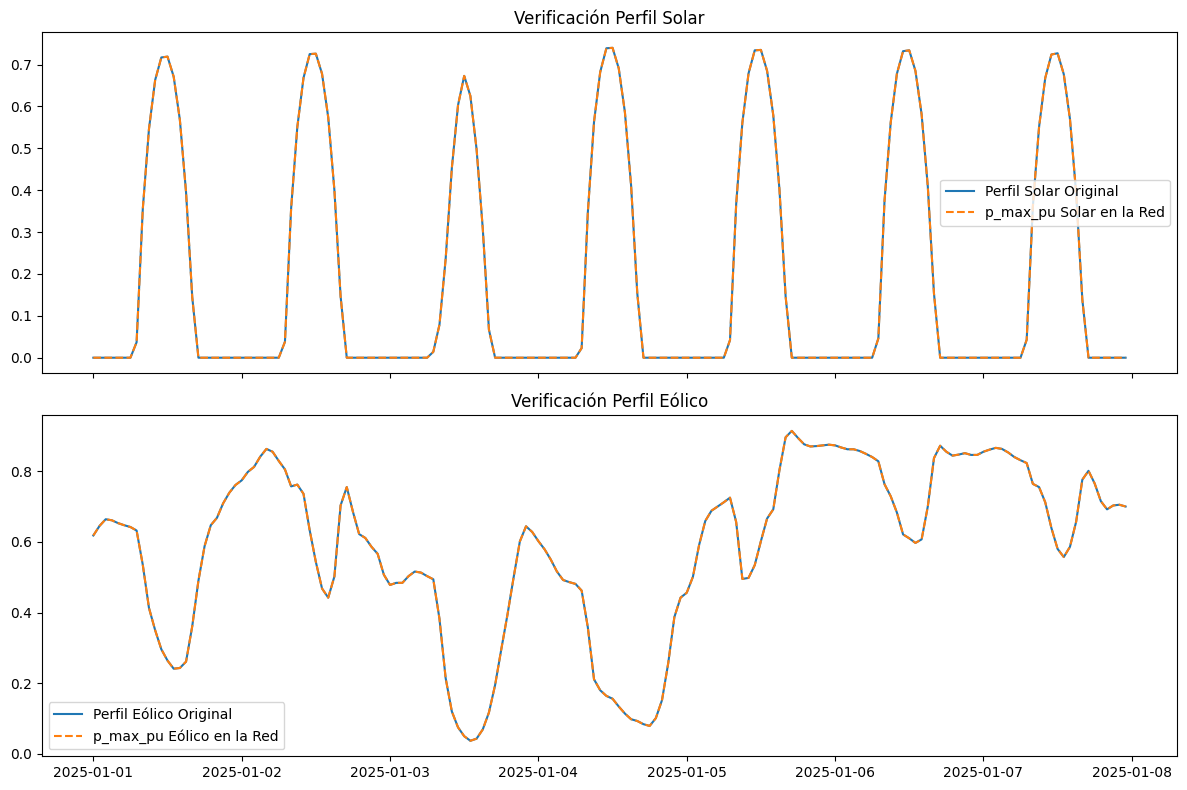

In [95]:
# Verificación de perfiles asignados correctamente: ES
ES_solar_profile.index = network.snapshots[:len(ES_solar_profile)]
ES_wind_profile.index = network.snapshots[:len(ES_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["ES_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["ES_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], ES_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], ES_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()



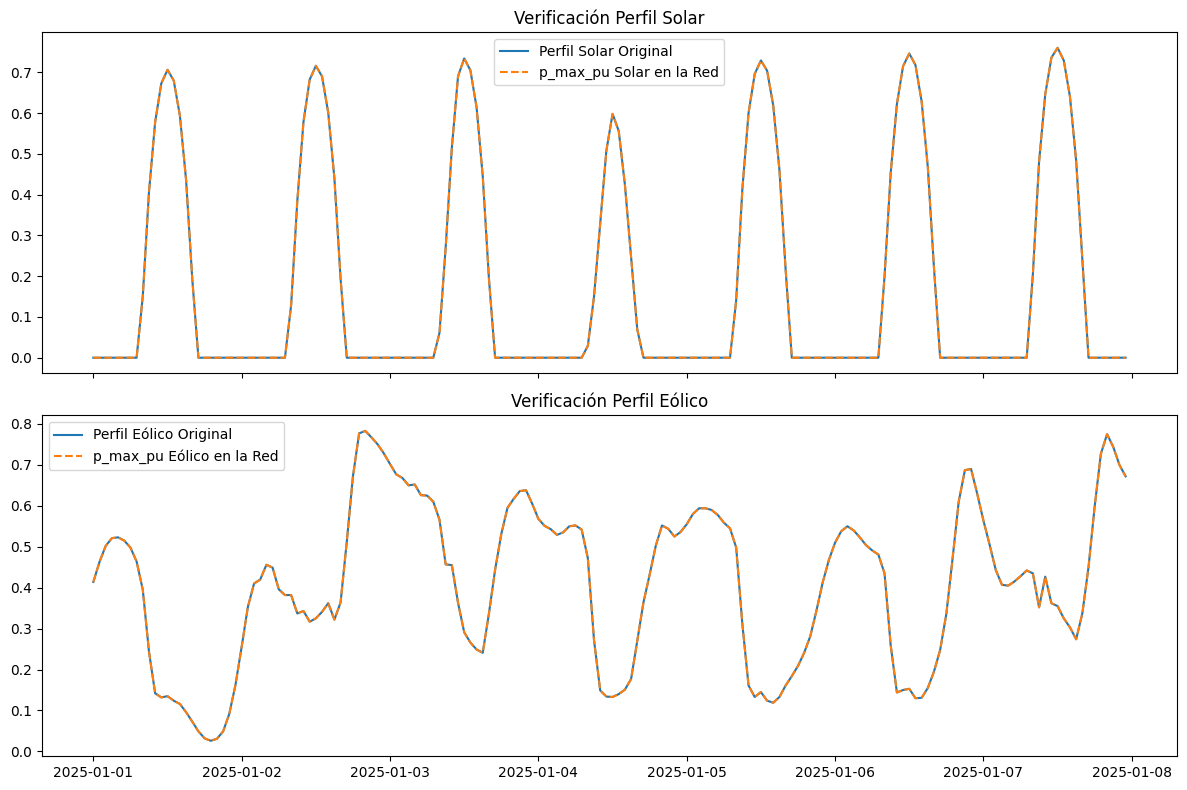

In [96]:
# Verificación de perfiles asignados correctamente: PT
PT_solar_profile.index = network.snapshots[:len(PT_solar_profile)]
PT_wind_profile.index = network.snapshots[:len(PT_wind_profile)]

# Extraer perfiles desde la red
solar_pm = network.generators.dynamic["p_max_pu"]["PT_solar"]
wind_pm  = network.generators.dynamic["p_max_pu"]["PT_wind"]

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(network.snapshots[:len(solar_pm)], PT_solar_profile, label="Perfil Solar Original")
axes[0].plot(network.snapshots[:len(solar_pm)], solar_pm, linestyle="--", label="p_max_pu Solar en la Red")
axes[0].set_title("Verificación Perfil Solar")
axes[0].legend()

axes[1].plot(network.snapshots[:len(wind_pm)], PT_wind_profile, label="Perfil Eólico Original")
axes[1].plot(network.snapshots[:len(wind_pm)], wind_pm, linestyle="--", label="p_max_pu Eólico en la Red")
axes[1].set_title("Verificación Perfil Eólico")
axes[1].legend()

plt.tight_layout()
plt.show()


In [97]:
# LOADS

# CREAR SERIES DE DEMANDA
    #ESPAÑA
ES_demand_hydrogen_series = pd.Series(df_demand2040['ES_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
ES_demand_series = pd.Series(df_demand2040['ES_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)
    #PORTUGAL
PT_demand_hydrogen_series = pd.Series(df_demand2040['PT_hydrogen_demand'].iloc[:len(network.snapshots)].values, index=network.snapshots)
PT_demand_series = pd.Series(df_demand2040['PT_demand_2040'].iloc[:len(network.snapshots)].values, index=network.snapshots)

# Añadir variables estáticas
df_loads = data["loads"]
for _, load in df_loads.iterrows():
    network.add(
        "Load",
        load["name"].strip(),
        bus=load["bus"].strip(),
        carrier=load["carrier"].strip(),
        overwrite=load["overwrite"]
    )

# Asignar variables dinámicas
    #ESPAÑA
network.loads.dynamic["p_set"]["ES_hydrogen_demand"] = ES_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["ES_demand_2040"] = ES_demand_series.values
    #PORTUGAL
network.loads.dynamic["p_set"]["PT_hydrogen_demand"] = PT_demand_hydrogen_series.values
network.loads.dynamic["p_set"]["PT_demand_2040"] = PT_demand_series.values

# Verificación con API moderna
print("\n=== Loads estáticos ===")
print(network.loads.static)

print("\n=== Primeras filas de p_set dinámico ===")
print(network.loads.dynamic["p_set"].head())



=== Loads estáticos ===
                                          bus   carrier type  p_set  q_set  \
name                                                                         
ES_demand_2040      ES_electricity_market_bus        AC         0.0    0.0   
ES_hydrogen_demand            ES_hydrogen_bus  hydrogen         0.0    0.0   
PT_demand_2040      PT_electricity_market_bus        AC         0.0    0.0   
PT_hydrogen_demand            PT_hydrogen_bus  hydrogen         0.0    0.0   

                    sign  active  
name                              
ES_demand_2040      -1.0    True  
ES_hydrogen_demand  -1.0    True  
PT_demand_2040      -1.0    True  
PT_hydrogen_demand  -1.0    True  

=== Primeras filas de p_set dinámico ===
name                 ES_hydrogen_demand  ES_demand_2040  PT_hydrogen_demand  \
snapshot                                                                      
2025-01-01 00:00:00         10493.06584    35845.954713         1328.747032   
2025-01-01 01:00:

In [98]:
df_links = data["links"]

for _, lk in df_links.iterrows():

    name = lk["name"].strip().lower()
    link_name = lk["name"].strip()

    # Detectar país desde bus0
    country = lk["bus0"][:2]   # ES / PT

    # Añadir link estático
    network.add(
        "Link",
        link_name,
        bus0=lk["bus0"].strip(),
        bus1=lk["bus1"].strip(),
        p_nom=lk["p_nom"],
        p_nom_extendable=lk["p_nom_extendable"],
        capital_cost=lk["capital_cost"],
        efficiency=lk["efficiency"],
        marginal_cost=lk["marginal_cost"],
        ramp_limit_up=lk["ramp_limit_up"],
        ramp_limit_down=lk["ramp_limit_down"],
        carrier=lk["carrier"],
        overwrite=lk["overwrite"]
    )
for l in ["ES_SRES_excedentes", "PT_SRES_excedentes"]:
    if l in network.links.static.index:
        network.links.static.loc[l, "p_min_pu"] = 0.0    
    

In [99]:
# Verificación
     
print("\n=== Resumen de todos los Links en la red ===")
print(network.links.static[['bus0','bus1','p_nom','efficiency','marginal_cost','carrier']])
for link_name in ["CCGT", "turbina", "pump", "electrolyzer"]:
        if link_name in network.links.static.index:
            row = network.links.static.loc[link_name]
            print(f"\n--- Detalle de {link_name} ---")
            print(f"Origen (bus0):        {row['bus0']}")
            print(f"Destino (bus1):       {row['bus1']}")
            print(f"Capacidad (p_nom):    {row['p_nom']} MW")
            print(f"Eficiencia:           {row['efficiency']*100:.1f}%")
            print(f"Coste marginal:       {row['marginal_cost']} €/MWh")
            print(f"Carrier:              {row['carrier']}")
            #Ramp limits solo para CCGT
            if link_name == "CCGT":
                print(f"Ramp up limit:        {row['ramp_limit_up']} MW/h")
                print(f"Ramp down limit:      {row['ramp_limit_down']} MW/h")
        else:
            print(f"\n⚠️ El link '{link_name}' no se encontró en la red.")


=== Resumen de todos los Links en la red ===
                                                       bus0  \
name                                                          
ES_CCGT                                          ES_gas_bus   
ES_turbina                                     ES_water_bus   
ES_pump                           ES_electricity_market_bus   
ES_electrolyzer                   ES_electricity_market_bus   
ES_SRES_electrolyzer                            ES_SRES_bus   
ES_SRES_excedentes                              ES_SRES_bus   
PT_CCGT                                          PT_gas_bus   
PT_turbina                                     PT_water_bus   
PT_pump                           PT_electricity_market_bus   
PT_electrolyzer                   PT_electricity_market_bus   
PT_SRES_electrolyzer                            PT_SRES_bus   
PT_SRES_excedentes                              PT_SRES_bus   
ES_PT_interconexion_electricidad  ES_electricity_market_bus   
ES_PT_int

In [100]:
print("\nLINKS ESTÁTICOS:")
print(network.links.static.index)

print("\nCOLUMNAS EN p_max_pu:")
print(network.links.dynamic["p_max_pu"].columns)

print("\nCOLUMNAS EN p0:")
print(network.links_t.p0.columns)


LINKS ESTÁTICOS:
Index(['ES_CCGT', 'ES_turbina', 'ES_pump', 'ES_electrolyzer',
       'ES_SRES_electrolyzer', 'ES_SRES_excedentes', 'PT_CCGT', 'PT_turbina',
       'PT_pump', 'PT_electrolyzer', 'PT_SRES_electrolyzer',
       'PT_SRES_excedentes', 'ES_PT_interconexion_electricidad',
       'ES_PT_interconexion_hidrogeno', 'PT_ES_interconexion_electricidad',
       'PT_ES_interconexion_hidrogeno'],
      dtype='object', name='name')

COLUMNAS EN p_max_pu:
Index([], dtype='object', name='name')

COLUMNAS EN p0:
Index([], dtype='object', name='name')


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\4154381567.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



In [101]:

df_storage = data["storage_units"]

for _, st in df_storage.iterrows():
    name = st["name"].strip()

    soc0=0.5*st["p_nom"]*st["max_hours"]  # Estado de carga inicial al 50%

    # Añadir atributos estáticos
    network.add(
        "StorageUnit",
        name,
        bus=st["bus"].strip(),
        p_nom=st["p_nom"],
        p_nom_extendable=st["p_nom_extendable"],
        max_hours=st["max_hours"],
        efficiency_store=st["efficiency_store"],
        efficiency_dispatch=st["efficiency_dispatch"],
        capital_cost=st["capital_cost"],
        marginal_cost=st["marginal_cost"],
        carrier=st["carrier"],
        overwrite=st["overwrite"],  
        state_of_charge_initial= soc0, 
        cyclic_state_of_charge= False
    )

    print(f"✅ StorageUnit '{name}' añadida en bus {st['bus']}: {st['p_nom']} MW · {st['max_hours']} h")

# Verificación
print("\n=== Storage Units estáticos ===")
print(network.storage_units.static.head())

print("\n=== Storage Units dinámicos ===")
print(network.storage_units.dynamic.keys())


✅ StorageUnit 'ES_electricity_market_battery' añadida en bus ES_electricity_market_bus: 26698.52 MW · 4 h
✅ StorageUnit 'ES_hydrogen_storage' añadida en bus ES_hydrogen_bus: 10000.0 MW · 1000 h
✅ StorageUnit 'PT_electricity_market_battery' añadida en bus PT_electricity_market_bus: 3000.0 MW · 4 h

=== Storage Units estáticos ===
                                                     bus control type  \
name                                                                    
ES_electricity_market_battery  ES_electricity_market_bus      PQ        
ES_hydrogen_storage                      ES_hydrogen_bus      PQ        
PT_electricity_market_battery  PT_electricity_market_bus      PQ        

                                  p_nom  p_nom_mod  p_nom_extendable  \
name                                                                   
ES_electricity_market_battery  26698.52        0.0              True   
ES_hydrogen_storage            10000.00        0.0              True   
PT_electricity_

In [102]:
df_store = data["store"].copy()
 
# normaliza la columna a boolean REAL
df_store["cyclic_state_of_charge"] = (
    df_store["cyclic_state_of_charge"]
    .astype(str).str.strip().str.lower()
    .map({"true": True, "false": False, "1": True, "0": False, "nan": False})
)
 
# si algo no mapea, lo dejamos en False (o lanza error si prefieres)
df_store["cyclic_state_of_charge"] = df_store["cyclic_state_of_charge"].fillna(False)

In [103]:
for _, store in df_store.iterrows():
    network.add(
        "Store",
        store["name"].strip(),
        bus=store["bus"].strip(),
        e_nom=store["e_nom"],
        e_initial=store["e_initial"], 
        e_min_pu=store["e_min_pu"],
        e_max_pu=store["e_max_pu"],
        e_cyclic=store["cyclic_state_of_charge"],
        capital_cost=store["capital_cost"],
        marginal_cost=store["marginal_cost"],
        carrier=store["carrier"],
        overwrite=store["overwrite"]
    )

    print(f"✅ Store '{store['name']}' añadida en bus {store['bus']}: "
          f"{store['e_nom']} MWh · inicial {store['e_initial']} MWh · "
          f"min {store['e_min_pu']} pu · max {store['e_max_pu']} pu · "
          f"coste marginal {store['marginal_cost']}")

# Verificación con API moderna
print("\n=== Stores estáticos ===")
print(network.stores.static.head())


✅ Store 'ES_embalse' añadida en bus ES_water_bus: 1387684000 MWh · inicial 1248915600 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1
✅ Store 'PT_embalse' añadida en bus PT_water_bus: 3307600 MWh · inicial 2976840 MWh · min 0.2 pu · max 0.9 pu · coste marginal 1

=== Stores estáticos ===
                     bus type carrier         e_nom  e_nom_mod  \
name                                                             
ES_embalse  ES_water_bus        water  1.387684e+09        0.0   
PT_embalse  PT_water_bus        water  3.307600e+06        0.0   

            e_nom_extendable  e_nom_min  e_nom_max  e_nom_set  e_min_pu  ...  \
name                                                                     ...   
ES_embalse             False        0.0        inf        NaN       0.2  ...   
PT_embalse             False        0.0        inf        NaN       0.2  ...   

            sign  marginal_cost  marginal_cost_quadratic  \
name                                                       
ES_e

RESTRICCIONES

In [104]:
# Precio de CO2 y factor de emisión
co2_price = 10000  # €/tCO2
emission_factor = 0.202  # tCO2/MWh

# Coste adicional por CO2
co2_cost = co2_price * emission_factor  # 20.2 €/MWh

# Acceso correcto en tu versión de PyPSA
network.links.df.loc["ES_CCGT", "marginal_cost"] += co2_cost # += se suma el cose de la penalización de CO2 al precio que tenía el CCGT
network.links.df.loc["PT_CCGT", "marginal_cost"] += co2_cost

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\479254106.py:9: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\479254106.py:10: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



In [105]:
import xarray as xr

def soc_min_50pct_start_end_extendable(n, snapshots, names=None, frac=0.50):
    """
    SOLO StorageUnits extendables:
    SOC(inicio) >= frac*(p_nom_opt*max_hours)
    SOC(final)  >= frac*(p_nom_opt*max_hours)

    Robusta: detecta automáticamente el nombre de la dimensión ('StorageUnit' o 'name', etc.)
    """
    su = n.storage_units.static

    if names is None:
        names = ["ES_electricity_market_battery", "PT_electricity_market_battery", "ES_hydrogen_storage"]
    batt = [b for b in names if b in su.index]
    if not batt:
        raise ValueError("No encuentro StorageUnits objetivo en storage_units.static")

    # Asegurar extendable
    not_ext = [b for b in batt if not bool(su.loc[b, "p_nom_extendable"])]
    if not_ext:
        raise ValueError(f"Estas StorageUnits NO son extendables: {not_ext}")

    m = n.model

    # Variables del modelo
    soc  = m.variables["StorageUnit-state_of_charge"]   # xarray DataArray
    pnom = m.variables["StorageUnit-p_nom"]             # xarray DataArray

    # --- detectar dims reales ---
    # snapshot dim
    snap_dim = "snapshot" if "snapshot" in soc.dims else soc.dims[0]

    # storage dim = la otra que no es snapshot (en tu error es "name")
    su_dim = [d for d in soc.dims if d != snap_dim][0]

    # en pnom también puede ser "name"
    pnom_dim = pnom.dims[0]

    # snapshots inicio y fin
    t0 = snapshots[0]
    tN = snapshots[-1]

    # seleccionar SOC inicio y fin
    soc_0 = soc.sel({snap_dim: t0, su_dim: batt})
    soc_N = soc.sel({snap_dim: tN, su_dim: batt})

    # seleccionar p_nom invertido
    pnom_b = pnom.sel({pnom_dim: batt})

    # max_hours alineado con la dimensión de storage
    max_hours = xr.DataArray(
        su.loc[batt, "max_hours"].astype(float).to_numpy(),
        coords={su_dim: batt},
        dims=[su_dim]
    )

    target = frac * pnom_b * max_hours

    m.add_constraints(soc_0 >= target, name="soc_start_ge_50pct_extendable")
    m.add_constraints(soc_N >= target, name="soc_end_ge_50pct_extendable")

In [106]:
import numpy as np
import xarray as xr

def sres_constraints_excess_max_target(
    n, snapshots=None, countries=("ES","PT"),
    h2_share=0.50,      # solo para definir el "target eléctrico equivalente"
    excess_share=0.3,  # 30% máximo
    tol=0.0
):
    """
    ÚNICA restricción:
      Excedentes eléctricos SRES <= excess_share * (h2_share*Demanda_H2/eff)   (en energía eléctrica)

    Requiere:
      Link: f"{c}_SRES_electrolyzer"  (para leer efficiency)
      Link: f"{c}_SRES_excedentes"    (p0 en MW_el)
      Load: f"{c}_hydrogen_demand" en loads_t.p_set
    """
    if snapshots is None:
        snapshots = n.snapshots

    m = n.model
    p_link = m.variables["Link-p"]

    # dims robustas
    dims = list(p_link.dims)
    snap_dim = "snapshot" if "snapshot" in dims else dims[0]
    link_dim = [d for d in dims if d != snap_dim][0]

    # pesos: MW -> MWh equivalente
    w = n.snapshot_weightings["objective"].reindex(snapshots).to_numpy(dtype=float)
    w_da = xr.DataArray(w, coords={snap_dim: snapshots}, dims=[snap_dim])

    links = n.links.static

    for c in countries:
        l_ely = f"{c}_SRES_electrolyzer"
        l_ex  = f"{c}_SRES_excedentes"
        load  = f"{c}_hydrogen_demand"

        if l_ely not in links.index:
            continue
        if l_ex not in links.index:
            raise KeyError(f"No existe link excedentes '{l_ex}'")
        if load not in n.loads_t.p_set.columns:
            raise KeyError(f"No existe load '{load}' en loads_t.p_set")

        eff = float(links.at[l_ely, "efficiency"])

        # p_ex (MW_el en bus0)
        p_ex = p_link.sel({link_dim: l_ex, snap_dim: snapshots})

        # Demanda H2 (MW_H2)
        h2 = n.loads_t.p_set[load].reindex(snapshots).fillna(0.0).to_numpy(dtype=float)

        # Energía total H2 demandada (MWh_H2)
        E_h2_dem = float(np.sum(h2 * w))

        # Target eléctrico equivalente (MWh_el)
        E_el_target = (h2_share * E_h2_dem) / eff

        # Energía excedentes (MWh_el)
        E_excess = (p_ex * w_da).sum(dim=snap_dim)

        m.add_constraints(
            E_excess <= excess_share * E_el_target + tol,
            name=f"{c}_SRES_excess_cap_energy"
        )

import numpy as np
import xarray as xr

def sres_constraints_h2_and_excess_target(
    n, snapshots=None, countries=("ES","PT"),
    h2_share=0.50,        # 50% en H2
    excess_share=0.3,    # 15% del eléctrico equivalente al target H2
    tol=0.0
):
    
    """
    Restricciones energéticas (NO horarias) con unidades coherentes:

    1) H2 producido por SRES >= h2_share * Demanda_H2   (en energía H2)
    2) Excedentes eléctricos SRES <= excess_share * (h2_share*Demanda_H2/eff) (en energía eléctrica)

    Requiere:
      Link: f"{c}_SRES_electrolyzer"  (bus0: SRES_el, bus1: H2_bus)
      Link: f"{c}_SRES_excedentes"    (bus0: SRES_el, bus1: electricity_market_bus)
      Load: f"{c}_hydrogen_demand" en loads_t.p_set
    """

    if snapshots is None:
        snapshots = n.snapshots

    m = n.model
    p_link = m.variables["Link-p"]

    # dims robustas
    dims = list(p_link.dims)
    snap_dim = "snapshot" if "snapshot" in dims else dims[0]
    link_dim = [d for d in dims if d != snap_dim][0]

    # pesos para pasar MW -> MWh equivalente (según tu snapshot_weightings)
    w = n.snapshot_weightings["objective"].reindex(snapshots).to_numpy(dtype=float)
    w_da = xr.DataArray(w, coords={snap_dim: snapshots}, dims=[snap_dim])

    links = n.links.static

    for c in countries:
        l_ely = f"{c}_SRES_electrolyzer"
        l_ex  = f"{c}_SRES_excedentes"
        load  = f"{c}_hydrogen_demand"

        if l_ely not in links.index:
            continue
        if l_ex not in links.index:
            raise KeyError(f"No existe link excedentes '{l_ex}'")
        if load not in n.loads_t.p_set.columns:
            raise KeyError(f"No existe load '{load}' en loads_t.p_set")

        eff = float(links.at[l_ely, "efficiency"])

        # Variables (MW_el en bus0)
        p_ely = p_link.sel({link_dim: l_ely, snap_dim: snapshots})
        p_ex  = p_link.sel({link_dim: l_ex,  snap_dim: snapshots})

        # Demanda H2 (MW_H2)
        h2 = n.loads_t.p_set[load].reindex(snapshots).fillna(0.0).to_numpy(dtype=float)

        # Energía total H2 demandada
        E_h2_dem = float(np.sum(h2 * w))

        # ---- (1) H2 SRES >= 50% de demanda H2 ----
        # H2(t) = eff * p_ely(t)  (MW_H2)
        E_h2_sres = (p_ely * eff * w_da).sum(dim=snap_dim)

        m.add_constraints(
            E_h2_sres >= h2_share * E_h2_dem - tol,
            name=f"{c}_H2_from_SRES_min_energy"
        )

        # ---- (2) Excedentes eléctricos <= 15% del eléctrico equivalente al target (50%) ----
        # E_el_target = (h2_share * E_h2_dem)/eff
        E_el_target = (h2_share * E_h2_dem) / eff

        E_excess = (p_ex * w_da).sum(dim=snap_dim)

        m.add_constraints(
            E_excess <= excess_share * E_el_target + tol,
            name=f"{c}_SRES_excess_cap_energy"
        )

In [107]:
def extra_functionality_combined(n, snapshots):
    soc_min_50pct_start_end_extendable(n, snapshots, frac=0.50)

    # SOLO restricción de excedentes (sin H2>=50% demanda)
    sres_constraints_excess_max_target(
        n, snapshots=snapshots, countries=("ES","PT"),
        h2_share=0.50, excess_share=0.3, tol=0.0
    )

def extra_functionality_combined(n, snapshots):
    soc_min_50pct_start_end_extendable(n, snapshots, frac=0.50)      # (ver bloque 3) 
    sres_constraints_h2_and_excess_target(
        n, snapshots=snapshots, countries=("ES","PT"),
        h2_share=0.50, excess_share=0.3, tol=0.0
    )

In [108]:
# Desactiva ramp limits para TODOS los links. Solo en Inversión.
network.links.static["ramp_limit_up"] = np.nan
network.links.static["ramp_limit_down"] = np.nan
#set_storage_not_cyclic(network)

PARTE III: OPTIMIZACIÓN

In [109]:
network.optimize(
    solver_name="highs",
    extra_functionality=extra_functionality_combined
)

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1468014392.py:45: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1468014392.py:54: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1468014392.py:45: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1468014392.py:54: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a dr

('ok', 'optimal')

PARTE IV: OBTENCIÓN DE RESULTADOS.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3258615621.py:16: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3258615621.py:44: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3258615621.py:45: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3258615621.py:47: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3258615621.py:48: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3258615621.py:50: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be rem

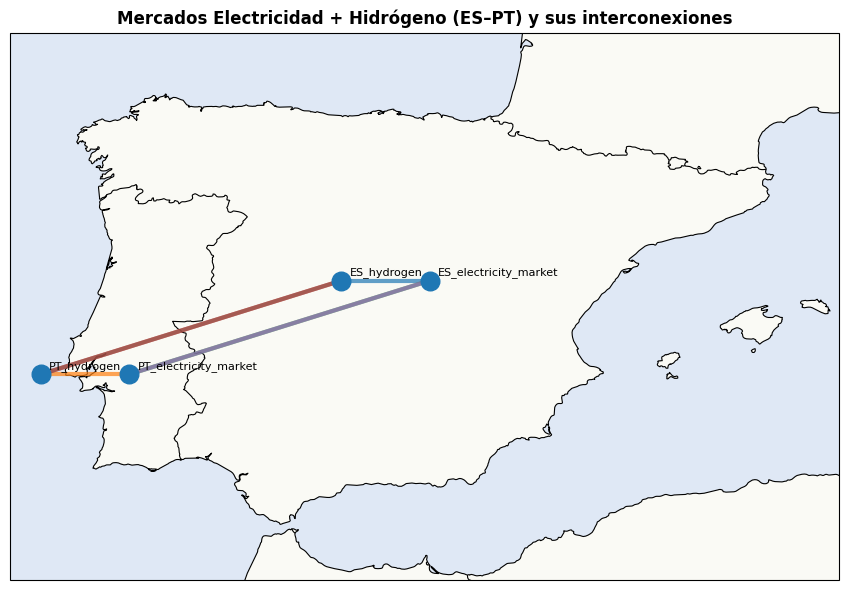

In [110]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ------------------------------
# 1) Buses que quieres
# ------------------------------
wanted_buses = [
    "ES_electricity_market_bus",
    "ES_hydrogen_bus",
    "PT_electricity_market_bus",
    "PT_hydrogen_bus",
]

bdf = network.buses.df.loc[wanted_buses, ["x", "y", "carrier"]].copy()

# ------------------------------
# 2) JITTER para separar buses con misma coordenada
# ------------------------------
jitter = 0.8

grouped = bdf.groupby(["x", "y"])

for (x, y), idx in grouped.groups.items():
    if len(idx) > 1:
        angles = np.linspace(0, 2*np.pi, len(idx), endpoint=False)
        for i, bus in enumerate(idx):
            bdf.loc[bus, "x"] = x + jitter * np.cos(angles[i])
            bdf.loc[bus, "y"] = y + jitter * np.sin(angles[i])

# ------------------------------
# 3) Interconexiones entre ellos
# ------------------------------
edges = []

def add_edges(df, bus0="bus0", bus1="bus1"):
    if df is None or len(df) == 0:
        return
    for _, r in df.iterrows():
        if (r[bus0] in bdf.index) and (r[bus1] in bdf.index):
            edges.append((r[bus0], r[bus1]))

if hasattr(network, "links") and hasattr(network.links, "df"):
    add_edges(network.links.df)

if hasattr(network, "lines") and hasattr(network.lines, "df"):
    add_edges(network.lines.df)

if hasattr(network, "transformers") and hasattr(network.transformers, "df"):
    add_edges(network.transformers.df)

# ------------------------------
# 4) Mapa base (solo península)
# ------------------------------
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, alpha=0.25)
ax.add_feature(cfeature.OCEAN, alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

ax.set_extent([-10.5, 4.5, 35.0, 44.9], crs=ccrs.PlateCarree())

# ------------------------------
# 5) Dibujar interconexiones
# ------------------------------
for b0, b1 in edges:
    x0, y0 = bdf.loc[b0, ["x", "y"]]
    x1, y1 = bdf.loc[b1, ["x", "y"]]
    ax.plot([x0, x1], [y0, y1], linewidth=3, alpha=0.7,
            transform=ccrs.PlateCarree())

# ------------------------------
# 6) Dibujar buses
# ------------------------------
ax.scatter(
    bdf["x"],
    bdf["y"],
    s=180,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

# Etiquetas
for name, r in bdf.iterrows():
    ax.text(
        r["x"] + 0.15,
        r["y"] + 0.10,
        name.replace("_bus", ""),
        transform=ccrs.PlateCarree(),
        fontsize=8,
        zorder=6,
    )

ax.set_title(
    "Mercados Electricidad + Hidrógeno (ES–PT) y sus interconexiones",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:38: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:50: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:54: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:55: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:66: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:78: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be rem

Links dibujados: ['ES_PT_interconexion_electricidad', 'PT_ES_interconexion_electricidad', 'ES_PT_interconexion_hidrogeno', 'PT_ES_interconexion_hidrogeno', 'PT_electrolyzer']
PT elec<->PT H2 detectado: ['PT_electrolyzer']


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:200: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:203: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:200: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:203: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as 

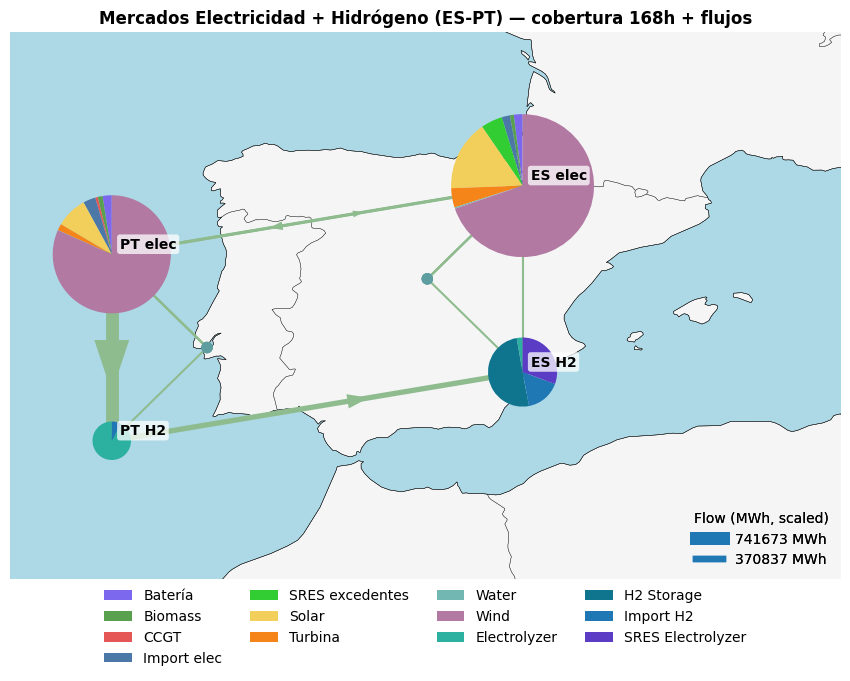

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2235351170.py:336: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



In [164]:
# ============================================================
# MAPA "IMAGEN 1" — PIES = COBERTURA DEMANDA (ETIQUETAS CLARAS)
#  - SOLO buses: ES/PT electricidad + H2
#  - Links: ES<->PT elec, ES<->PT H2, PT elec<->PT H2 (auto)
#  - SUMA 168h (MWh) SIN anualizar
#  - Pies: Solar/Wind/Water/Biomass/CCGT/Turbina/Import/SRES/Batería...
#  - H2: Electrolyzer/SRES Electrolyzer/Import H2/H2 Storage
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pypsa.plot import add_legend_lines, add_legend_patches

n = network

# ------------------------------
# 0) Ajustes visuales
# ------------------------------
extent_iberia = (-14.0, 6.5, 33.0, 46.5)

dx, dy = 2.35, 2.30 # separación buses

bus_size_factor     = 2.5e6   # baja => pies más grandes
branch_width_factor = 8e4     # baja => links más gordos
branch_flow_factor  = 8e4     # baja => flechas más visibles

# ------------------------------
# 1) Buses objetivo
# ------------------------------
b_e_es = "ES_electricity_market_bus"
b_h_es = "ES_hydrogen_bus"
b_e_pt = "PT_electricity_market_bus"
b_h_pt = "PT_hydrogen_bus"

wanted_buses = [b_e_es, b_h_es, b_e_pt, b_h_pt]
wanted_buses = [b for b in wanted_buses if b in n.buses.df.index]
wanted_bus_set = set(wanted_buses)

# ------------------------------
# 2) Links a dibujar (solo interconexiones + PT elec<->PT H2)
# ------------------------------
links_cross = [
    "ES_PT_interconexion_electricidad",
    "PT_ES_interconexion_electricidad",
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
]
links_cross = [l for l in links_cross if hasattr(n, "links") and l in n.links.df.index]

# Detecta PT elec <-> PT H2 automáticamente (electrolizador PT típico)
pt_internal_links = []
if hasattr(n, "links") and len(n.links.df):
    L = n.links.df
    mask = (
        ((L.bus0 == b_e_pt) & (L.bus1 == b_h_pt)) |
        ((L.bus0 == b_h_pt) & (L.bus1 == b_e_pt))
    )
    pt_internal_links = list(L.index[mask])

wanted_links = list(dict.fromkeys(links_cross + pt_internal_links))

# filtra links que conecten SOLO entre los 4 buses
if hasattr(n, "links") and len(wanted_links):
    Lsel = n.links.df.loc[wanted_links, ["bus0", "bus1"]]
    wanted_links = [
        l for l in wanted_links
        if (Lsel.loc[l, "bus0"] in wanted_bus_set) and (Lsel.loc[l, "bus1"] in wanted_bus_set)
    ]

print("Links dibujados:", wanted_links)
print("PT elec<->PT H2 detectado:", pt_internal_links)

# ------------------------------
# 3) Reposicionar buses (sin solape)
# ------------------------------
orig_xy = n.buses.df.loc[wanted_buses, ["x", "y"]].copy()

def is_elec(bus): return "electricity_market" in bus
def is_h2(bus):   return "hydrogen" in bus

base = orig_xy.copy()
new_xy = base.copy()

for b in new_xy.index:
    x0, y0 = base.loc[b, ["x", "y"]]
    if b.startswith("ES_"):
        if is_elec(b): new_xy.loc[b, ["x","y"]] = [x0 + dx, y0 + dy]
        if is_h2(b):   new_xy.loc[b, ["x","y"]] = [x0 + dx, y0 - dy]
    if b.startswith("PT_"):
        if is_elec(b): new_xy.loc[b, ["x","y"]] = [x0 - dx, y0 + dy]
        if is_h2(b):   new_xy.loc[b, ["x","y"]] = [x0 - dx, y0 - dy]

n.buses.df.loc[wanted_buses, ["x","y"]] = new_xy

# ------------------------------
# 4) FLOWS (flechas) = MWh (168h) usando p0
# ------------------------------
link_flow = pd.Series(dtype=float)
if len(wanted_links):
    link_flow = n.links_t.p0[wanted_links].sum(axis=0)

# Para leyenda “tipo de flow” (elec vs H2)
link_is_h2 = {}
if hasattr(n, "links") and len(wanted_links):
    L = n.links.df.loc[wanted_links]
    for l in wanted_links:
        # heurística: si conecta buses hydrogen -> es H2, si no -> elec
        b0, b1 = L.loc[l, ["bus0","bus1"]]
        link_is_h2[l] = ("hydrogen" in b0.lower()) or ("hydrogen" in b1.lower())

# ------------------------------
# 5) Helpers para etiquetar tecnologías por NOMBRE (no por carrier)
# ------------------------------
def tech_from_generator(name, carrier):
    cl = str(carrier).lower()
    if "solar" in cl: return "Solar"
    if "wind" in cl: return "Wind"
    if "water" in cl or "hydro" in cl: return "Water"
    if "biomass" in cl: return "Biomass"
    return str(carrier)

def tech_from_link(name, bus0, bus1):
    nl = str(name).lower()
    # Interconexiones
    if "interconexion" in nl and "electricidad" in nl: return "Import elec"
    if "interconexion" in nl and "hidrogeno" in nl:    return "Import H2"
    # CCGT / turbina
    if "ccgt" in nl: return "CCGT"
    if "turbina" in nl or "turbine" in nl: return "Turbina"
    # Excedentes SRES
    if "sres" in nl and "exced" in nl: return "SRES excedentes"
    # Electrolizadores
    if "sres" in nl and "electrolyzer" in nl: return "SRES Electrolyzer"
    if "electrolyzer" in nl or "electrol" in nl: return "Electrolyzer"
    # Pump (si lo quisieras)
    if "pump" in nl: return "Pump"
    return str(name)

def tech_from_storage(name, carrier):
    nl = str(name).lower()
    cl = str(carrier).lower()
    if "battery" in nl or "battery" in cl: return "Batería"
    if "hydrogen" in nl or "hydrogen" in cl or "h2" in nl: return "H2 Storage"
    return str(carrier)

# ------------------------------
# 6) Construir PIES = COBERTURA DEMANDA (MWh 168h)
# ------------------------------
T = n.snapshots
rows = []

def add_mwh(bus, tech, series_mw):
    if bus not in wanted_bus_set:
        return
    if series_mw is None:
        return
    s = series_mw.reindex(T).fillna(0.0)
    mwh = float(s.sum())
    if mwh > 1e-6:  # cobertura = positivo
        rows.append((bus, tech, mwh))

# 6.A Electricidad: generadores en el bus eléctrico
if hasattr(n, "generators") and len(n.generators.df):
    g = n.generators.df.copy()
    g = g[g.bus.isin([b_e_es, b_e_pt])]
    for name, row in g.iterrows():
        if name in n.generators_t.p.columns:
            tech = tech_from_generator(name, row["carrier"])
            add_mwh(row["bus"], tech, n.generators_t.p[name].clip(lower=0))

# 6.B Electricidad: links que entregan electricidad al mercado eléctrico (bus1=mercado)
# Usamos tu convención: aporte = -p1 (parte negativa) -> positivo
if hasattr(n, "links") and len(n.links.df) and hasattr(n, "links_t") and hasattr(n.links_t, "p1"):
    L = n.links.df.copy()
    Lin_e = L[L.bus1.isin([b_e_es, b_e_pt])]
    for name, row in Lin_e.iterrows():
        if name not in n.links_t.p1.columns:
            continue
        tech = tech_from_link(name, row["bus0"], row["bus1"])
        aporte = (-n.links_t.p1[name].clip(upper=0))  # entra al mercado
        add_mwh(row["bus1"], tech, aporte)

# 6.C Electricidad: batería descarga (p>0)
if hasattr(n, "storage_units") and len(n.storage_units.df):
    su = n.storage_units.df.copy()
    su = su[su.bus.isin([b_e_es, b_e_pt])]
    for name, row in su.iterrows():
        if name in n.storage_units_t.p.columns:
            tech = tech_from_storage(name, row["carrier"])
            add_mwh(row["bus"], tech, n.storage_units_t.p[name].clip(lower=0))

# 6.D Hidrógeno: links que entregan H2 al bus H2 (bus1=H2)
# Convención: aporte = -p1 (parte negativa) -> positivo
if hasattr(n, "links") and len(n.links.df) and hasattr(n, "links_t") and hasattr(n.links_t, "p1"):
    L = n.links.df.copy()
    Lin_h2 = L[L.bus1.isin([b_h_es, b_h_pt])]
    for name, row in Lin_h2.iterrows():
        if name not in n.links_t.p1.columns:
            continue
        tech = tech_from_link(name, row["bus0"], row["bus1"])
        aporte_h2 = (-n.links_t.p1[name].clip(upper=0))
        add_mwh(row["bus1"], tech, aporte_h2)

# 6.E Hidrógeno: storage discharge (p>0) en bus H2
if hasattr(n, "storage_units") and len(n.storage_units.df):
    su = n.storage_units.df.copy()
    su = su[su.bus.isin([b_h_es, b_h_pt])]
    for name, row in su.iterrows():
        if name in n.storage_units_t.p.columns:
            tech = tech_from_storage(name, row["carrier"])
            add_mwh(row["bus"], tech, n.storage_units_t.p[name].clip(lower=0))

# Serie final (bus, tech) -> MWh
eb = pd.Series(
    data=[r[2] for r in rows],
    index=pd.MultiIndex.from_tuples([(r[0], r[1]) for r in rows], names=["bus", "tech"])
).groupby(["bus", "tech"]).sum()

# Re-nombrar nivel tech a carrier para que PyPSA pinte slices
eb_plot = eb.copy()
eb_plot.index = eb_plot.index.set_names(["bus", "carrier"])

# ------------------------------
# 7) Colores por tech
# ------------------------------
techs = list(eb_plot.index.get_level_values("carrier").unique())



tech_color = {}
for t in techs:
    tl = str(t).lower()

    # --- H2: fija colores distintos (prioridad arriba) ---
    if tl == "electrolyzer":
        tech_color[t] = "#2CB1A1"   # teal
    elif tl == "sres electrolyzer":
        tech_color[t] = "#5B3CC4"   # morado/índigo (DISTINTO)
    elif tl == "import h2":
        tech_color[t] = "#1F77B4"   # azul (para import H2)
    elif tl == "h2 storage":
        tech_color[t] = "#0F758F"   # azul verdoso oscuro

    # --- Electricidad ---
    elif tl == "wind":
        tech_color[t] = "#B279A2"
    elif tl == "solar":
        tech_color[t] = "#F2CF5B"
    elif tl == "water":
        tech_color[t] = "#72B7B2"
    elif tl == "biomass":
        tech_color[t] = "#59A14F"
    elif tl == "ccgt" or "gas" in tl:
        tech_color[t] = "#E45756"
    elif tl == "turbina":
        tech_color[t] = "#F58518"
    elif tl == "import elec":
        tech_color[t] = "#4C78A8"
    elif tl == "sres excedentes":
        tech_color[t] = "#32CD32"
    elif "bater" in tl:
        tech_color[t] = "#7B68EE"

    # --- fallback ---
    else:
        tech_color[t] = "#BAB0AC"


# Crear carriers temporales con color
if "color" not in n.carriers.df.columns:
    n.carriers.df["color"] = pd.NA
n.carriers.df["color"] = n.carriers.df["color"].replace("", pd.NA)

for t in techs:
    if t not in n.carriers.df.index:
        n.add("Carrier", t)
    n.carriers.df.loc[t, "color"] = tech_color[t]

# ------------------------------
# 8) Plot
# ------------------------------
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": ccrs.PlateCarree()})

# base map
n.plot(ax=ax, geomap_color=True)

# pies + flechas
n.plot(
    ax=ax,
    bus_size=(eb_plot / bus_size_factor) if len(eb_plot) else None,
    bus_split_circle=False,
    link_width=(link_flow.abs() / branch_width_factor) if len(link_flow) else None,
    link_flow=(link_flow / branch_flow_factor) if len(link_flow) else None,
)

ax.set_extent(extent_iberia, crs=ccrs.PlateCarree())
ax.set_title("Mercados Electricidad + Hidrógeno (ES-PT) — cobertura 168h + flujos", fontweight="bold")

# etiquetas buses
label_map = {b_e_es:"ES elec", b_h_es:"ES H2", b_e_pt:"PT elec", b_h_pt:"PT H2"}
for b in wanted_buses:
    x, y = n.buses.df.loc[b, ["x", "y"]]
    ax.text(
        x + 0.20, y + 0.15, label_map.get(b, b),
        transform=ccrs.PlateCarree(),
        fontsize=10, fontweight="bold",
        zorder=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
    )

# leyenda de tech (pies)
if len(techs):
    add_legend_patches(
        ax,
        colors=[tech_color[t] for t in techs],
        labels=[str(t) for t in techs],
        legend_kw={"loc": "lower center", "bbox_to_anchor": (0.5, -0.18), "ncol": 4, "frameon": False},
    )

# leyenda flows (grosor)
if len(link_flow):
    maxf = float(link_flow.abs().max())
    add_legend_lines(
        ax,
        sizes=[maxf/branch_width_factor, 0.5*maxf/branch_width_factor],
        labels=[f"{maxf:.0f} MWh", f"{0.5*maxf:.0f} MWh"],
        legend_kw={"loc": "lower right", "frameon": False, "title": "Flow (MWh, scaled)"},
    )

plt.tight_layout()
plt.show()

# restaurar coords
n.buses.df.loc[wanted_buses, ["x","y"]] = orig_xy

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:36: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:48: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:52: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:63: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:74: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:91: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed i

Links dibujados: ['ES_PT_interconexion_electricidad', 'PT_ES_interconexion_electricidad', 'ES_PT_interconexion_hidrogeno', 'PT_ES_interconexion_hidrogeno', 'PT_electrolyzer']


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:272: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:297: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:297: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:297: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:297: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



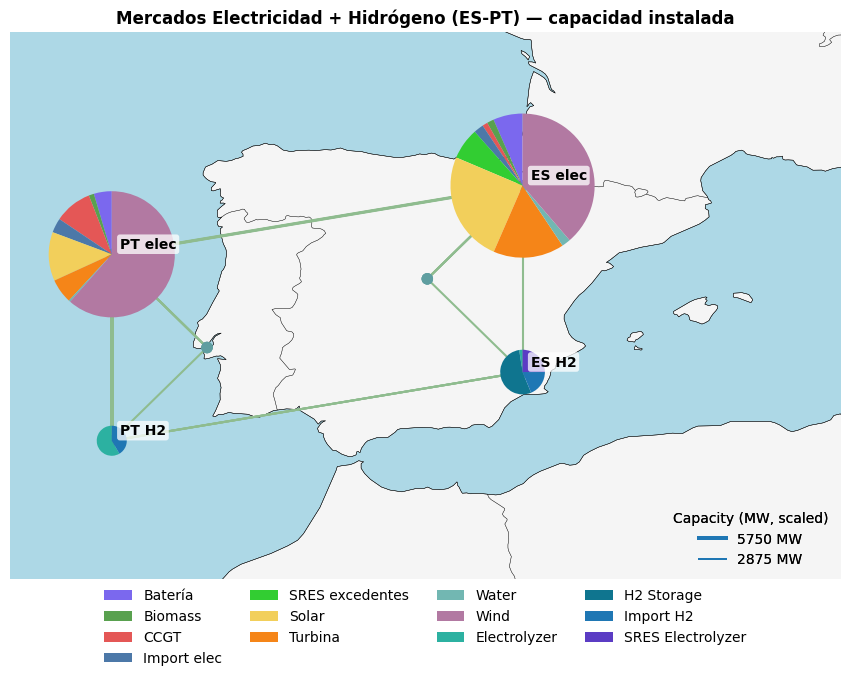

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\314546140.py:329: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.



In [170]:
# ============================================================
# MAPA "CAPACIDAD INSTALADA" — MISMO FORMATO QUE TU FOTO
#  - 4 buses: ES/PT electricidad + H2
#  - Pies = capacidad instalada (MW) por tecnología
#  - Links = capacidad instalada (MW) (sin flechas de flow)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pypsa.plot import add_legend_lines, add_legend_patches



# ------------------------------
# 0) Ajustes visuales (igual que tu mapa)
# ------------------------------
extent_iberia = (-14.0, 6.5, 33.0, 46.5)

dx, dy = 2.35, 2.30  # separación buses

bus_size_factor     = 5e4 # baja => pies más grandes
branch_width_factor = 2e3   # baja => links más gordos
branch_flow_factor  = 1e1   # baja => flechas más visibles

# ------------------------------
# 1) Buses objetivo
# ------------------------------
b_e_es = "ES_electricity_market_bus"
b_h_es = "ES_hydrogen_bus"
b_e_pt = "PT_electricity_market_bus"
b_h_pt = "PT_hydrogen_bus"

wanted_buses = [b_e_es, b_h_es, b_e_pt, b_h_pt]
wanted_buses = [b for b in wanted_buses if b in n.buses.df.index]
wanted_bus_set = set(wanted_buses)

# ------------------------------
# 2) Links a dibujar (interconexiones + PT elec<->PT H2 auto)
# ------------------------------
links_cross = [
    "ES_PT_interconexion_electricidad",
    "PT_ES_interconexion_electricidad",
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
]
links_cross = [l for l in links_cross if l in n.links.df.index]

# Detecta PT elec <-> PT H2 automáticamente (si existe)
pt_internal_links = []
L = n.links.df
mask = (
    ((L.bus0 == b_e_pt) & (L.bus1 == b_h_pt)) |
    ((L.bus0 == b_h_pt) & (L.bus1 == b_e_pt))
)
pt_internal_links = list(L.index[mask])

wanted_links = list(dict.fromkeys(links_cross + pt_internal_links))

# Filtra links que conecten SOLO entre los 4 buses
if len(wanted_links):
    Lsel = n.links.df.loc[wanted_links, ["bus0", "bus1"]]
    wanted_links = [
        l for l in wanted_links
        if (Lsel.loc[l, "bus0"] in wanted_bus_set) and (Lsel.loc[l, "bus1"] in wanted_bus_set)
    ]

print("Links dibujados:", wanted_links)

# ------------------------------
# 3) Reposicionar buses (sin solape) = igual que tu mapa
# ------------------------------
orig_xy = n.buses.df.loc[wanted_buses, ["x", "y"]].copy()

def is_elec(bus): return "electricity_market" in bus
def is_h2(bus):   return "hydrogen" in bus

base = orig_xy.copy()
new_xy = base.copy()

for b in new_xy.index:
    x0, y0 = base.loc[b, ["x", "y"]]
    if b.startswith("ES_"):
        if is_elec(b): new_xy.loc[b, ["x","y"]] = [x0 + dx, y0 + dy]
        if is_h2(b):   new_xy.loc[b, ["x","y"]] = [x0 + dx, y0 - dy]
    if b.startswith("PT_"):
        if is_elec(b): new_xy.loc[b, ["x","y"]] = [x0 - dx, y0 + dy]
        if is_h2(b):   new_xy.loc[b, ["x","y"]] = [x0 - dx, y0 - dy]

n.buses.df.loc[wanted_buses, ["x","y"]] = new_xy

# ------------------------------
# 4) Helpers para agrupar tecnologías (igual idea que tu mapa)
# ------------------------------
def tech_from_generator(name, carrier):
    cl = str(carrier).lower()
    if "solar" in cl: return "Solar"
    if "wind" in cl: return "Wind"
    if "water" in cl or "hydro" in cl: return "Water"
    if "biomass" in cl: return "Biomass"
    if "load_shedding" in cl: return "Load shedding"
    return str(carrier)

def tech_from_link(name):
    nl = str(name).lower()
    # interconexiones
    if "interconexion" in nl and "electricidad" in nl: return "Import elec"
    if "interconexion" in nl and "hidrogeno" in nl:    return "Import H2"
    # generación eléctrica por link
    if "ccgt" in nl: return "CCGT"
    if "turbina" in nl or "turbine" in nl: return "Turbina"
    # excedentes SRES
    if "sres" in nl and "exced" in nl: return "SRES excedentes"
    # electrolizadores
    if "sres" in nl and "electrolyzer" in nl: return "SRES Electrolyzer"
    if "electrolyzer" in nl or "electrol" in nl: return "Electrolyzer"
    if "pump" in nl: return "Pump"
    return str(name)

def tech_from_storage(name, carrier):
    nl = str(name).lower()
    cl = str(carrier).lower()
    if "battery" in nl or "battery" in cl: return "Batería"
    if "hydrogen" in nl or "hydrogen" in cl or "h2" in nl: return "H2 Storage"
    return str(carrier)

# ------------------------------
# 5) Construir PIES = CAPACIDAD INSTALADA (MW)
#    - Generators: p_nom_opt (si existe) o p_nom
#    - StorageUnit: p_nom_opt o p_nom
#    - Links:
#        * si aportan a bus eléctrico (bus1=elec market): usar p_nom_opt (MW)
#        * si aportan a bus H2 (bus1=H2): usar p_nom_opt*eff (MW_H2) para electrolizadores
#        * interconexión H2: p_nom_opt (ya está en su unidad)
# ------------------------------
rows = []

def get_cap(series_or_value):
    # helper: devuelve float
    try:
        return float(series_or_value)
    except Exception:
        return 0.0

def add_cap(bus, tech, cap_mw):
    if bus not in wanted_bus_set:
        return
    cap_mw = float(cap_mw)
    if cap_mw > 1e-6:
        rows.append((bus, tech, cap_mw))

# 5.A Generators en buses eléctricos (ES/PT)
G = n.generators.df.copy()
Gsel = G[G.bus.isin([b_e_es, b_e_pt])]
for name, r in Gsel.iterrows():
    tech = tech_from_generator(name, r["carrier"])
    # p_nom_opt existe tras optimización para extendables (y suele existir como columna)
    if "p_nom_opt" in n.generators.df.columns and pd.notna(n.generators.df.loc[name, "p_nom_opt"]):
        cap = n.generators.df.loc[name, "p_nom_opt"]
    else:
        cap = n.generators.df.loc[name, "p_nom"]
    add_cap(r["bus"], tech, cap)

# 5.B StorageUnits en buses eléctricos y H2
SU = n.storage_units.df.copy()
SUse = SU[SU.bus.isin([b_e_es, b_e_pt, b_h_es, b_h_pt])]
for name, r in SUse.iterrows():
    tech = tech_from_storage(name, r["carrier"])
    if "p_nom_opt" in n.storage_units.df.columns and pd.notna(n.storage_units.df.loc[name, "p_nom_opt"]):
        cap = n.storage_units.df.loc[name, "p_nom_opt"]
    else:
        cap = n.storage_units.df.loc[name, "p_nom"]
    add_cap(r["bus"], tech, cap)

# 5.C Links que "aportan" a bus eléctrico (bus1 mercado elec)
L = n.links.df.copy()
L_e = L[L.bus1.isin([b_e_es, b_e_pt])]
for name, r in L_e.iterrows():
    tech = tech_from_link(name)
    if "p_nom_opt" in n.links.df.columns and pd.notna(n.links.df.loc[name, "p_nom_opt"]):
        cap = n.links.df.loc[name, "p_nom_opt"]
    else:
        cap = n.links.df.loc[name, "p_nom"]
    add_cap(r["bus1"], tech, cap)

# 5.D Links que aportan a bus H2 (bus1 H2)
L_h2 = L[L.bus1.isin([b_h_es, b_h_pt])]
for name, r in L_h2.iterrows():
    tech = tech_from_link(name)
    if "p_nom_opt" in n.links.df.columns and pd.notna(n.links.df.loc[name, "p_nom_opt"]):
        pnom = n.links.df.loc[name, "p_nom_opt"]
    else:
        pnom = n.links.df.loc[name, "p_nom"]

    eff = float(n.links.df.loc[name, "efficiency"]) if "efficiency" in n.links.df.columns and pd.notna(n.links.df.loc[name, "efficiency"]) else 1.0

    # Si es electrolizador, convertimos a capacidad H2 (MW_H2) = p_nom_el * eff
    if tech in ["Electrolyzer", "SRES Electrolyzer"]:
        cap = pnom * eff
    else:
        cap = pnom

    add_cap(r["bus1"], tech, cap)

# Serie final (bus, tech) -> MW
eb = pd.Series(
    data=[r[2] for r in rows],
    index=pd.MultiIndex.from_tuples([(r[0], r[1]) for r in rows], names=["bus", "tech"])
).groupby(["bus", "tech"]).sum()

eb_plot = eb.copy()
eb_plot.index = eb_plot.index.set_names(["bus", "carrier"])

# ------------------------------
# 6) Colores (mismos que tu mapa)
# ------------------------------
techs = list(eb_plot.index.get_level_values("carrier").unique())

tech_color = {}
for t in techs:
    tl = str(t).lower()

    # H2
    if tl == "electrolyzer":
        tech_color[t] = "#2CB1A1"
    elif tl == "sres electrolyzer":
        tech_color[t] = "#5B3CC4"
    elif tl == "import h2":
        tech_color[t] = "#1F77B4"
    elif tl == "h2 storage":
        tech_color[t] = "#0F758F"

    # Electricidad
    elif tl == "wind":
        tech_color[t] = "#B279A2"
    elif tl == "solar":
        tech_color[t] = "#F2CF5B"
    elif tl == "water":
        tech_color[t] = "#72B7B2"
    elif tl == "biomass":
        tech_color[t] = "#59A14F"
    elif tl == "ccgt" or "gas" in tl:
        tech_color[t] = "#E45756"
    elif tl == "turbina":
        tech_color[t] = "#F58518"
    elif tl == "import elec":
        tech_color[t] = "#4C78A8"
    elif tl == "sres excedentes":
        tech_color[t] = "#32CD32"
    elif "bater" in tl:
        tech_color[t] = "#7B68EE"
    else:
        tech_color[t] = "#BAB0AC"

# Asegurar carriers con color para PyPSA
if "color" not in n.carriers.df.columns:
    n.carriers.df["color"] = pd.NA
n.carriers.df["color"] = n.carriers.df["color"].replace("", pd.NA)

for t in techs:
    if t not in n.carriers.df.index:
        n.add("Carrier", t)
    n.carriers.df.loc[t, "color"] = tech_color[t]

# ------------------------------
# 7) Link widths = capacidad instalada (MW)
# ------------------------------
link_cap = pd.Series(dtype=float)
if len(wanted_links):
    if "p_nom_opt" in n.links.df.columns:
        link_cap = n.links.df.loc[wanted_links, "p_nom_opt"].fillna(n.links.df.loc[wanted_links, "p_nom"]).astype(float)
    else:
        link_cap = n.links.df.loc[wanted_links, "p_nom"].astype(float)

# ------------------------------
# 8) Plot (mismo look & feel)
# ------------------------------
fig, ax = plt.subplots(figsize=(10, 6.0), subplot_kw={"projection": ccrs.PlateCarree()})

n.plot(ax=ax, geomap_color=True)

n.plot(
    ax=ax,
    bus_size=(eb_plot / bus_size_factor) if len(eb_plot) else None,
    bus_split_circle=False,
    link_width=(link_cap / branch_width_factor) if len(link_cap) else None,
    # SIN link_flow: aquí no queremos flechas por energía
)

ax.set_extent(extent_iberia, crs=ccrs.PlateCarree())
ax.set_title("Mercados Electricidad + Hidrógeno (ES-PT) — capacidad instalada", fontweight="bold")

# etiquetas buses
label_map = {b_e_es:"ES elec", b_h_es:"ES H2", b_e_pt:"PT elec", b_h_pt:"PT H2"}
for b in wanted_buses:
    x, y = n.buses.df.loc[b, ["x", "y"]]
    ax.text(
        x + 0.20, y + 0.15, label_map.get(b, b),
        transform=ccrs.PlateCarree(),
        fontsize=10, fontweight="bold",
        zorder=10,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
    )

# leyenda tech (pies)
if len(techs):
    add_legend_patches(
        ax,
        colors=[tech_color[t] for t in techs],
        labels=[str(t) for t in techs],
        legend_kw={"loc": "lower center", "bbox_to_anchor": (0.5, -0.18), "ncol": 4, "frameon": False},
    )

# leyenda links (capacidad)
if len(link_cap):
    maxc = float(link_cap.max())
    add_legend_lines(
        ax,
        sizes=[maxc/branch_width_factor, 0.5*maxc/branch_width_factor],
        labels=[f"{maxc:.0f} MW", f"{0.5*maxc:.0f} MW"],
        legend_kw={"loc": "lower right", "frameon": False, "title": "Capacity (MW, scaled)"},
    )

plt.tight_layout()
plt.show()

# restaurar coords
n.buses.df.loc[wanted_buses, ["x","y"]] = orig_xy

In [113]:
print(n.snapshot_weightings.head())

                     objective  generators      links  storage_units  stores
snapshot                                                                    
2025-01-01 00:00:00  52.142857   52.142857  52.142857      52.142857     1.0
2025-01-01 01:00:00  52.142857   52.142857  52.142857      52.142857     1.0
2025-01-01 02:00:00  52.142857   52.142857  52.142857      52.142857     1.0
2025-01-01 03:00:00  52.142857   52.142857  52.142857      52.142857     1.0
2025-01-01 04:00:00  52.142857   52.142857  52.142857      52.142857     1.0


# Guardar resultados en un archivo Excel
network.export_to_excel(
    r"C:\Users\EXT10348\Downloads\WinPython 3.12.10\WPy64-31241\PROYECTOS PYPSA\Dispatching-Project-in-PypSA\Modelo_España_Portugal\Resultados\ES_PT_Unidos_inversion.xlsx",
    engine="openpyxl"
)

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2574578773.py:6: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2574578773.py:7: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2574578773.py:33: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2574578773.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



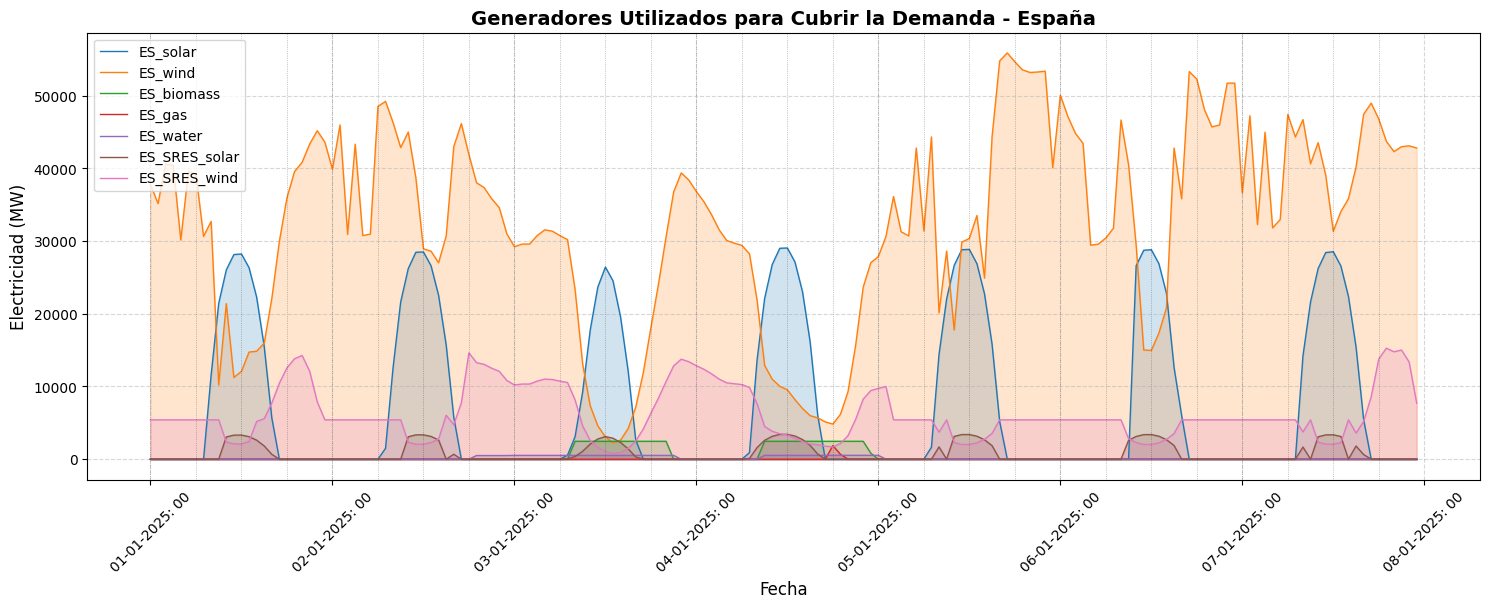

In [114]:
# GENERADORES UTILIZADOS EN PORTUGAL PARA CUBRIR DEMANDA: con este plot podemos graficar la aportación de los generadores sólo de Portugal (sabiendo que los buses de Portugal empiezan por "PT_")
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Obtener DataFrames de generadores y buses (compatibles con varias versiones) ===
try:
    # API nueva (componentes con .df)
    gen_df = network.components["Generator"].df
    buses_df = network.components["Bus"].df
except (AttributeError, KeyError):
    # API clásica (atributos DataFrame)
    gen_df = network.generators
    buses_df = network.buses
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Definir qué es "Portugal" para los buses ===
# Por nombre del bus (prefijo PT_)
is_es_bus = buses_df.index.str.startswith("ES_")
es_buses = set(buses_df.index[is_es_bus])
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Filtrar generadores cuyo 'bus' pertenece a Portugal ===
if "bus" in gen_df.columns:
    generadores_pt = gen_df.index[gen_df["bus"].isin(es_buses)]
else:
    # Fallback por nombre del generador si no existe la columna 'bus'
    generadores_pt = gen_df.index[gen_df.index.str.startswith("ES_")]
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Rango temporal ===
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Graficar potencia sólo de generadores de Portugal ===
plt.figure(figsize=(15, 6))
plt.style.use('default')

# Las series temporales están en network.generators_t.p
cols_disponibles = [g for g in generadores_pt if g in network.generators_t.p.columns]

for gen in cols_disponibles:
    y = network.generators_t.p[gen].reindex(hours)  # alinear al rango
    plt.plot(hours, y, label=gen, linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Generadores Utilizados para Cubrir la Demanda - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.show()
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\4157858586.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\4157858586.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



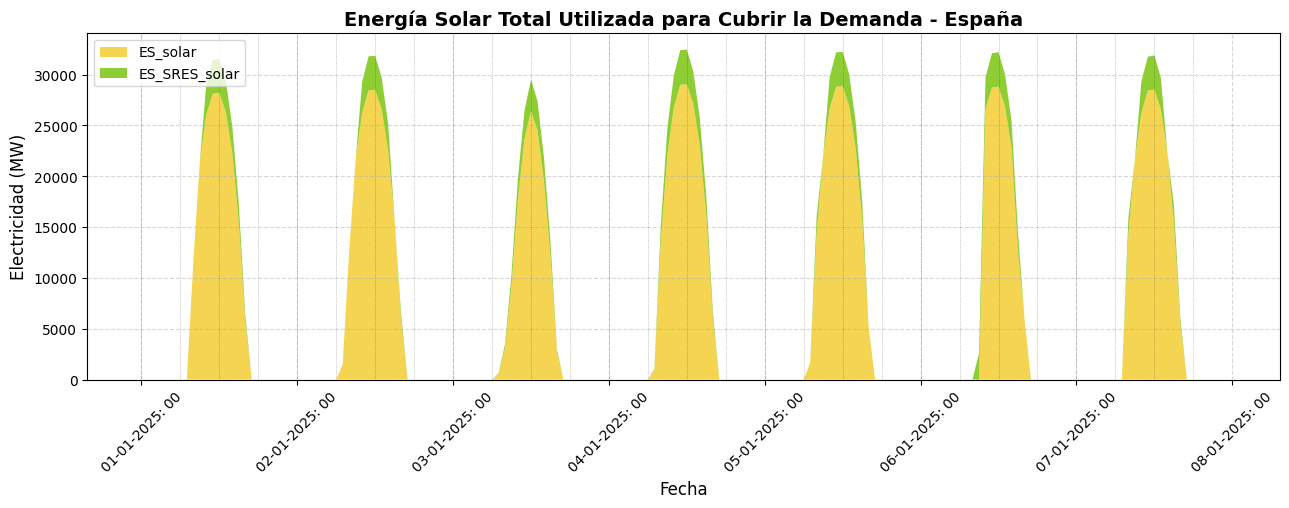

In [115]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "ES_solar",
    "ES_SRES_solar",

]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#F4D03F",  # amarillo solar suave
    "#82C91E",  # verde natural (excedentes)
    "#4C6EF5",  # azul suave (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Energía Solar Total Utilizada para Cubrir la Demanda - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

In [116]:
def debug_sres_capacities(n):
    print("\n================ CAPACITY CHECK ================\n")

    def country_check(c, solar_share_expected=None):
        print(f"\n---- {c} ----")

        g = n.generators
        l = n.links

        # Generators
        sol_ex = g.p_nom_opt[f"{c}_SRES_excedentes_solar"]
        win_ex = g.p_nom_opt[f"{c}_SRES_excedentes_wind"]
        sol_el = g.p_nom_opt[f"{c}_SRES_electrolizador_solar"]
        win_el = g.p_nom_opt[f"{c}_SRES_electrolizador_wind"]

        total_gen = sol_ex + win_ex

        print(f"Solar_excedentes: {sol_ex:.2f}")
        print(f"Wind_excedentes : {win_ex:.2f}")
        print(f"Solar_electrol  : {sol_el:.2f}")
        print(f"Wind_electrol   : {win_el:.2f}")
        print(f"TOTAL_GEN       : {total_gen:.2f}")

        # Ratios
        solar_ratio = sol_ex / total_gen if total_gen > 0 else 0
        print(f"Solar ratio = {solar_ratio:.4f}")

        if solar_share_expected is not None:
            print(f"Expected     = {solar_share_expected:.4f}")
            print(f"Diff         = {solar_ratio - solar_share_expected:.6f}")

        # Links
        ex_link = l.p_nom_opt[f"{c}_SRES_excedentes"]
        el_link = l.p_nom_opt[f"{c}_SRES_electrolyzer"]

        print("\nLINK BALANCE")
        print(f"Excedentes link : {ex_link:.2f}")
        print(f"Electrolyzer    : {el_link:.2f}")
        print(f"Sum links       : {ex_link + el_link:.2f}")
        print(f"Gen total       : {total_gen:.2f}")
        print(f"Diff            : {(ex_link + el_link) - total_gen:.6f}")

    country_check("ES", 0.5)
    country_check("PT", 0.5592)


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\891584209.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\891584209.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



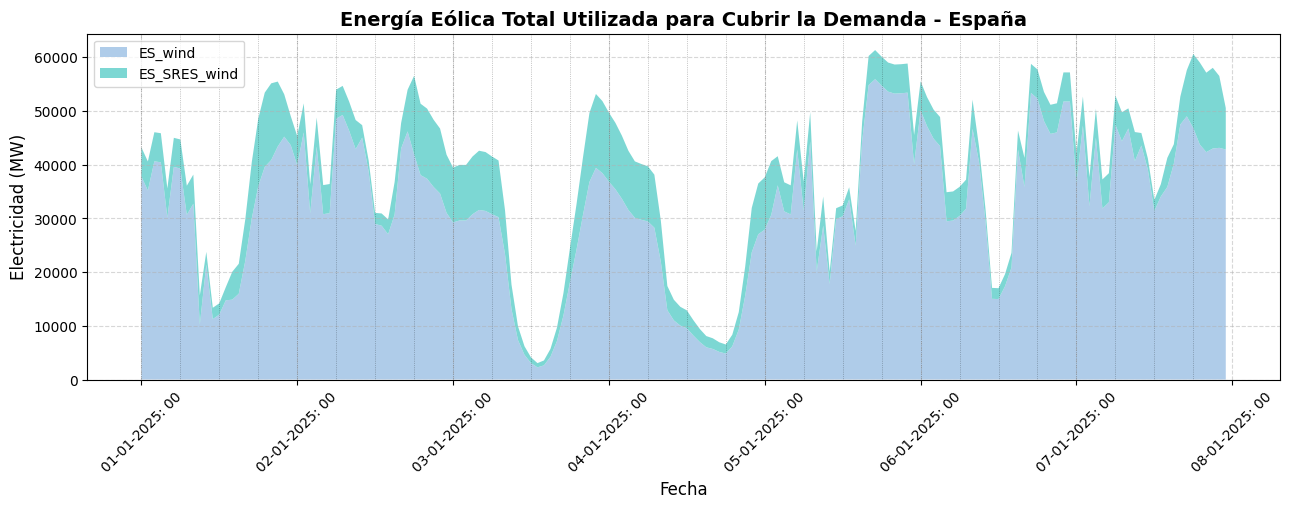

In [117]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "ES_wind",
    "ES_SRES_wind",

]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#A7C7E7",  # azul cielo (wind)
    "#6ED3CF",  # turquesa suave (excedentes)
    "#2F5D9F",  # azul profundo (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Energía Eólica Total Utilizada para Cubrir la Demanda - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3368096690.py:6: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3368096690.py:7: DeprecatedWarning:

df is deprecated as of 1.0rc1 and will be removed in 2.0. Use `c.static` instead.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3368096690.py:33: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3368096690.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



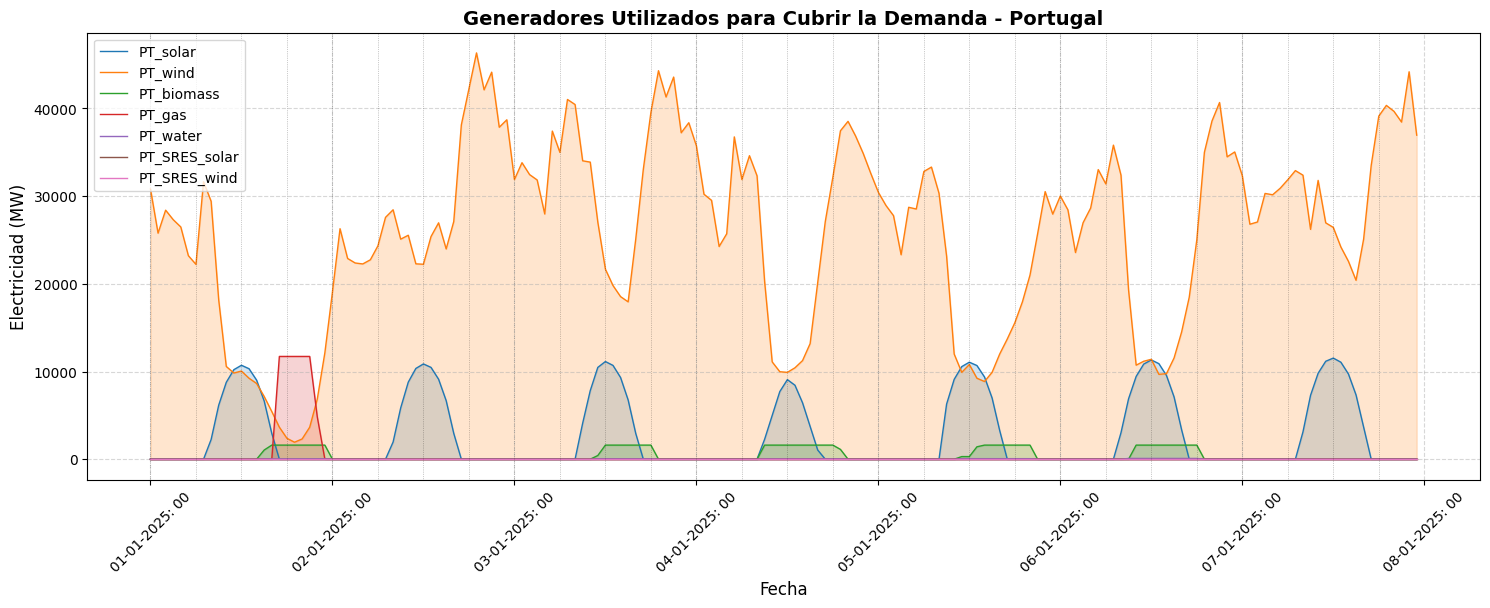

In [118]:
# GENERADORES UTILIZADOS EN PORTUGAL PARA CUBRIR DEMANDA: con este plot podemos graficar la aportación de los generadores sólo de Portugal (sabiendo que los buses de Portugal empiezan por "PT_")
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Obtener DataFrames de generadores y buses (compatibles con varias versiones) ===
try:
    # API nueva (componentes con .df)
    gen_df = network.components["Generator"].df
    buses_df = network.components["Bus"].df
except (AttributeError, KeyError):
    # API clásica (atributos DataFrame)
    gen_df = network.generators
    buses_df = network.buses
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Definir qué es "Portugal" para los buses ===
# Por nombre del bus (prefijo PT_)
is_pt_bus = buses_df.index.str.startswith("PT_")
pt_buses = set(buses_df.index[is_pt_bus])
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Filtrar generadores cuyo 'bus' pertenece a Portugal ===
if "bus" in gen_df.columns:
    generadores_pt = gen_df.index[gen_df["bus"].isin(pt_buses)]
else:
    # Fallback por nombre del generador si no existe la columna 'bus'
    generadores_pt = gen_df.index[gen_df.index.str.startswith("PT_")]
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Rango temporal ===
hours = pd.date_range(start="2025-01-01", end="2025-01-07 23:00", freq="h")
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Graficar potencia sólo de generadores de Portugal ===
plt.figure(figsize=(15, 6))
plt.style.use('default')

# Las series temporales están en network.generators_t.p
cols_disponibles = [g for g in generadores_pt if g in network.generators_t.p.columns]

for gen in cols_disponibles:
    y = network.generators_t.p[gen].reindex(hours)  # alinear al rango
    plt.plot(hours, y, label=gen, linewidth=1)
    plt.fill_between(hours, y, color=plt.gca().lines[-1].get_color(), alpha=0.2)
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Generadores Utilizados para Cubrir la Demanda - Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()

# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)

# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.show()
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [119]:
print("PT demanda max (MW):", network.loads_t.p_set["PT_demand_2040"].max())
print("ES demanda max (MW):", network.loads_t.p_set["ES_demand_2040"].max())

# y el shedding:
names = network.generators.static.index[network.generators.static.carrier=="load_shedding"]
print(network.generators_t.p[names].max())

PT demanda max (MW): 34597.00195694716
ES demanda max (MW): 57703.08642907063
Series([], dtype: float64)


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3006000797.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3006000797.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3006000797.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3288768848.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3288768848.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



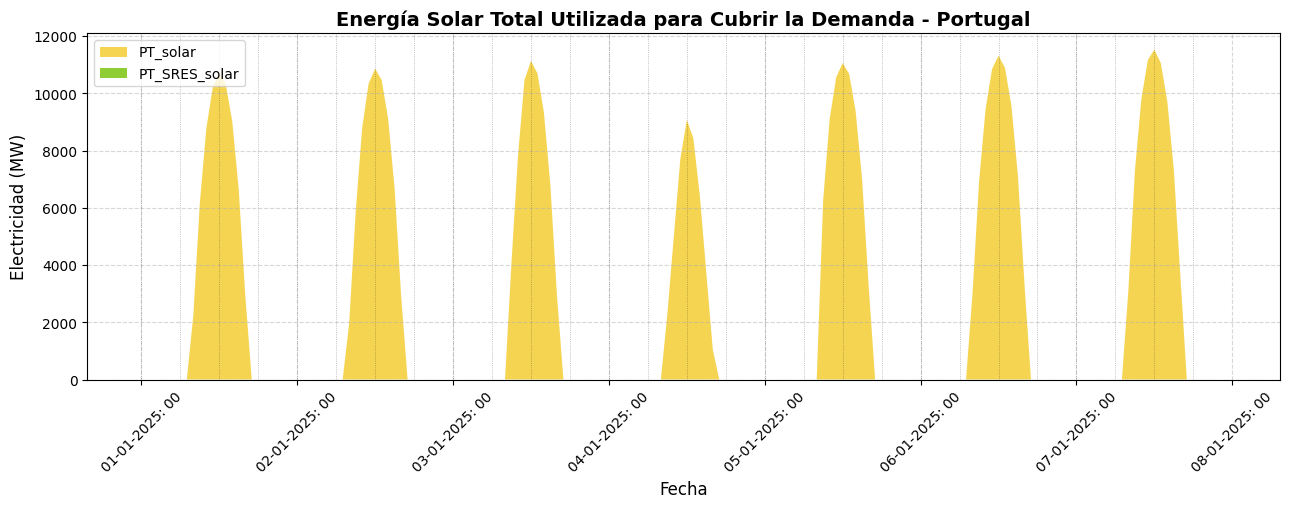

In [120]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "PT_solar",
    "PT_SRES_solar",
    
]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#F4D03F",  # amarillo solar suave
    "#82C91E",  # verde natural (excedentes)
    "#4C6EF5",  # azul suave (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Energía Solar Total Utilizada para Cubrir la Demanda - Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1242906240.py:13: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1242906240.py:14: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.



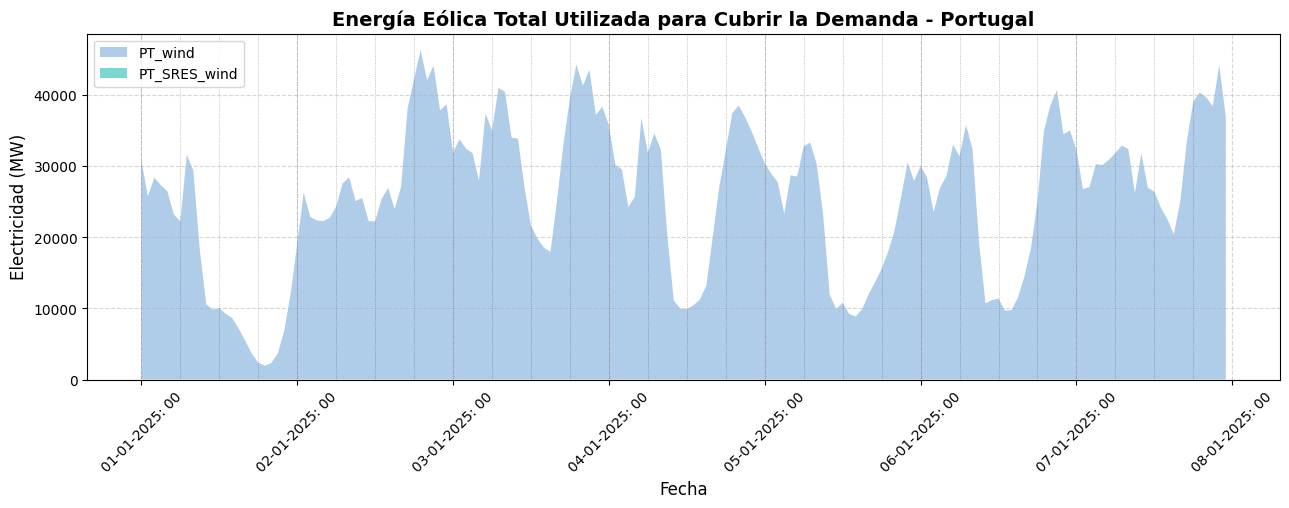

In [121]:
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.figure(figsize=(13, 5))
plt.style.use('default')
generadores_interes = [
    "PT_wind",
    "PT_SRES_wind",

]
series = []
labels = []

for gen in generadores_interes:
    if gen in network.generators_t.p.columns:
        series.append(network.generators_t.p[gen].reindex(hours).values)
        labels.append(gen)

# Stackplot (acumulado)
colors = [
    "#A7C7E7",  # azul cielo (wind)
    "#6ED3CF",  # turquesa suave (excedentes)
    "#2F5D9F",  # azul profundo (electrolizador)
]

plt.stackplot(
    hours,
    series,
    labels=labels,
    colors=colors,
    alpha=0.9
)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# === Personalización ===
plt.title("Energía Eólica Total Utilizada para Cubrir la Demanda - Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Electricidad (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
# Líneas verticales cada 6 horas
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
# Formato del eje X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Comando de graficar
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3175466517.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



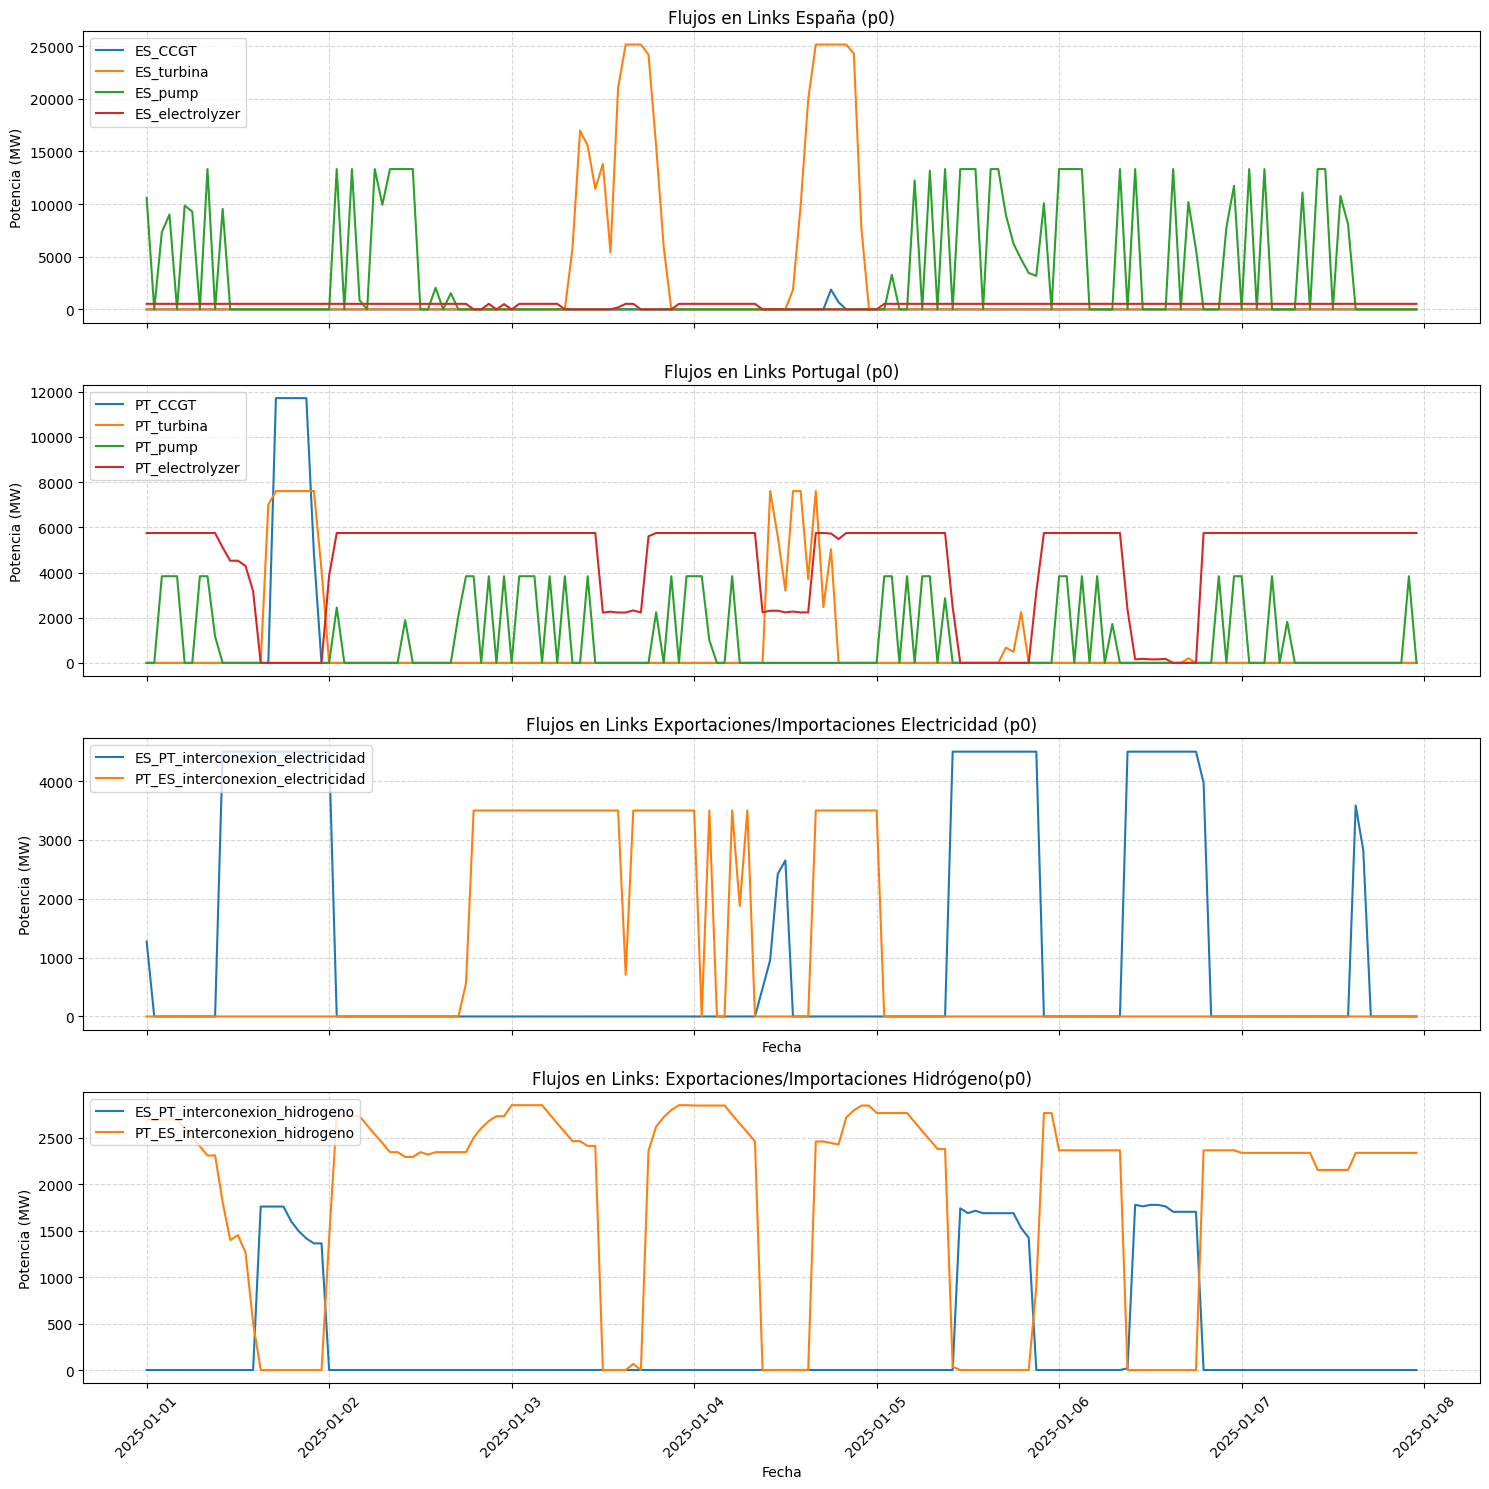

In [122]:
p0 = network.links_t.p0
links_ES = [
    "ES_CCGT",
    "ES_turbina",
    "ES_pump",
    "ES_electrolyzer",
]

links_PT = [
    "PT_CCGT",
    "PT_turbina",
    "PT_pump",
    "PT_electrolyzer",
]

links_exportaciones_electricidad = [
    "ES_PT_interconexion_electricidad",
    "PT_ES_interconexion_electricidad",
]

links_exportaciones_hidrogeno = [
    "ES_PT_interconexion_hidrogeno",
    "PT_ES_interconexion_hidrogeno",
]

# --- Crear figura con 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(15, 15), sharex=True)  # 3 filas, 1 columna
 
# --- GRAFICO ESPAÑA ---
for link in links_ES:
    if link in p0.columns:
        axes[0].plot(network.snapshots, p0[link], label=link)
axes[0].set_title("Flujos en Links España (p0)")
axes[0].set_ylabel("Potencia (MW)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="upper left")
 
# --- GRAFICO PORTUGAL ---
for link in links_PT:
    if link in p0.columns:
        axes[1].plot(network.snapshots, p0[link], label=link)
axes[1].set_title("Flujos en Links Portugal (p0)")
axes[1].set_ylabel("Potencia (MW)")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(loc="upper left")
 
# --- GRAFICO EXPORTACIONES electricidad ---
for link in links_exportaciones_electricidad:
    if link in p0.columns:
        axes[2].plot(network.snapshots, p0[link], label=link)
axes[2].set_title("Flujos en Links Exportaciones/Importaciones Electricidad (p0)")
axes[2].set_xlabel("Fecha")
axes[2].set_ylabel("Potencia (MW)")
axes[2].grid(True, linestyle="--", alpha=0.5)
axes[2].legend(loc="upper left")

 

# --- GRAFICO EXPORTACIONES hidrogeno---
for link in links_exportaciones_hidrogeno:
    if link in p0.columns:
        axes[3].plot(network.snapshots, p0[link], label=link)
axes[3].set_title("Flujos en Links: Exportaciones/Importaciones Hidrógeno(p0)")
axes[3].set_xlabel("Fecha")
axes[3].set_ylabel("Potencia (MW)")
axes[3].grid(True, linestyle="--", alpha=0.5)
axes[3].legend(loc="upper left")

# Ajustar diseño
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\941454363.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



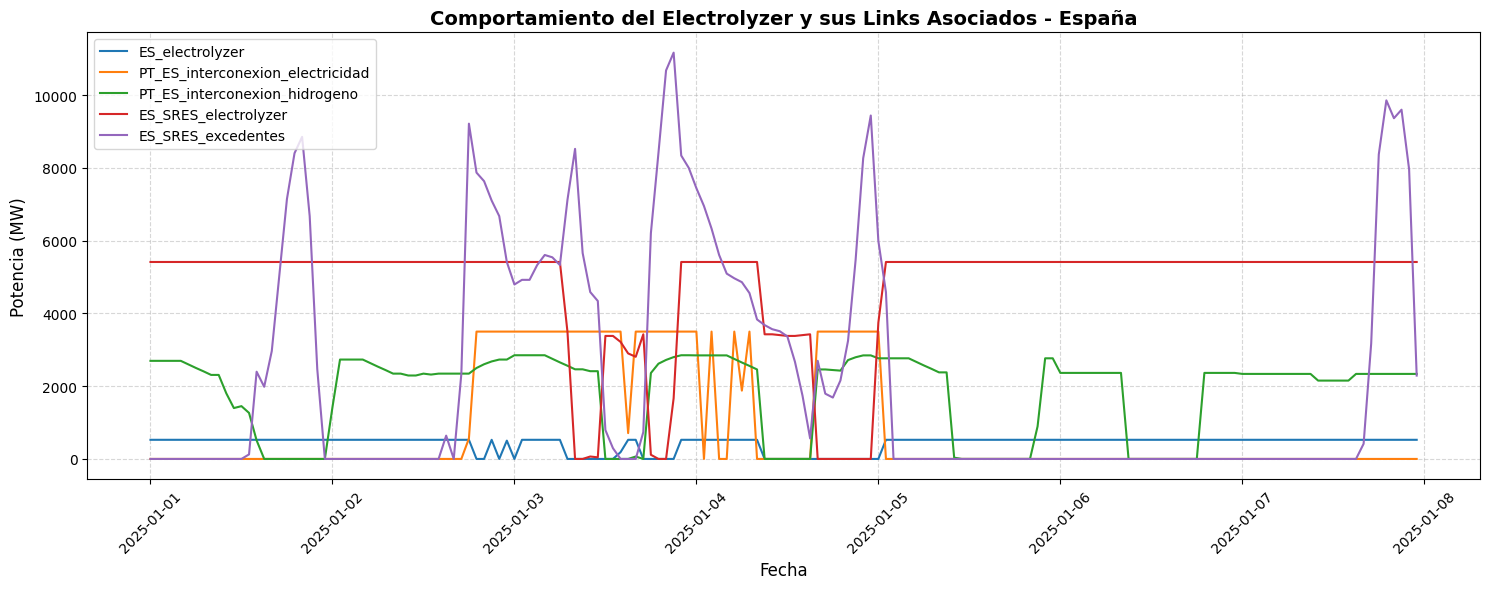

In [123]:
p0 = network.links_t.p0
comportamiento_electrolyzer = [
    "ES_electrolyzer",
    "PT_ES_interconexion_electricidad",
    "PT_ES_interconexion_hidrogeno",
    "ES_SRES_electrolyzer",
    "ES_SRES_excedentes"

]


# haz una grafica donde estén los links relacionados con el comportamiento del electrolyzer en España y Portugal
plt.figure(figsize=(15,6))
for link in comportamiento_electrolyzer:
    if link in p0.columns:
        plt.plot(network.snapshots, p0[link], label=link)
plt.title("Comportamiento del Electrolyzer y sus Links Asociados - España", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1188415387.py:1: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



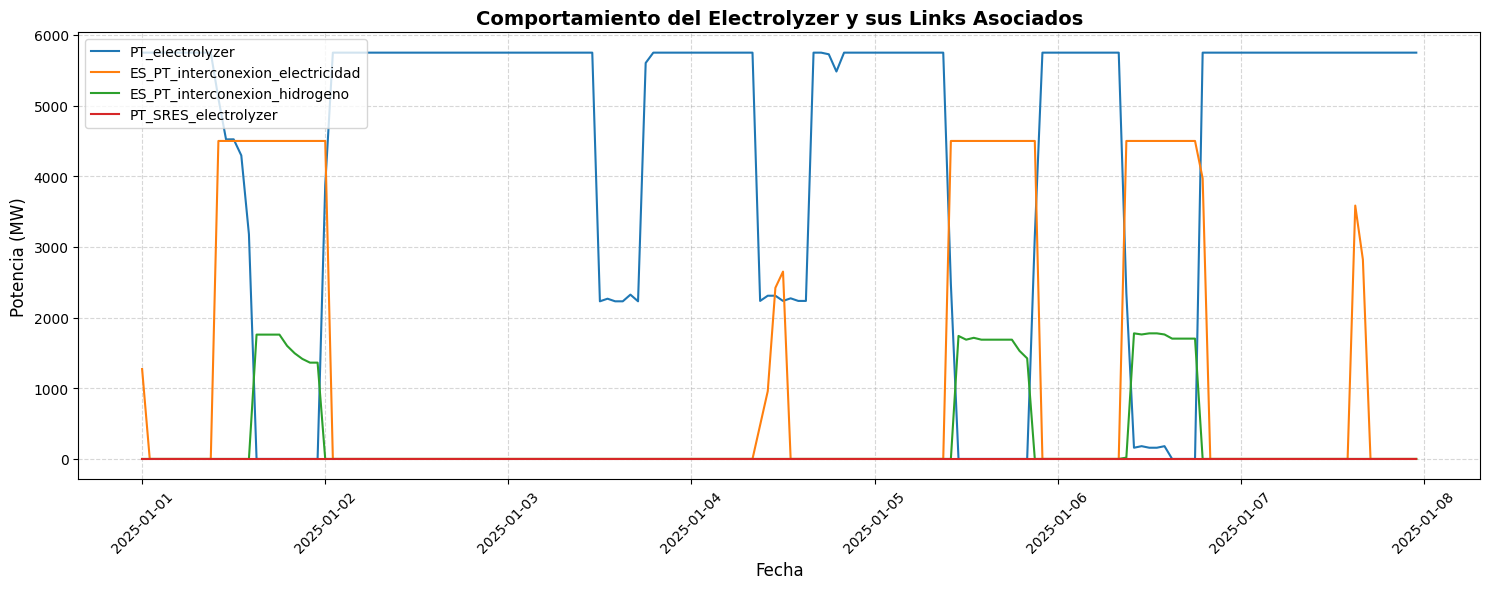

In [124]:
p0 = network.links_t.p0
comportamiento_electrolyzer = [
    "PT_electrolyzer",
    "ES_PT_interconexion_electricidad",
    "ES_PT_interconexion_hidrogeno",
    "PT_SRES_electrolyzer"

]


# haz una grafica donde estén los links relacionados con el comportamiento del electrolyzer en España y Portugal
plt.figure(figsize=(15,6))
for link in comportamiento_electrolyzer:
    if link in p0.columns:
        plt.plot(network.snapshots, p0[link], label=link)
plt.title("Comportamiento del Electrolyzer y sus Links Asociados", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Potencia (MW)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3866361918.py:16: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3866361918.py:17: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3866361918.py:23: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3866361918.py:24: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.li

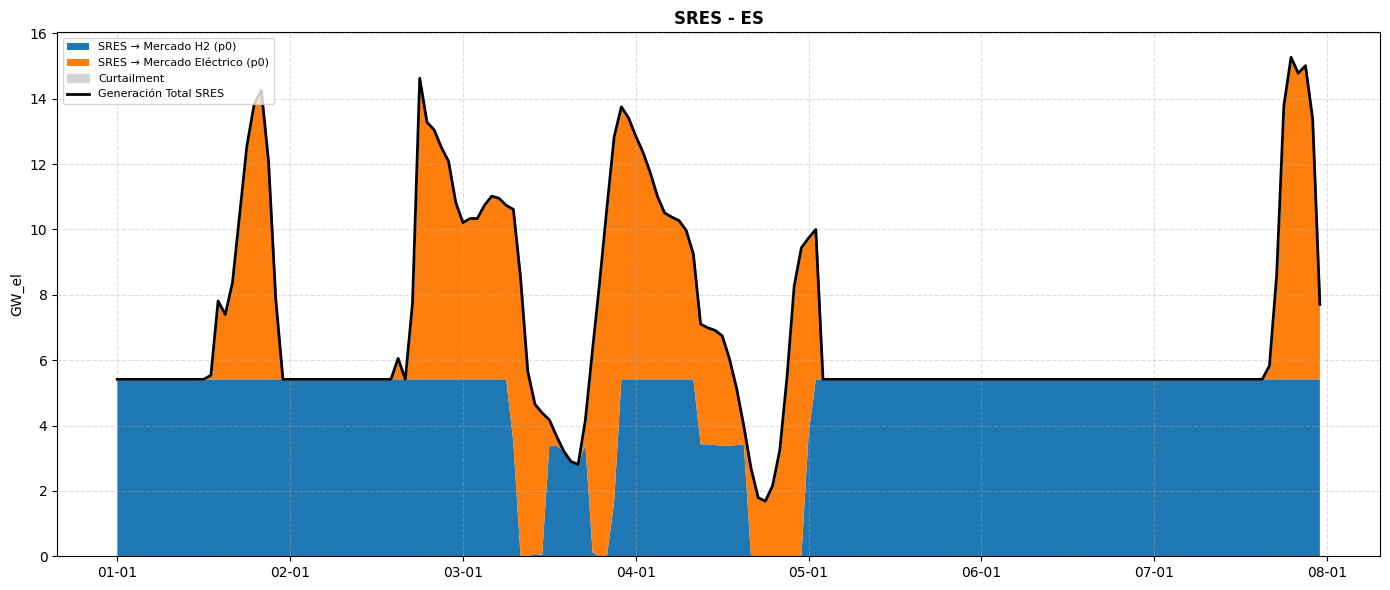

[DEBUG ES] residual medio (MW): 7.308439567818174e-14
[DEBUG ES] residual max (MW): 8.185452315956354e-12


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3866361918.py:16: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3866361918.py:17: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3866361918.py:23: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3866361918.py:24: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.li

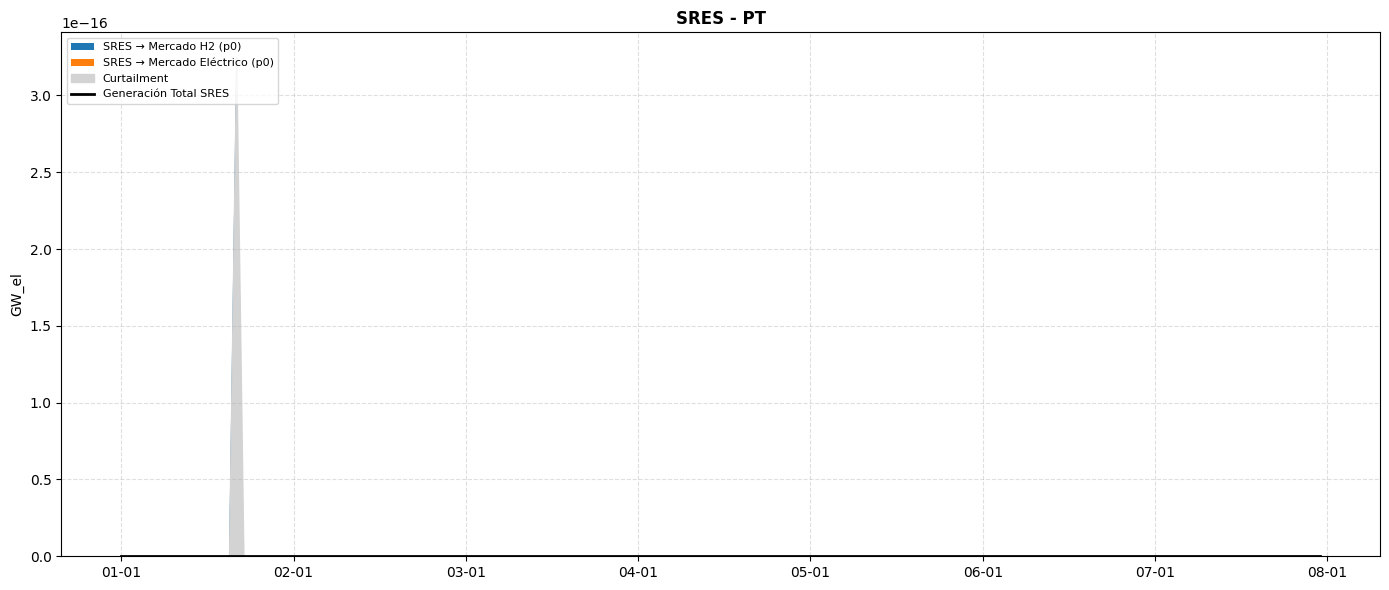

[DEBUG PT] residual medio (MW): 0.0
[DEBUG PT] residual max (MW): 0.0


In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_sres_use_electric_units(n, country="ES"):
    sns = n.snapshots

    g_solar = f"{country}_SRES_solar"
    g_wind  = f"{country}_SRES_wind"
    l_ely   = f"{country}_SRES_electrolyzer"
    l_ex    = f"{country}_SRES_excedentes"

    # 1) Generación eléctrica SRES (MW_el)
    sres_gen = 0.0
    for g in [g_solar, g_wind]:
        if g in n.generators_t.p.columns:
            sres_gen = sres_gen + n.generators_t.p[g]
        else:
            print("No existe generador:", g)

    # 2) Electricidad consumida por el electrolizador SRES = p0 (MW_el)
    #    (p1 es H2 y va en MW_H2, NO lo uses aquí)
    if l_ely in n.links_t.p0.columns:
        sres_to_h2_el = n.links_t.p0[l_ely].clip(lower=0)
    else:
        sres_to_h2_el = 0.0
        print("No existe link:", l_ely)

    # 3) Electricidad a mercado desde SRES = p0 (MW_el)
    if l_ex in n.links_t.p0.columns:
        sres_to_market = n.links_t.p0[l_ex].clip(lower=0)
    else:
        sres_to_market = 0.0
        print("No existe link:", l_ex)

    # 4) “Descuadre” (debería ser ~0 si el bus SRES solo tiene esas salidas)
    residual = (sres_gen - sres_to_h2_el - sres_to_market).clip(lower=0)

    # Plot en GW_el
    plt.figure(figsize=(14,6))
    plt.stackplot(
        sns,
        (sres_to_h2_el/1e3),
        (sres_to_market/1e3),
        labels=["SRES → Mercado H2 (p0)", "SRES → Mercado Eléctrico (p0)"]
    )
    plt.fill_between(
        sns,
        (sres_to_h2_el + sres_to_market)/1e3,
        (sres_gen)/1e3,
        color="lightgrey",
        label="Curtailment"
    )
    plt.plot(sns, sres_gen/1e3, color="black", lw=2, label="Generación Total SRES")
    plt.title(f"SRES - {country}", fontweight="bold")
    plt.ylabel("GW_el")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(loc="upper left", fontsize=8)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
    plt.tight_layout()
    plt.show()

    print(f"[DEBUG {country}] residual medio (MW):", float(residual.mean()))
    print(f"[DEBUG {country}] residual max (MW):", float(residual.max()))

plot_sres_use_electric_units(network, "ES")
plot_sres_use_electric_units(network, "PT")

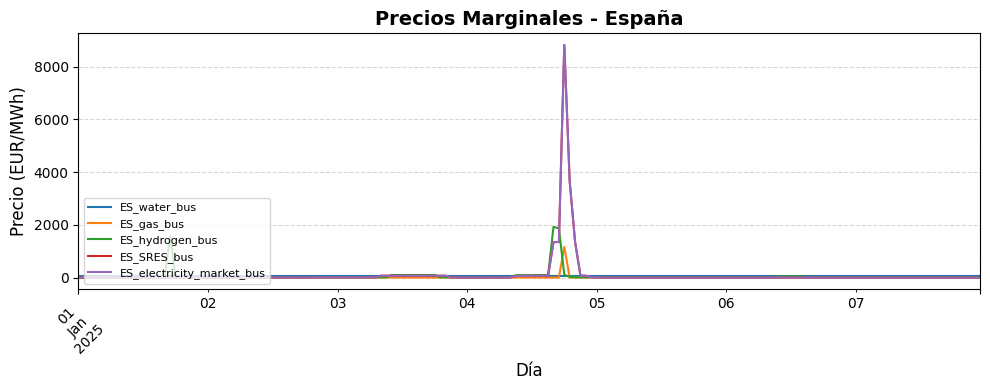

In [126]:
import matplotlib.pyplot as plt
mp = network.buses.dynamic["marginal_price"]
# Sustituye nom1..nom4 por los nombres reales de tus buses ES
nom1 = "ES_water_bus"
nom2 = "ES_gas_bus"
nom3 = "ES_hydrogen_bus"
nom4 = "ES_SRES_bus"
nom5 = "ES_electricity_market_bus"
buses_es = [nom1, nom2, nom3, nom4, nom5]
# (opcional) filtra solo los que existan para que no pete si te equivocas
buses_es_ok = [b for b in buses_es if b in mp.columns]
mp[buses_es_ok].plot(figsize=(10,4), title="Precios marginales - España (buses seleccionados)")
plt.title("Precios Marginales - España", fontsize=14, fontweight="bold")
plt.xlabel("Día", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

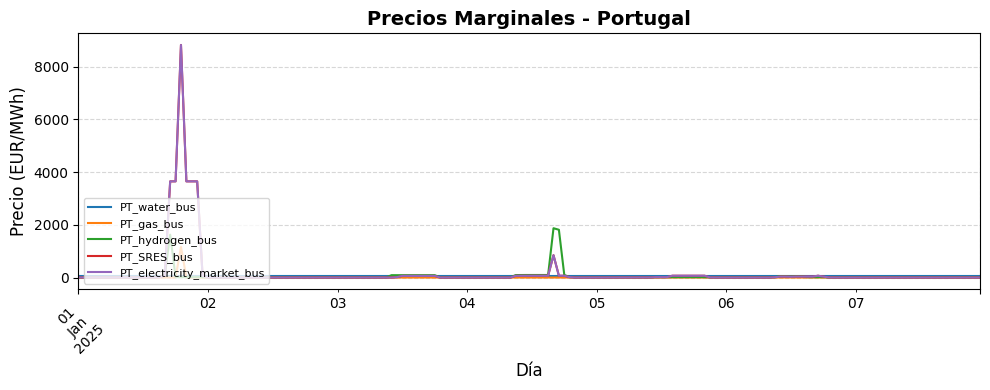

In [127]:
import matplotlib.pyplot as plt
mp = network.buses.dynamic["marginal_price"]
# Sustituye nom1..nom4 por los nombres reales de tus buses ES
nom1 = "PT_water_bus"
nom2 = "PT_gas_bus"
nom3 = "PT_hydrogen_bus"
nom4 = "PT_SRES_bus"
nom5 = "PT_electricity_market_bus"
# (opcional) filtra solo los que existan para que no pete si te equivocas
buses_es_ok = [nom1, nom2, nom3, nom4, nom5]
mp[buses_es_ok].plot(figsize=(10,4), title="Precios marginales - Portugal (buses seleccionados)")
plt.title("Precios Marginales - Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Día", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

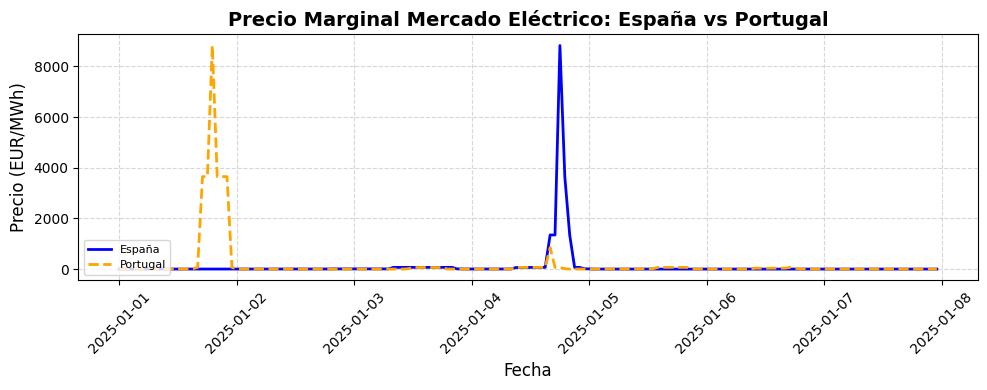

In [128]:

# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_electricity_market_bus", "PT_electricity_market_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(10,4))

if "ES_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_electricity_market_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_electricity_market_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_electricity_market_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Precio Marginal Mercado Eléctrico: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

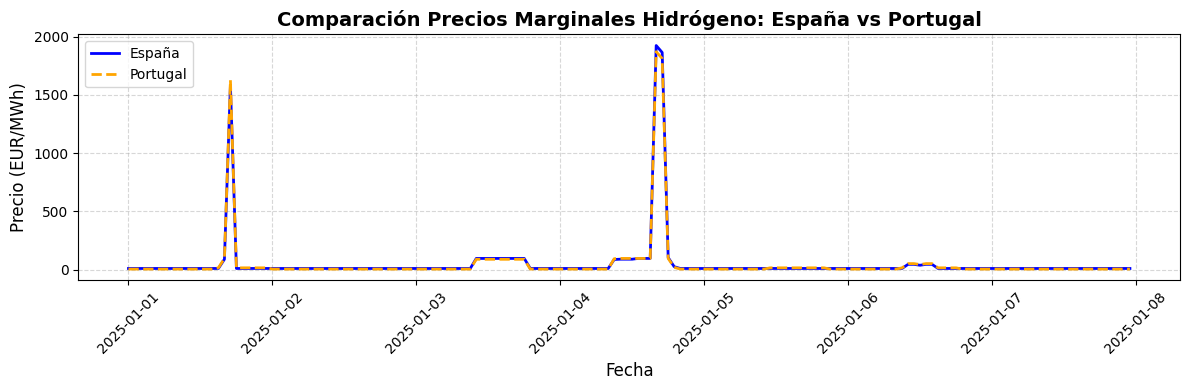

In [129]:
# Filtrar precios marginales para buses eléctricos
marginal_prices = network.buses.dynamic["marginal_price"]

# Seleccionar columnas específicas
cols_electricity = ["ES_hydrogen_bus", "PT_hydrogen_bus"]

# Verificar que existen en el DataFrame
available_cols = [col for col in cols_electricity if col in marginal_prices.columns]

# Graficar con estilos diferentes
plt.figure(figsize=(12,4))

if "ES_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["ES_hydrogen_bus"],
             label="España", color="blue", linestyle="-", linewidth=2)  # Línea continua

if "PT_hydrogen_bus" in available_cols:
    plt.plot(network.snapshots, marginal_prices["PT_hydrogen_bus"],
             label="Portugal", color="orange", linestyle="--", linewidth=2)  # Línea discontinua

# Personalización
plt.title("Comparación Precios Marginales Hidrógeno: España vs Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Precio (EUR/MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1122075521.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1122075521.py:29: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1122075521.py:38: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1122075521.py:41: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic

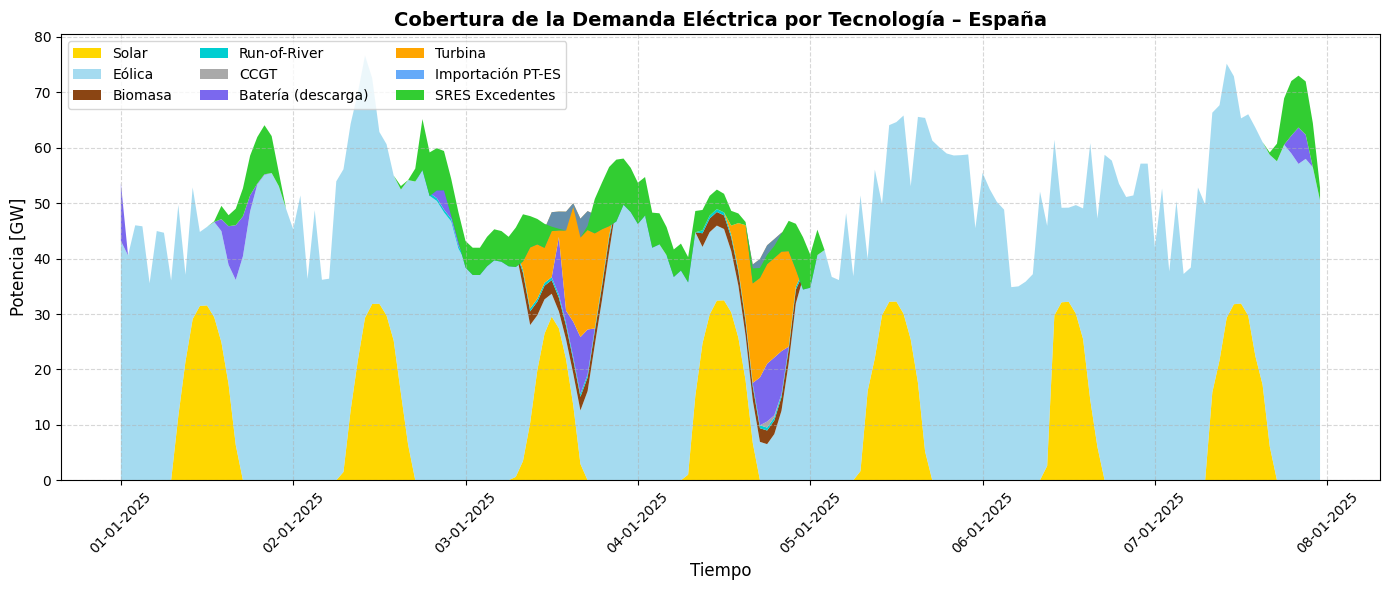

In [130]:
times = network.snapshots
gen = network.generators_t.p
gen_names = gen.columns.str.lower()
renew_map = {
    "ES_Solar":   "es_solar",  
    "ES_Eólica":  "es_wind",
    "ES_Biomasa": "es_biomass",
    "ES_Water":   "es_water",
}
renew_series = {}
for label, key in renew_map.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        print(f"No se encontraron generadores con '{key}'")
        renew_series[label] = 0.0
    else:
        renew_series[label] = gen[gens].sum(axis=1)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# LINKS UTILIZADOS EN ESPAÑA PARA CUBRIR DEMANDA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
links_car = network.links.static.index.str.lower()
# Link 1 que genera electricidad: CCGT
ccgt_name = [
    n for n in network.links.static.index
    if "es_ccgt" in n.lower()
]
if len(ccgt_name) == 0:
    print("No se encontró ningún link con 'CCGT'")
CCGT = -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0)

# Link 2 que genera electricidad: TURBINA
turb_name = [
    n for n in network.links.static.index
    if "es_turbina" in n.lower()
]
if len(turb_name) == 0:
    print("No se encontró ningún link con 'turbina'")
turb = -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0)

# Link 3 que genera electricidad: Importacion PT-ES Eléctricidad
import_es_pt = network.links_t.p1["PT_ES_interconexion_electricidad"].clip(upper=0)

# Link 4: sres_excedentes (excedentes renovables)
sres_excedentes_name = [
    n for n in network.links.static.index
    if "es_sres_excedentes" in n.lower()
]
if len(sres_excedentes_name) == 0:
    print("No se encontró ningún link con 'es_sres_excedentes'")
sres_excedentes = -network.links_t.p1[sres_excedentes_name].sum(axis=1).clip(upper=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# STORAGE UNITS: BATERÍAS ELECTRICIDAD Y ALMACENAMIENTO DE HIDRÓGENO
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

su_names = network.storage_units.static.index.str.lower()

battery_sus = [n for n in network.storage_units.static.index if "es_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.static.index if "es_hydrogen_storage" in n.lower()]

# 6) Potencia neta
bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

battery_discharge = bat_net.clip(lower=0)
h2_discharge = h2_net.clip(lower=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DATAFRAME PARA GRÁFICA DE COBERTURA DE DEMANDA EN ESPAÑA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


df_plot = pd.DataFrame({
    "ES_Solar":         renew_series["ES_Solar"]     / 1e3,
    "ES_Eólica":        renew_series["ES_Eólica"]      / 1e3,
    "ES_Biomasa":       renew_series["ES_Biomasa"]   / 1e3,
    "ES_Run-of-River":  renew_series["ES_Water"]     / 1e3,
    "ES_CCGT":          CCGT                      / 1e3,
    "ES_electricity_market_battery":      battery_discharge         / 1e3,
    "ES_turbina":       turb                      / 1e3,
    "PT_ES_interconexion_electricidad": import_es_pt / 1e3,
    "ES_sres_excedentes": sres_excedentes / 1e3,
}, index=times)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# COLORES PARA GRÁFICA Y TECNOLOGÍA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

colors = {
    "ES_Solar":                           "#FFD700",
    "ES_Eólica":                          "#87CFEBBE",
    "ES_Biomasa":                         "#8B4513",
    "ES_Run-of-River":                    "#00CED1",
    "ES_CCGT":                            "#A9A9A9",
    "ES_electricity_market_battery":      "#7B68EE",
    "ES_turbina":                         "#FFA500",
    "ES_sres_excedentes":               "#32CD32",
    "PT_ES_interconexion_electricidad":   "#2386F7B2",
}

c = [colors[col] for col in df_plot.columns]

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# PERSONALIZACIÓN DE LA GRÁFICA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.stackplot(
    df_plot.index,
    df_plot["ES_Solar"], df_plot["ES_Eólica"], df_plot["ES_Biomasa"], df_plot["ES_Run-of-River"], df_plot["ES_CCGT"], df_plot["ES_electricity_market_battery"], df_plot["ES_turbina"], df_plot["PT_ES_interconexion_electricidad"],df_plot["ES_sres_excedentes"],
    labels=["Solar","Eólica","Biomasa","Run-of-River","CCGT","Batería (descarga)","Turbina","Importación PT-ES", "SRES Excedentes"],
    colors=[colors["ES_Solar"],colors["ES_Eólica"],colors["ES_Biomasa"],colors["ES_Run-of-River"],colors["ES_CCGT"],colors["ES_electricity_market_battery"],colors["ES_turbina"],colors["PT_ES_interconexion_electricidad"], colors["ES_sres_excedentes"]],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda Eléctrica por Tecnología – España",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\301567258.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.generators.dynamic` as a drop-in replacement for `n.generators_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\301567258.py:31: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\301567258.py:40: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\301567258.py:43: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as

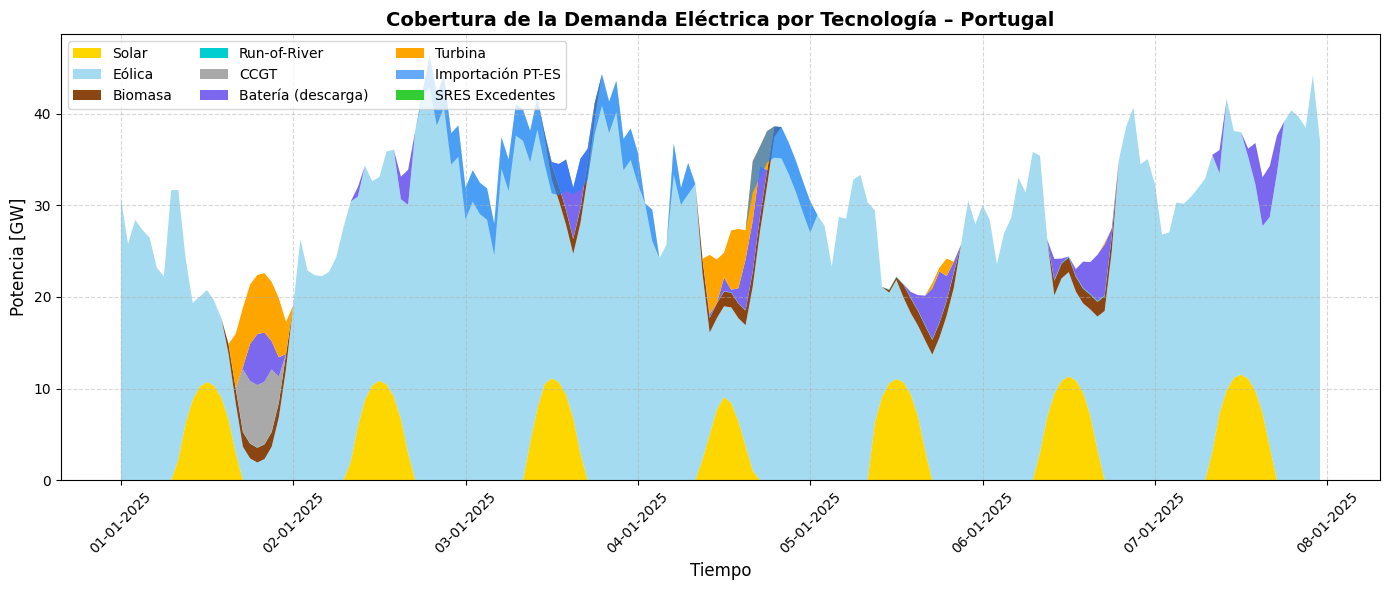

In [131]:
# PORTUGAL. OJO PONER LOAD SHEDDING
times = network.snapshots
gen = network.generators_t.p
gen_names = gen.columns.str.lower()
renew_map = {
    "PT_Solar":   "pt_solar",  
    "PT_Eólica":  "pt_wind",
    "PT_Biomasa": "pt_biomass",
    "PT_Water":   "pt_water",
   # "PT_Load_shedding": "pt_load_shedding"
}
renew_series = {}
for label, key in renew_map.items():
    gens = gen.columns[gen_names.str.contains(key)]
    if len(gens) == 0:
        print(f"No se encontraron generadores con '{key}'")
        renew_series[label] = 0.0
    else:
        renew_series[label] = gen[gens].sum(axis=1)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# LINKS UTILIZADOS EN ESPAÑA PARA CUBRIR DEMANDA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
links_car = network.links.static.index.str.lower()
# Link 1 que genera electricidad: CCGT
ccgt_name = [
    n for n in network.links.static.index
    if "pt_ccgt" in n.lower()
]
if len(ccgt_name) == 0:
    print("No se encontró ningún link con 'CCGT'")
CCGT = -network.links_t.p1[ccgt_name].sum(axis=1).clip(upper=0)

# Link 2 que genera electricidad: TURBINA
turb_name = [
    n for n in network.links.static.index
    if "pt_turbina" in n.lower()
]
if len(turb_name) == 0:
    print("No se encontró ningún link con 'turbina'")
turb = -network.links_t.p1[turb_name].sum(axis=1).clip(upper=0)

# Link 3 que genera electricidad: Importacion ES-PT Eléctricidad
import_pt_es = network.links_t.p1["ES_PT_interconexion_electricidad"].clip(upper=0)



# Link 4: sres_excedentes (excedentes renovables)
sres_excedentes_name = [
    n for n in network.links.static.index
    if "pt_sres_excedentes" in n.lower()
]
if len(sres_excedentes_name) == 0:
    print("No se encontró ningún link con 'pt_sres_excedentes'")
sres_excedentes = -network.links_t.p1[sres_excedentes_name].sum(axis=1).clip(upper=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# STORAGE UNITS: BATERÍAS ELECTRICIDAD Y ALMACENAMIENTO DE HIDRÓGENO
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

su_names = network.storage_units.static.index.str.lower()

battery_sus = [n for n in network.storage_units.static.index if "pt_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in network.storage_units.static.index if "pt_hydrogen_storage" in n.lower()]

# 6) Potencia neta
bat_net = network.storage_units_t.p[battery_sus].sum(axis=1)
h2_net  = network.storage_units_t.p[h2_sus].sum(axis=1)

battery_discharge = bat_net.clip(lower=0)
h2_discharge = h2_net.clip(lower=0)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# DATAFRAME PARA GRÁFICA DE COBERTURA DE DEMANDA EN ESPAÑA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


df_plot = pd.DataFrame({
    "PT_Solar":         renew_series["PT_Solar"]     / 1e3,
    "PT_Eólica":        renew_series["PT_Eólica"]      / 1e3,
    "PT_Biomasa":       renew_series["PT_Biomasa"]   / 1e3,
    "PT_Run-of-River":  renew_series["PT_Water"]     / 1e3,
    "PT_CCGT":          CCGT                      / 1e3,
    "PT_electricity_market_battery":      battery_discharge         / 1e3,
    "PT_turbina":       turb                      / 1e3,
    "ES_PT_interconexion_electricidad": import_es_pt / 1e3,
    "PT_sres_excedentes": sres_excedentes / 1e3,
    
}, index=times)

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# COLORES PARA GRÁFICA Y TECNOLOGÍA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

colors = {
    "PT_Solar":                           "#FFD700",
    "PT_Eólica":                          "#87CFEBBE",
    "PT_Biomasa":                         "#8B4513",
    "PT_Run-of-River":                    "#00CED1",
    "PT_CCGT":                            "#A9A9A9",
    "PT_electricity_market_battery":      "#7B68EE",
    "PT_turbina":                         "#FFA500",
    "PT_sres_excedentes":               "#32CD32",
    "ES_PT_interconexion_electricidad":   "#2386F7B2",
    "ES_load_shedding":                   "#FF0000",
}

c = [colors[col] for col in df_plot.columns]

# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# PERSONALIZACIÓN DE LA GRÁFICA
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.figure(figsize=(14, 6))
plt.stackplot(
    df_plot.index,
    df_plot["PT_Solar"], df_plot["PT_Eólica"], df_plot["PT_Biomasa"], df_plot["PT_Run-of-River"], df_plot["PT_CCGT"], df_plot["PT_electricity_market_battery"], df_plot["PT_turbina"], df_plot["ES_PT_interconexion_electricidad"],df_plot["PT_sres_excedentes"],
    labels=["Solar","Eólica","Biomasa","Run-of-River","CCGT","Batería (descarga)","Turbina","Importación PT-ES", "SRES Excedentes"],
    colors=[colors["PT_Solar"],colors["PT_Eólica"],colors["PT_Biomasa"],colors["PT_Run-of-River"],colors["PT_CCGT"],colors["PT_electricity_market_battery"],colors["PT_turbina"],colors["ES_PT_interconexion_electricidad"], colors["PT_sres_excedentes"]],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda Eléctrica por Tecnología – Portugal",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2122139697.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2122139697.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2122139697.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2122139697.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dyna

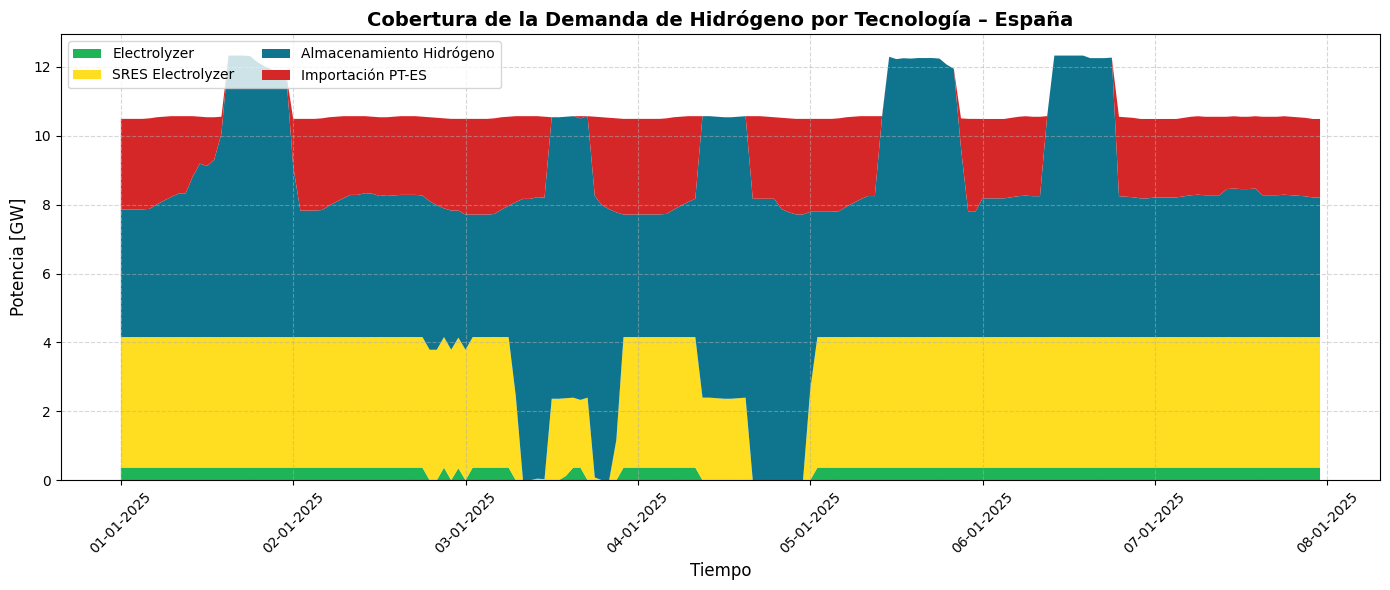

In [132]:
# una grafica con la cobertura de la demanda hidrogeno en España,, que etenemos que tener en cuenta, electrolyzer, electrolyzer_sres, hydrogen_storage, interconexion_hidrogeno
df_h2_plot = pd.DataFrame({
    "ES_electrolyzer":         -network.links_t.p1["ES_electrolyzer"]     / 1e3,
    "ES_SRES_electrolyzer":    -network.links_t.p1["ES_SRES_electrolyzer"] / 1e3,
    "ES_hydrogen_storage":      network.storage_units_t.p["ES_hydrogen_storage"].clip(lower=0) / 1e3,
    "PT_ES_interconexion_hidrogeno": -network.links_t.p1["PT_ES_interconexion_hidrogeno"].clip(upper=0) / 1e3,
}, index=times)
plt.figure(figsize=(14, 6))
plt.stackplot(
    df_h2_plot.index,
    df_h2_plot["ES_electrolyzer"], df_h2_plot["ES_SRES_electrolyzer"], df_h2_plot["ES_hydrogen_storage"], df_h2_plot["PT_ES_interconexion_hidrogeno"],
    labels=["Electrolyzer","SRES Electrolyzer","Almacenamiento Hidrógeno","Importación PT-ES"],
    colors=["#1fb458", "#ffdb0eec", "#0f758f", "#d62728"],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda de Hidrógeno por Tecnología – España",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=10, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3648931789.py:3: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3648931789.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3648931789.py:5: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.



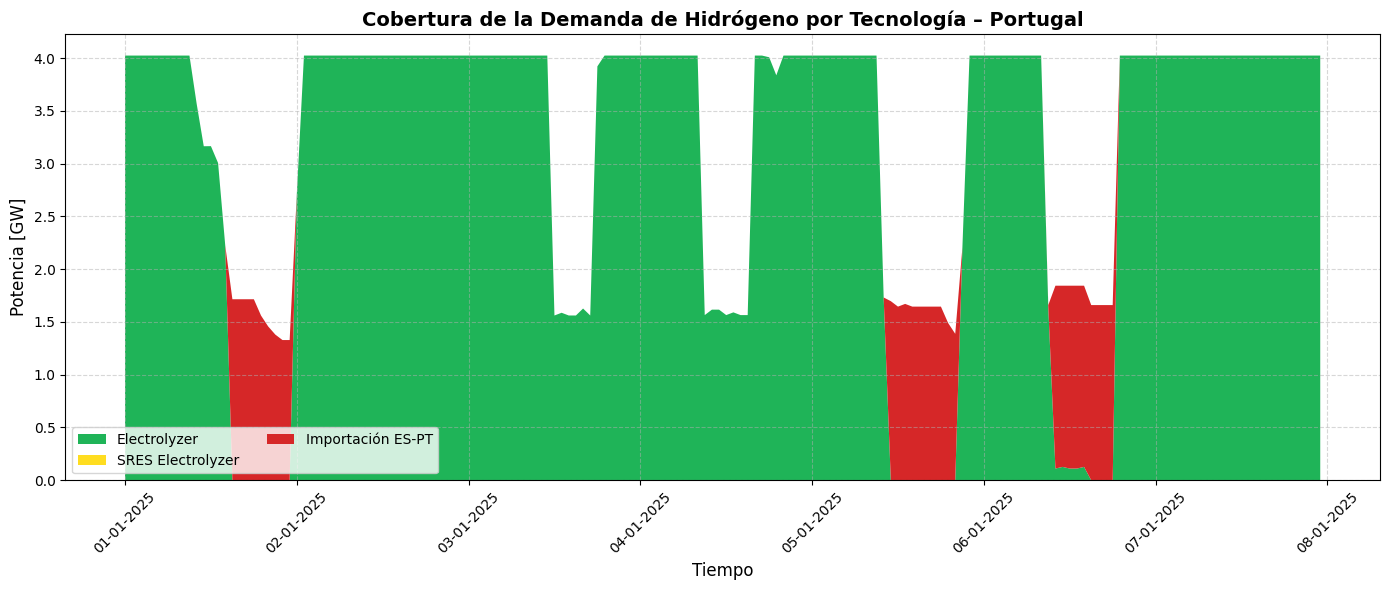

In [133]:
# una grafica con la cobertura de la demanda hidrogeno en España,, que etenemos que tener en cuenta, electrolyzer, electrolyzer_sres, hydrogen_storage, interconexion_hidrogeno
df_h2_plot = pd.DataFrame({
    "PT_electrolyzer":         -network.links_t.p1["PT_electrolyzer"]     / 1e3,
    "PT_SRES_electrolyzer":    -network.links_t.p1["PT_SRES_electrolyzer"] / 1e3,
    "ES_PT_interconexion_hidrogeno": -network.links_t.p1["ES_PT_interconexion_hidrogeno"].clip(upper=0) / 1e3,
}, index=times)
plt.figure(figsize=(14, 6))
plt.stackplot(
    df_h2_plot.index,
    df_h2_plot["PT_electrolyzer"], df_h2_plot["PT_SRES_electrolyzer"], df_h2_plot["ES_PT_interconexion_hidrogeno"],
    labels=["Electrolyzer","SRES Electrolyzer","Importación ES-PT"],
    colors=["#1fb458", "#ffdb0eec", "#d62728"],
    linewidth=0.0,
)
plt.title("Cobertura de la Demanda de Hidrógeno por Tecnología – Portugal",fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=10, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3046094727.py:48: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3046094727.py:49: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3046094727.py:51: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3046094727.py:52: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a dr


=== Cobertura H2 - PT ===
                                             Energía semanal [GWh]  \
Electrolyzer                                             27071.073   
Importación (ES_PT_interconexion_hidrogeno)               2363.636   
SRES Electrolyzer                                            0.000   
H2 Storage (discharge)                                       0.000   

                                             Participación [%]  
Electrolyzer                                             91.97  
Importación (ES_PT_interconexion_hidrogeno)               8.03  
SRES Electrolyzer                                         0.00  
H2 Storage (discharge)                                    0.00  


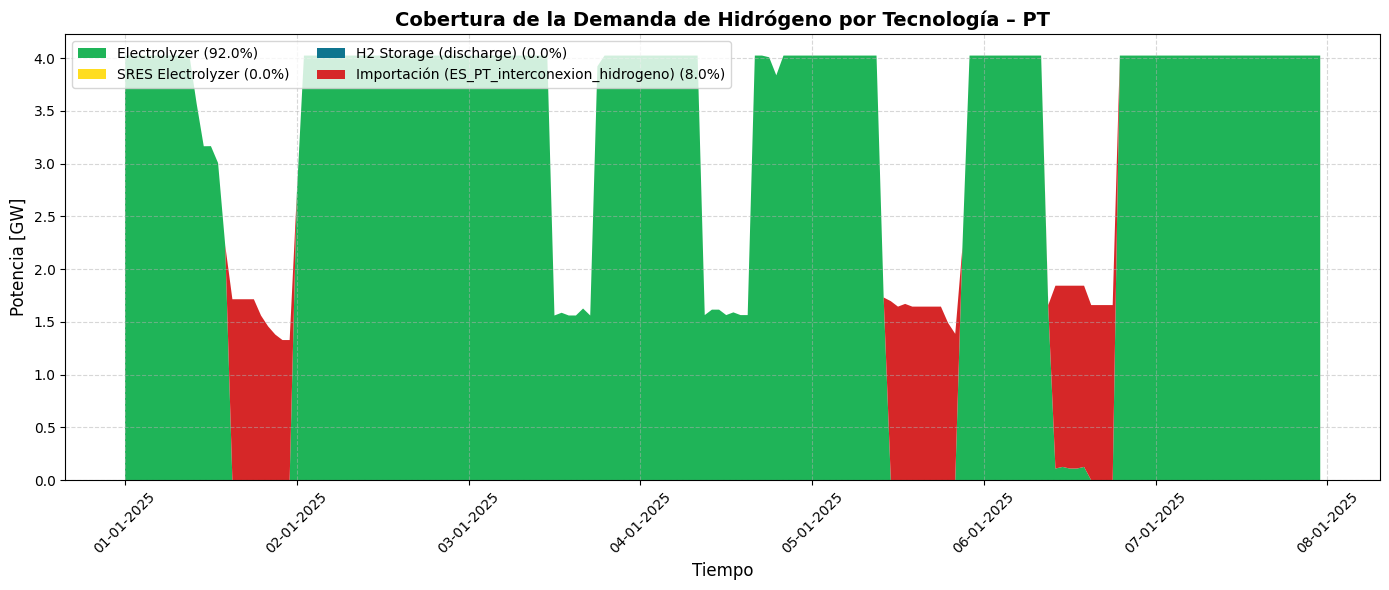

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3046094727.py:48: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3046094727.py:49: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3046094727.py:51: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3046094727.py:52: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a dr


=== Cobertura H2 - ES ===
                                             Energía semanal [GWh]  \
H2 Storage (discharge)                                   47614.926   
SRES Electrolyzer                                        28969.324   
Importación (PT_ES_interconexion_hidrogeno)              15546.716   
Electrolyzer                                              2597.606   

                                             Participación [%]  
H2 Storage (discharge)                                  50.265  
SRES Electrolyzer                                       30.581  
Importación (PT_ES_interconexion_hidrogeno)             16.412  
Electrolyzer                                             2.742  


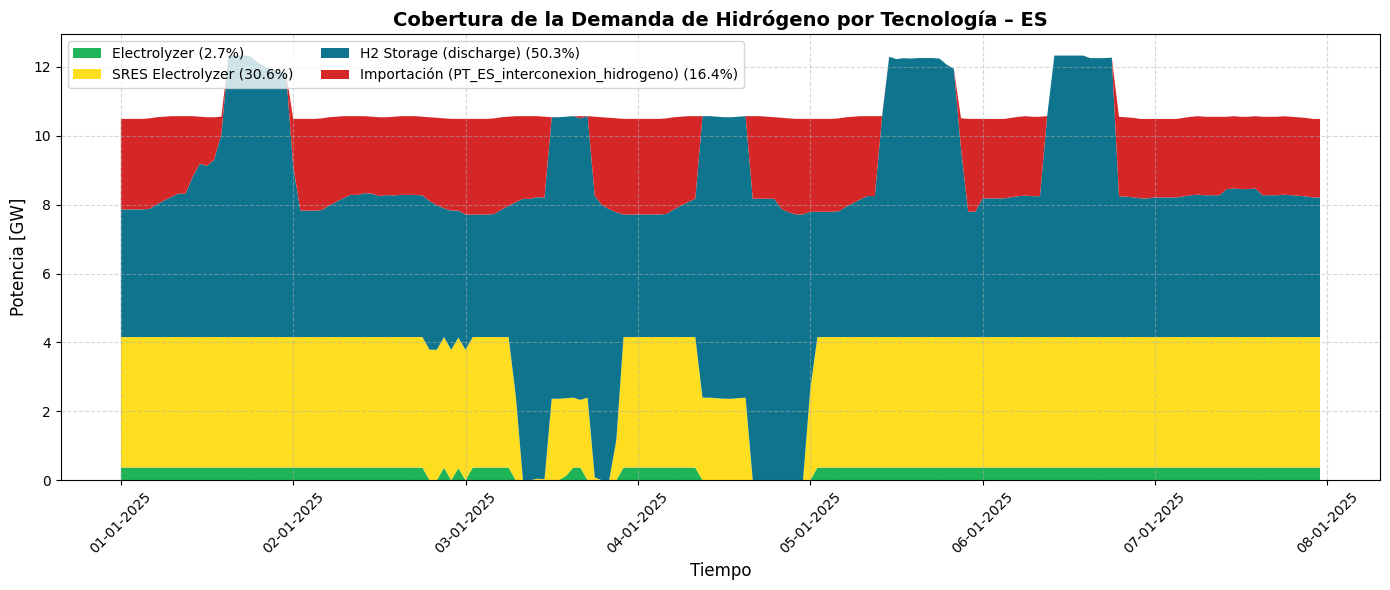

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_h2_coverage_with_weekly_shares(
    n,
    country="PT",
    t_start="2025-01-01",
    t_end="2025-01-07 23:00",
    use_snapshot_weights=True,
):
    # --- snapshots de la semana ---
    idx = pd.date_range(t_start, t_end, freq="h")
    idx = idx.intersection(n.snapshots)

    # --- pesos (para anualización o para sumar MWh de la semana) ---
    if use_snapshot_weights and hasattr(n, "snapshot_weightings") and "objective" in n.snapshot_weightings.columns:
        w = n.snapshot_weightings.loc[idx, "objective"].astype(float)  # horas equivalentes
    else:
        w = pd.Series(1.0, index=idx)  # 1h por snapshot

    # ==============================
    # Componentes de cobertura H2 (MW_H2)
    # ==============================
    # Producción H2 desde electrolizadores (p1 suele ser salida en bus1 => H2)
    # OJO: en tu código ya usabas -p1 para que salga positivo. Mantengo eso y luego clip.
    ely = f"{country}_electrolyzer"
    sres_ely = f"{country}_SRES_electrolyzer"

    # Importación H2 (depende de dirección del link)
    # Para PT: importación desde ES suele ser "ES_PT_interconexion_hidrogeno"
    # Para ES: importación desde PT suele ser "PT_ES_interconexion_hidrogeno"
    if country == "PT":
        inter = "ES_PT_interconexion_hidrogeno"
    else:
        inter = "PT_ES_interconexion_hidrogeno"

    # Storage H2 (si existe como StorageUnit; en tu caso ES sí, PT a veces no)
    h2_store = f"{country}_hydrogen_storage"

    # --- series (MW_H2) ---
    s_ely = pd.Series(0.0, index=idx)
    s_sres = pd.Series(0.0, index=idx)
    s_store = pd.Series(0.0, index=idx)
    s_inter = pd.Series(0.0, index=idx)

    if ely in n.links_t.p1.columns:
        s_ely = (-n.links_t.p1[ely]).reindex(idx).fillna(0.0).clip(lower=0)

    if sres_ely in n.links_t.p1.columns:
        s_sres = (-n.links_t.p1[sres_ely]).reindex(idx).fillna(0.0).clip(lower=0)

    # Descarga almacenamiento H2 (positiva)
    if hasattr(n, "storage_units_t") and "p" in n.storage_units_t and h2_store in n.storage_units_t.p.columns:
        s_store = (n.storage_units_t.p[h2_store]).reindex(idx).fillna(0.0).clip(lower=0)

    # Importación por interconexión:
    # Usamos p1 y clip(upper=0) como tú, y luego lo pasamos a positivo.
    if inter in n.links_t.p1.columns:
        s_inter = (-n.links_t.p1[inter].reindex(idx).fillna(0.0).clip(upper=0)).clip(lower=0)

    # --- DataFrame para plot (en GW para que coincida con tu figura) ---
    df = pd.DataFrame({
        "Electrolyzer": s_ely / 1e3,
        "SRES Electrolyzer": s_sres / 1e3,
        "H2 Storage (discharge)": s_store / 1e3,
        f"Importación ({inter})": s_inter / 1e3,
    }, index=idx)

    # ==============================
    # Energías semanales y porcentajes
    # ==============================
    # Energía (GWh) = sum( GW * horas_equivalentes )
    E = (df.mul(w, axis=0)).sum(axis=0)  # GWh si w está en horas
    E_total = E.sum()

    if E_total <= 0:
        print("⚠️ Energía total ~0; revisa signos/series.")
        shares = E*0.0
    else:
        shares = 100 * E / E_total

    # Tabla resumen
    summary = pd.DataFrame({
        "Energía semanal [GWh]": E,
        "Participación [%]": shares
    }).sort_values("Energía semanal [GWh]", ascending=False)

    print("\n=== Cobertura H2 -", country, "===")
    print(summary.round(3))

    # ==============================
    # Plot con % en la leyenda
    # ==============================
    labels = [f"{c} ({shares[c]:.1f}%)" for c in df.columns]

    plt.figure(figsize=(14, 6))
    plt.stackplot(
        df.index,
        df["Electrolyzer"],
        df["SRES Electrolyzer"],
        df["H2 Storage (discharge)"],
        df[f"Importación ({inter})"],
        labels=labels,
        # usa tus colores si quieres:
        colors=["#1fb458", "#ffdb0eec", "#0f758f", "#d62728"],
        linewidth=0.0,
    )
    plt.title(f"Cobertura de la Demanda de Hidrógeno por Tecnología – {country}", fontsize=14, fontweight="bold")
    plt.xlabel("Tiempo", fontsize=12)
    plt.ylabel("Potencia [GW]", fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="upper left", fontsize=10, ncol=2)
    plt.tight_layout()
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
    plt.show()

    return df, summary

# --- USO ---
df_pt, summary_pt = plot_h2_coverage_with_weekly_shares(network, country="PT")
df_es, summary_es = plot_h2_coverage_with_weekly_shares(network, country="ES")

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3655403134.py:8: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3655403134.py:19: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3655403134.py:26: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\3655403134.py:36: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information

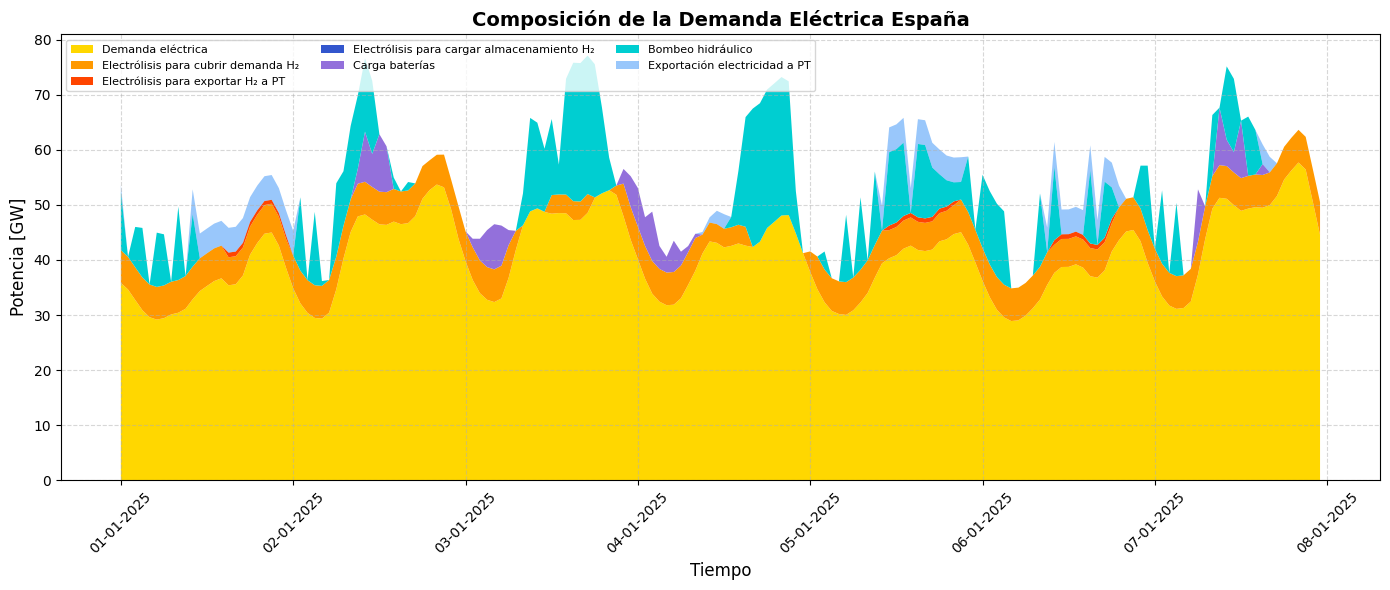

In [135]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ----------------------------- DEMANDA ELÉCTRICA (LOAD) -----------------------------
# Ajusta este nombre si tu load se llama distinto
national_electricity_demand = network.loads_t.p_set["ES_demand_2040"] / 1e3  # MW -> GW

# ----------------------------- ÍNDICES ROBUSTOS -------------------------------------
link_index = network.links.static.index
su_index   = network.storage_units.static.index

# ----------------------------- STORAGE UNITS ----------------------------------------
battery_sus = [n for n in su_index if "es_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in su_index if "es_hydrogen_storage" in n.lower()]

battery_charge = (
    network.storage_units_t.p[battery_sus]
    .clip(upper=0)          # carga = valores negativos
    .sum(axis=1)
    .abs() / 1e3            # MW -> GW
) if len(battery_sus) else 0.0

h2_charge = (
    network.storage_units_t.p[h2_sus]
    .clip(upper=0)
    .sum(axis=1)
    .abs() / 1e3
) if len(h2_sus) else 0.0

# ----------------------------- BOMBEO HIDRÁULICO ------------------------------------
pumped_links = [l for l in link_index if ("es_pump" in l.lower()) or ("es_turbina" in l.lower())]

pumping_demand = (
    network.links_t.p0[pumped_links]
    .clip(lower=0)          # según tu convención: p0 positivo = consumo eléctrico
    .sum(axis=1) / 1e3
) if len(pumped_links) else 0.0

# ----------------------------- EXPORT ELECTRICIDAD ES -> PT -------------------------
exportelectricity_links = [l for l in link_index if "es_pt_interconexion_electricidad" in l.lower()]

exportelectricity_demand = (
    network.links_t.p0[exportelectricity_links]
    .clip(lower=0)
    .sum(axis=1) / 1e3
) if len(exportelectricity_links) else 0.0

# ----------------------------- ELECTROLIZADORES (ELECTRICIDAD CONSUMIDA) ------------
electrolyzer_links = [l for l in link_index if "es_electrolyzer" in l.lower()]

electrolyzer_electricity = (
    network.links_t.p0[electrolyzer_links]
    .clip(lower=0)          # según tu convención: p0 positivo = consumo eléctrico
    .sum(axis=1) / 1e3
) if len(electrolyzer_links) else 0.0

# ========================= PARTIR ELECTRÓLISIS EN 3 (H2) ============================
# 1) Demanda H2 (load): si la tienes como load en loads_t.p_set
#    (si tu H2-demand NO está en loads, dímelo y lo adaptamos a stores/links)
h2_load_names = [n for n in network.loads_t.p_set.columns if "es_hydrogen_demand" in n.lower()]
h2_demand = (
    network.loads_t.p_set[h2_load_names].sum(axis=1) / 1e3
) if len(h2_load_names) else 0.0

# 2) Export H2 ES -> PT: link interconexión hidrógeno
export_h2_links = [l for l in link_index if "es_pt_interconexion_hidrogeno" in l.lower()]

export_h2 = (
    network.links_t.p0[export_h2_links]
    .clip(lower=0)          # asumiendo misma convención: p0 positivo = "sale" del sistema ES (demanda interna)
    .sum(axis=1) / 1e3
) if len(export_h2_links) else 0.0

# 3) Carga almacenamiento H2 (ya calculada arriba): h2_charge

# Reparto proporcional de la electricidad de electrólisis por sumideros de H2
# (si en una hora no hay sumidero, asigna 0 a las tres categorías)
h2_sinks_total = (h2_demand + export_h2 + h2_charge)

# evitar división 0
with np.errstate(divide='ignore', invalid='ignore'):
    share_demand = np.where(h2_sinks_total != 0, h2_demand / h2_sinks_total, 0.0)
    share_export = np.where(h2_sinks_total != 0, export_h2 / h2_sinks_total, 0.0)
    share_store  = np.where(h2_sinks_total != 0, h2_charge / h2_sinks_total, 0.0)

# Series (alineadas en índice temporal)
idx = national_electricity_demand.index
def to_series(x):
    if isinstance(x, (int, float)):
        return pd.Series(0.0, index=idx)
    return x.reindex(idx).fillna(0.0)

electrolyzer_electricity = to_series(electrolyzer_electricity)
h2_demand  = to_series(h2_demand)
export_h2  = to_series(export_h2)
h2_charge  = to_series(h2_charge)
battery_charge = to_series(battery_charge)
pumping_demand = to_series(pumping_demand)
exportelectricity_demand = to_series(exportelectricity_demand)

elec_for_h2_demand  = electrolyzer_electricity * pd.Series(share_demand, index=idx)
elec_for_h2_export  = electrolyzer_electricity * pd.Series(share_export, index=idx)
elec_for_h2_storage = electrolyzer_electricity * pd.Series(share_store,  index=idx)

# ----------------------------- GRÁFICA STACKPLOT -----------------------------------
plt.figure(figsize=(14, 6))
plt.stackplot(
    idx,
    national_electricity_demand,
    elec_for_h2_demand,
    elec_for_h2_export,
    elec_for_h2_storage,
    battery_charge,
    pumping_demand,
    exportelectricity_demand,
    labels=[
        "Demanda eléctrica",
        "Electrólisis para cubrir demanda H₂",
        "Electrólisis para exportar H₂ a PT",
        "Electrólisis para cargar almacenamiento H₂",
        "Carga baterías",
        "Bombeo hidráulico",
        "Exportación electricidad a PT",
    ],
    colors=[
        "#FFD700",  # Demanda eléctrica
        "#FF9900",  # Electrólisis -> H2 demanda
        "#FF4500",  # Electrólisis -> H2 export
        "#3256CD",  # Electrólisis -> H2 storage
        "#9370DB",  # Baterías
        "#00CED1",  # Bombeo
        "#2386F776" # Export elec
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica España", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8 , ncol=3)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1698786067.py:7: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.loads.dynamic` as a drop-in replacement for `n.loads_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1698786067.py:17: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1698786067.py:27: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.dynamic` as a drop-in replacement for `n.links_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1698786067.py:35: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.links.d

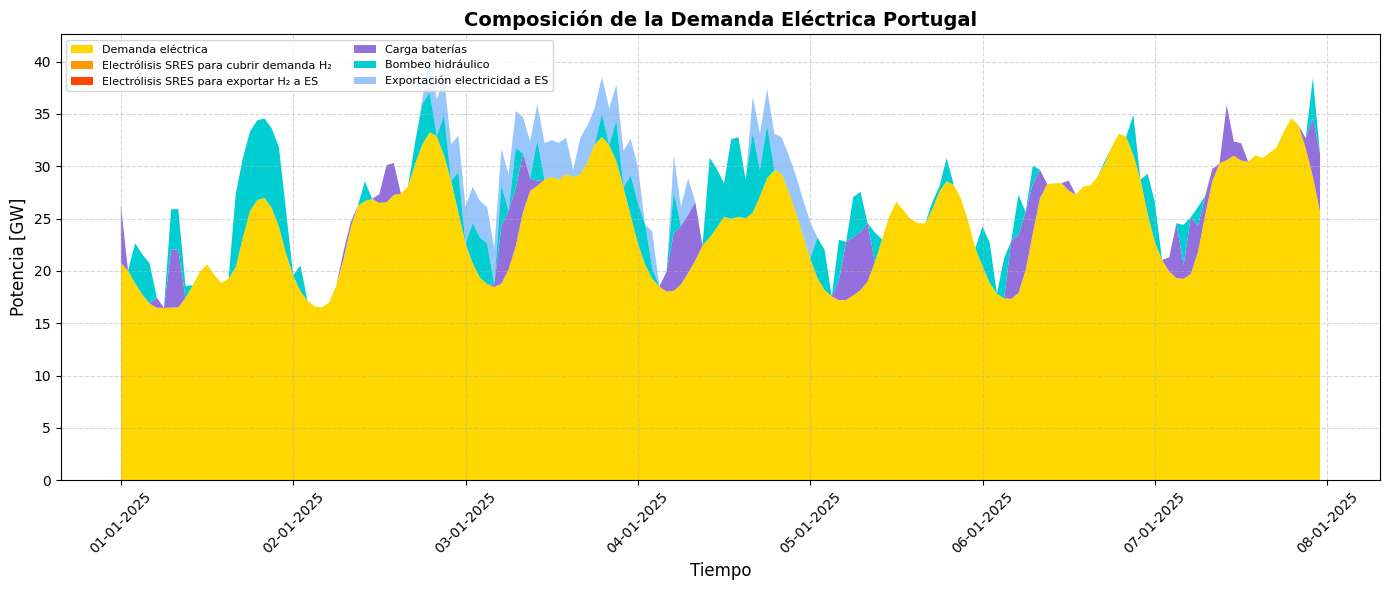

In [136]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ----------------------------- DEMANDA ELÉCTRICA (LOAD) -----------------------------
national_electricity_demand = network.loads_t.p_set["PT_demand_2040"] / 1e3  # MW -> GW

link_index = network.links.static.index
su_index   = network.storage_units.static.index

# ----------------------------- STORAGE UNITS ----------------------------------------
battery_sus = [n for n in su_index if "pt_electricity_market_battery" in n.lower()]
h2_sus      = [n for n in su_index if "pt_hydrogen_storage" in n.lower()]

battery_charge = (
    network.storage_units_t.p[battery_sus].clip(upper=0).sum(axis=1).abs() / 1e3
) if len(battery_sus) else pd.Series(0.0, index=network.snapshots)

h2_charge = (
    network.storage_units_t.p[h2_sus].clip(upper=0).sum(axis=1).abs() / 1e3
) if len(h2_sus) else pd.Series(0.0, index=network.snapshots)

# ----------------------------- BOMBEO HIDRÁULICO ------------------------------------
pumped_links = [l for l in link_index if ("pt_pump" in l.lower()) or ("pt_turbina" in l.lower())]
pumping_demand = (
    network.links_t.p0[pumped_links].clip(lower=0).sum(axis=1) / 1e3
) if len(pumped_links) else pd.Series(0.0, index=network.snapshots)

# ----------------------------- EXPORT ELECTRICIDAD PT -> ES -------------------------
# (en tu naming, esto es "PT_ES_interconexion_electricidad")
export_elec_name = "PT_ES_interconexion_electricidad"
exportelectricity_demand = (
    network.links_t.p0[export_elec_name].clip(lower=0) / 1e3
) if export_elec_name in network.links_t.p0.columns else pd.Series(0.0, index=network.snapshots)

# ----------------------------- ELECTROLIZADOR SRES PT (electricidad consumida) ------
ely_sres_name = "PT_SRES_electrolyzer"
electrolyzer_electricity = (
    network.links_t.p0[ely_sres_name].clip(lower=0) / 1e3
) if ely_sres_name in network.links_t.p0.columns else pd.Series(0.0, index=network.snapshots)

# ========================= PARTIR ELECTRÓLISIS EN 2 (H2) ============================
# 1) Demanda H2 PT
h2_demand = network.loads_t.p_set["PT_hydrogen_demand"] / 1e3  # MW_H2 -> GW_H2 (en tus unidades)

# 2) Export H2 PT -> ES (si existe)
export_h2_name = "PT_ES_interconexion_hidrogeno"
export_h2 = (
    network.links_t.p0[export_h2_name].clip(lower=0) / 1e3
) if export_h2_name in network.links_t.p0.columns else pd.Series(0.0, index=network.snapshots)

# (Opcional) 3) Carga almacenamiento H2 (ya calculada): h2_charge

# Reparto proporcional de la electricidad del electrolizador SRES por sumideros de H2
h2_sinks_total = (h2_demand + export_h2 + h2_charge).replace(0.0, np.nan)

share_demand = (h2_demand / h2_sinks_total).fillna(0.0)
share_export = (export_h2 / h2_sinks_total).fillna(0.0)
share_store  = (h2_charge / h2_sinks_total).fillna(0.0)

elec_for_h2_demand  = electrolyzer_electricity * share_demand
elec_for_h2_export  = electrolyzer_electricity * share_export
elec_for_h2_storage = electrolyzer_electricity * share_store

# ----------------------------- GRÁFICA STACKPLOT -----------------------------------
idx = national_electricity_demand.index

plt.figure(figsize=(14, 6))
plt.stackplot(
    idx,
    national_electricity_demand.reindex(idx).fillna(0.0),
    elec_for_h2_demand.reindex(idx).fillna(0.0),
    elec_for_h2_export.reindex(idx).fillna(0.0),

    battery_charge.reindex(idx).fillna(0.0),
    pumping_demand.reindex(idx).fillna(0.0),
    exportelectricity_demand.reindex(idx).fillna(0.0),
    labels=[
        "Demanda eléctrica",
        "Electrólisis SRES para cubrir demanda H₂",
        "Electrólisis SRES para exportar H₂ a ES",
   
        "Carga baterías",
        "Bombeo hidráulico",
        "Exportación electricidad a ES",
    ],
    colors=[
        "#FFD700",
        "#FF9900",
        "#FF4500",

        "#9370DB",
        "#00CED1",
        "#2386F776"
    ],
    linewidth=0.0,
)

plt.title("Composición de la Demanda Eléctrica Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Tiempo", fontsize=12)
plt.ylabel("Potencia [GW]", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\4200272982.py:9: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\4200272982.py:15: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.




--- ES_electricity_market_battery ---
SOC NaNs: 0 de 168
SOC min/max: -0.0 41754.38446684781
Usando p_nom_opt: 10438.596116711953
Emax: 41754.38446684781 MWh


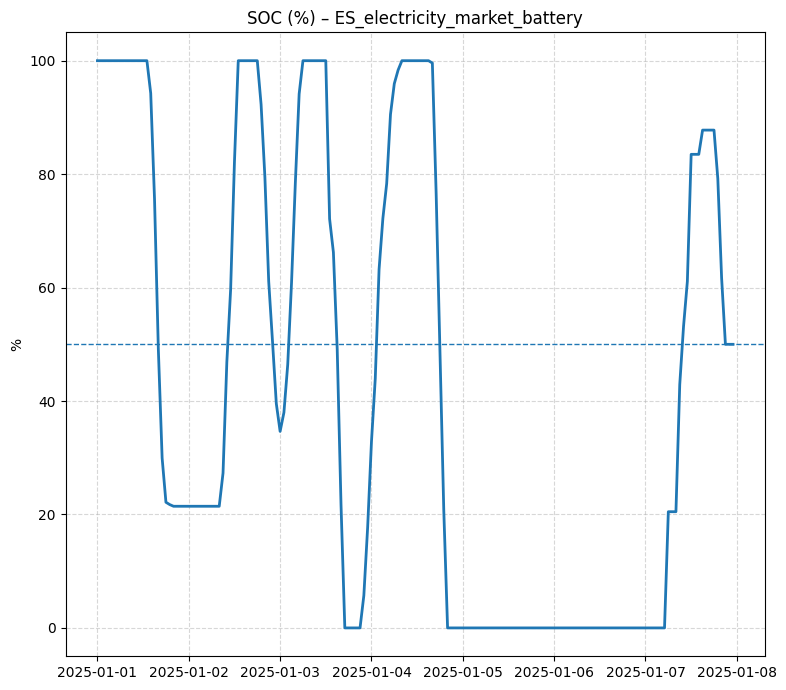

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\4200272982.py:9: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\4200272982.py:15: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.




--- PT_electricity_market_battery ---
SOC NaNs: 0 de 168
SOC min/max: -0.0 22222.222222222223
Usando p_nom_opt: 5555.555555555556
Emax: 22222.222222222223 MWh


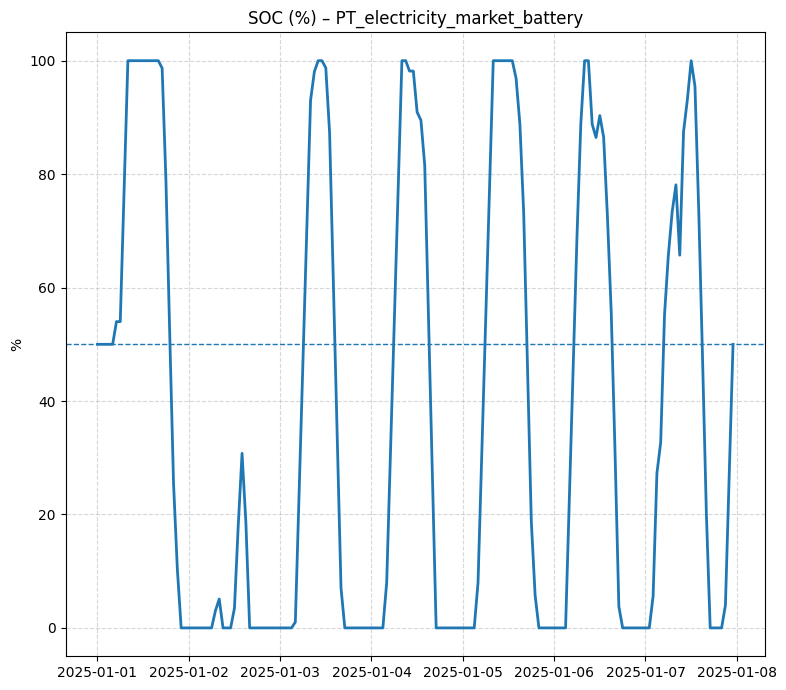

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\4200272982.py:9: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\4200272982.py:15: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.




--- ES_hydrogen_storage ---
SOC NaNs: 0 de 168
SOC min/max: 4086837.0323314248 4996292.861169519
Usando p_nom_opt: 8173.67406466285
Emax: 8173674.0646628495 MWh


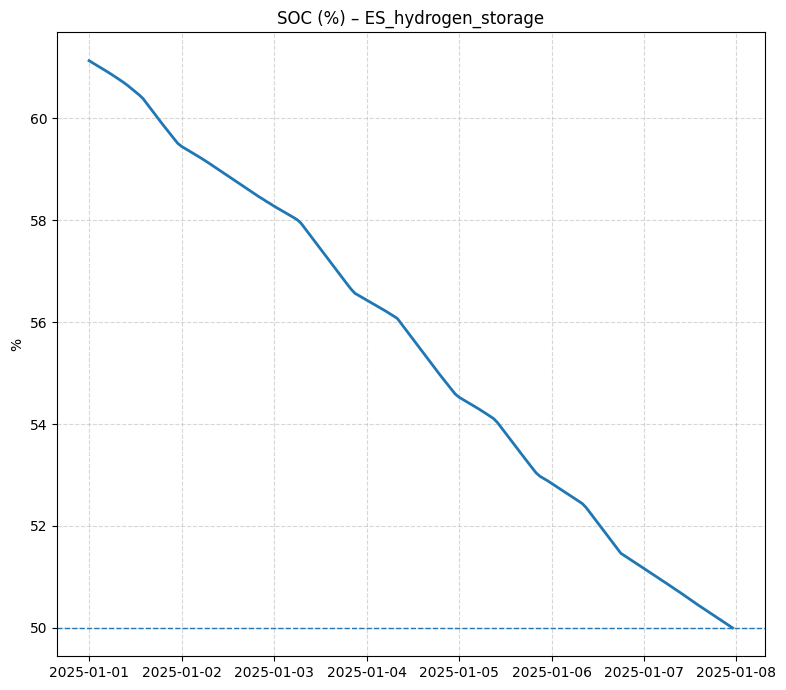

In [137]:
import matplotlib.pyplot as plt
import numpy as np

def plot_soc_percent_debug(n, name):
    # 0) existencia
    if name not in n.storage_units.static.index:
        print("NO existe en storage_units.static:", name)
        return
    if name not in n.storage_units_t.state_of_charge.columns:
        print("NO existe en storage_units_t.state_of_charge:", name)
        print("Columnas disponibles (ejemplo):", list(n.storage_units_t.state_of_charge.columns)[:10])
        return

    su = n.storage_units.static
    soc = n.storage_units_t.state_of_charge[name].astype(float)

    print("\n---", name, "---")
    print("SOC NaNs:", soc.isna().sum(), "de", len(soc))
    print("SOC min/max:", float(np.nanmin(soc.values)), float(np.nanmax(soc.values)))

    max_hours = float(su.loc[name, "max_hours"])

    # elegir p_nom para Emax
    if "p_nom_opt" in su.columns and pd.notna(su.loc[name, "p_nom_opt"]):
        p_nom_used = float(su.loc[name, "p_nom_opt"])
        print("Usando p_nom_opt:", p_nom_used)
    else:
        p_nom_used = float(su.loc[name, "p_nom"])
        print("Usando p_nom (input):", p_nom_used)

    Emax = p_nom_used * max_hours
    print("Emax:", Emax, "MWh")

    if Emax <= 0 or np.isnan(Emax):
        print("Emax inválido -> no se puede plotear %")
        return

    soc_pct = soc / Emax * 100

    # si todo es NaN, no se verá
    if soc_pct.isna().all():
        print("soc_pct es TODO NaN -> no se verá nada")
        return

    plt.figure(figsize=(8,7))
    plt.plot(soc_pct.index, soc_pct.values, linewidth=2)
    plt.axhline(50, linestyle="--", linewidth=1)
    plt.title(f"SOC (%) – {name}")
    plt.ylabel("%")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_soc_percent_debug(network, "ES_electricity_market_battery")
plot_soc_percent_debug(network, "PT_electricity_market_battery")
plot_soc_percent_debug(network, "ES_hydrogen_storage")


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2135070050.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2135070050.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



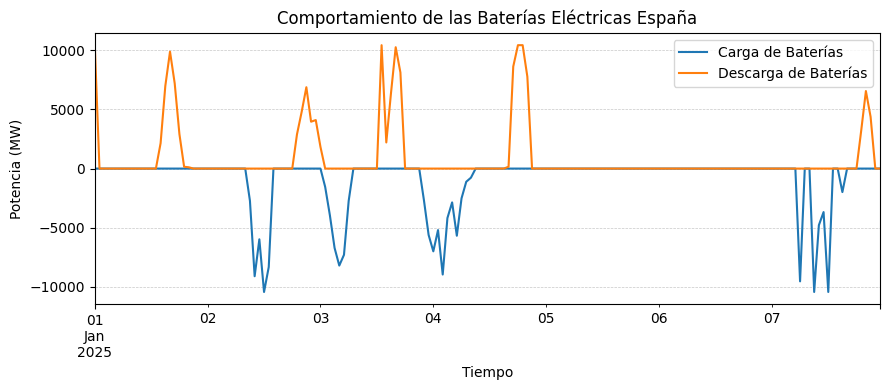

In [138]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["ES_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["ES_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(9,4))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas España")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

# OJO

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2875945628.py:4: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2875945628.py:6: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



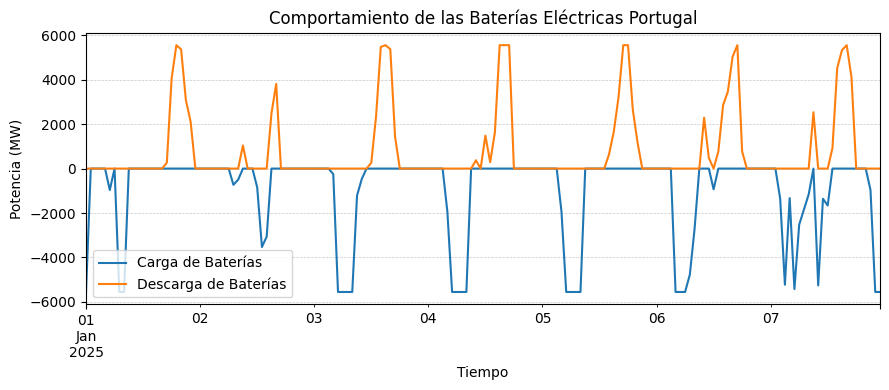

In [139]:
#Grafica de la baterias electricas

#extraemos la serie de carga de las baterias electricas
battery_charge = network.storage_units_t.p["PT_electricity_market_battery"].clip(upper=0)
#extraemos la serie de descarga de las baterias electricas
battery_discharge = network.storage_units_t.p["PT_electricity_market_battery"].clip(lower=0)
#graficamos la carga y descarga de las baterias electricas
plt.figure(figsize=(9,4))
battery_charge.plot(label="Carga de Baterías", color="tab:blue")
battery_discharge.plot(label="Descarga de Baterías", color="tab:orange")
plt.title("Comportamiento de las Baterías Eléctricas Portugal")
plt.ylabel("Potencia (MW)")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2438572649.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



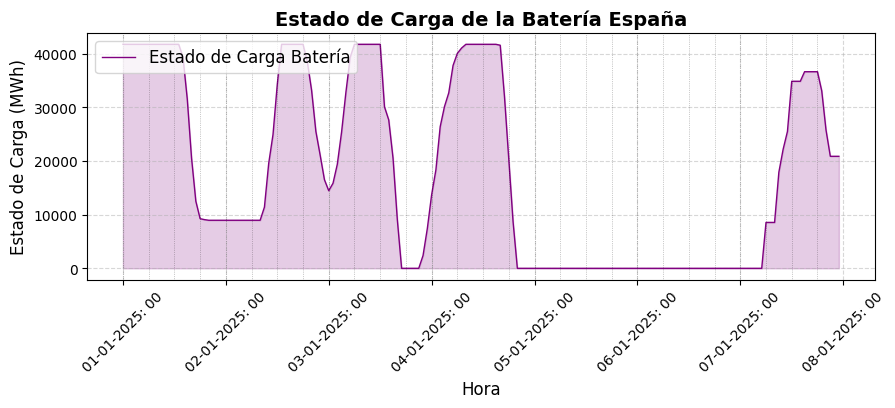

In [140]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["ES_electricity_market_battery"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()



C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\2724379132.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



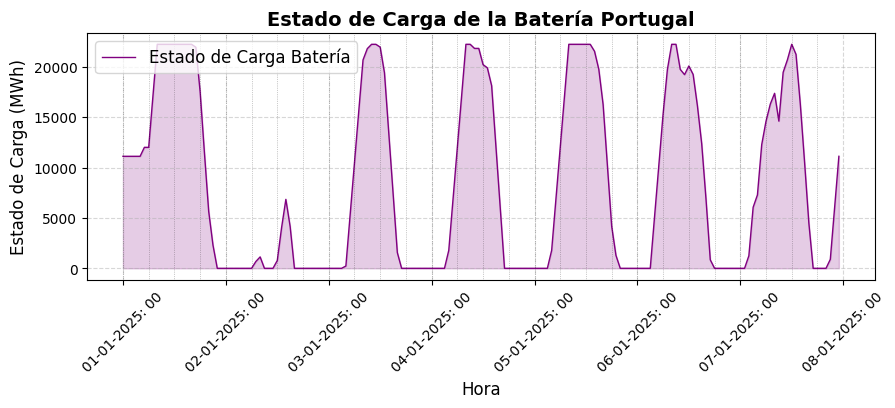

In [141]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["PT_electricity_market_battery"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Batería", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Portugal", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()

C:\Users\EXT10348\AppData\Local\Temp\ipykernel_3516\1258577109.py:2: DeprecationWarning:

With PyPSA 1.0, the API for how to access components data has changed. See #TODO for more information. Use `n.storage_units.dynamic` as a drop-in replacement for `n.storage_units_t`.



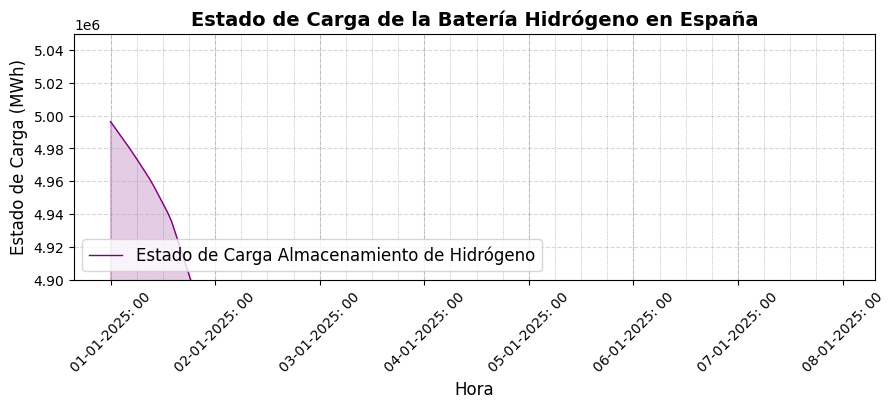

In [142]:
#Grafica del estado de carga de las baterías
soc_batt = network.storage_units_t.state_of_charge["ES_hydrogen_storage"]
plt.figure(figsize=(9,4))
plt.style.use('default')
plt.plot(hours, soc_batt, label="Estado de Carga Almacenamiento de Hidrógeno", color="purple", linewidth=1, linestyle="-")
plt.fill_between(hours, soc_batt, color="purple", alpha=0.2)    
plt.title("Estado de Carga de la Batería Hidrógeno en España", fontsize=14, fontweight="bold")
plt.xlabel("Hora", fontsize=12)
plt.ylabel("Estado de Carga (MWh)", fontsize=12)
plt.xticks(rotation=45)

plt.ylim(4900000, 5050000)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="lower left", fontsize=12)
plt.tight_layout()
for day in pd.date_range("2025-01-01", "2025-01-07"):
    for hour in [0, 6, 12, 18]:
        timestamp = pd.Timestamp(day.date()) + pd.Timedelta(hours=hour)
        plt.axvline(x=timestamp, color='black', linestyle=':', linewidth=0.5, alpha=0.4)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y: %H'))
plt.xticks(rotation=45)
plt.show()